In [1]:
import random
import numpy as np
import torch

SEED = 6304

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)

Seed: 6304
Device: cuda


In [2]:
from torchvision.datasets import STL10

data_root = "./data"

train_dataset = STL10(
    root=data_root,
    split="train",
    download=True
)

test_dataset = STL10(
    root=data_root,
    split="test",
    download=True
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training images: 5000
Test images: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [3]:
from sklearn.model_selection import train_test_split

all_train_indices = np.arange(len(train_dataset))
all_train_labels = np.array(train_dataset.labels)

train_indices, val_indices = train_test_split(
    all_train_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=all_train_labels
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 4000
Validation samples: 1000


In [4]:
from torchvision.datasets import STL10

data_root = "./data"

train_dataset = STL10(
    root=data_root,
    split="train",
    download=True
)

test_dataset = STL10(
    root=data_root,
    split="test",
    download=True
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training images: 5000
Test images: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
import pandas as pd
from pathlib import Path

test_labels = np.array(test_dataset.labels)
rng = np.random.default_rng(SEED)

selected_rows = []

for class_id, class_name in enumerate(test_dataset.classes):
    class_indices = np.flatnonzero(test_labels == class_id)
    number_to_select = min(50, len(class_indices))

    chosen_indices = rng.choice(
        class_indices,
        size=number_to_select,
        replace=False
    )

    for dataset_index in sorted(chosen_indices):
        selected_rows.append({
            "dataset_index": dataset_index,
            "class_id": class_id,
            "class_name": class_name
        })

test_manifest = pd.DataFrame(selected_rows)
test_manifest.insert(0, "subset_index", range(len(test_manifest)))

Path("data").mkdir(exist_ok=True)
test_manifest.to_csv("data/test_subset_seed6304.csv", index=False)

print("Selected images:", len(test_manifest))
print(test_manifest.groupby("class_name").size())
print(test_manifest.head())

Selected images: 500
class_name
airplane    50
bird        50
car         50
cat         50
deer        50
dog         50
horse       50
monkey      50
ship        50
truck       50
dtype: int64
   subset_index  dataset_index  class_id class_name
0             0              3         0   airplane
1             1             42         0   airplane
2             2             81         0   airplane
3             3            484         0   airplane
4             4            562         0   airplane


In [6]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

common_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC,
        antialias=True
    )
])

first_test_index = int(test_manifest.iloc[0]["dataset_index"])
original_image, label = test_dataset[first_test_index]
clean_image = common_transform(original_image)

print("Original:", original_image.mode, original_image.size)
print("Common image:", clean_image.mode, clean_image.size)
print("Label:", test_dataset.classes[label])

Original: RGB (96, 96)
Common image: RGB (224, 224)
Label: airplane


In [7]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import ToTensor, Normalize, Compose

resnet_weights = ResNet50_Weights.IMAGENET1K_V2
resnet = resnet50(weights=resnet_weights)

resnet.fc = nn.Identity()

for parameter in resnet.parameters():
    parameter.requires_grad = False

resnet = resnet.to(device)
resnet.eval()

resnet_preprocess = Compose([
    ToTensor(),
    Normalize(
        mean=resnet_weights.transforms().mean,
        std=resnet_weights.transforms().std
    )
])

In [8]:
resnet_input = resnet_preprocess(clean_image).unsqueeze(0).to(device)

with torch.no_grad():
    resnet_feature = resnet(resnet_input)

print("Input shape:", resnet_input.shape)
print("Feature shape:", resnet_feature.shape)

Input shape: torch.Size([1, 3, 224, 224])
Feature shape: torch.Size([1, 2048])


In [9]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit_weights = ViT_B_16_Weights.IMAGENET1K_V1
vit = vit_b_16(weights=vit_weights)

vit.heads = nn.Identity()

for parameter in vit.parameters():
    parameter.requires_grad = False

vit = vit.to(device)
vit.eval()

vit_preprocess = Compose([
    ToTensor(),
    Normalize(
        mean=vit_weights.transforms().mean,
        std=vit_weights.transforms().std
    )
])

In [10]:
vit_input = vit_preprocess(clean_image).unsqueeze(0).to(device)

with torch.no_grad():
    vit_feature = vit(vit_input)

print("Input shape:", vit_input.shape)
print("Feature shape:", vit_feature.shape)

Input shape: torch.Size([1, 3, 224, 224])
Feature shape: torch.Size([1, 768])


In [11]:
#!pip install open_clip_torch

In [12]:
import open_clip

clip, _, _ = open_clip.create_model_and_transforms(
    model_name="ViT-B-32-quickgelu",
    pretrained="openai"
)

for parameter in clip.parameters():
    parameter.requires_grad = False

clip = clip.to(device)
clip.eval()

print(
    ("ViT-B-32-quickgelu", "openai")
    in open_clip.list_pretrained()
)

True


In [13]:
clip_preprocess = Compose([
    ToTensor(),
    Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])

In [14]:
clip_input = clip_preprocess(clean_image).unsqueeze(0).to(device)

with torch.no_grad():
    clip_feature = clip.encode_image(clip_input)

    clip_feature = (
        clip_feature
        / clip_feature.norm(dim=-1, keepdim=True)
    )

print("Input shape:", clip_input.shape)
print("Feature shape:", clip_feature.shape)
print("Feature norm:", clip_feature.norm(dim=-1))

Input shape: torch.Size([1, 3, 224, 224])
Feature shape: torch.Size([1, 512])
tensor([1.], device='cuda:0')


In [15]:
import open_clip

clip, _, _ = open_clip.create_model_and_transforms(
    model_name="ViT-B-32",
    pretrained="openai"
)

for parameter in clip.parameters():
    parameter.requires_grad = False

clip = clip.to(device)
clip.eval()

clip_preprocess = Compose([
    ToTensor(),
    Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])

clip_input = clip_preprocess(clean_image).unsqueeze(0).to(device)

with torch.no_grad():
    clip_feature = clip.encode_image(clip_input)
    clip_feature = clip_feature / clip_feature.norm(dim=-1, keepdim=True)

print("Input shape:", clip_input.shape)
print("Feature shape:", clip_feature.shape)
print("Feature norm:", clip_feature.norm(dim=-1))

C:\Users\HP\anaconda3\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Input shape: torch.Size([1, 3, 224, 224])
Feature shape: torch.Size([1, 512])
Feature norm: tensor([1.], device='cuda:0')


In [16]:
from torch.utils.data import Dataset

class IndexedImageDataset(Dataset):
    def __init__(self, base_dataset, indices, model_preprocess):
        self.base_dataset = base_dataset
        self.indices = np.array(indices)
        self.model_preprocess = model_preprocess

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        dataset_index = int(self.indices[position])
        image, label = self.base_dataset[dataset_index]

        image = common_transform(image)
        image_tensor = self.model_preprocess(image)

        return image_tensor, label, dataset_index

In [17]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

def make_feature_loaders(model_preprocess):
    train_data = IndexedImageDataset(
        base_dataset=train_dataset,
        indices=train_indices,
        model_preprocess=model_preprocess
    )

    val_data = IndexedImageDataset(
        base_dataset=train_dataset,
        indices=val_indices,
        model_preprocess=model_preprocess
    )

    train_loader = DataLoader(
        train_data,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    val_loader = DataLoader(
        val_data,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_loader, val_loader

In [18]:
resnet_train_loader, resnet_val_loader = make_feature_loaders(
    resnet_preprocess
)

vit_train_loader, vit_val_loader = make_feature_loaders(
    vit_preprocess
)

clip_train_loader, clip_val_loader = make_feature_loaders(
    clip_preprocess
)

In [19]:
from tqdm.auto import tqdm

def extract_features(model, loader, description):
    all_features = []
    all_labels = []
    all_indices = []

    model.eval()

    with torch.inference_mode():
        for images, labels, dataset_indices in tqdm(
            loader,
            desc=description
        ):
            images = images.to(device)
            features = model(images)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())
            all_indices.append(dataset_indices.cpu())

    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_indices = torch.cat(all_indices, dim=0)

    return all_features, all_labels, all_indices

In [20]:
resnet_train_features, resnet_train_labels, resnet_train_ids = (
    extract_features(
        resnet,
        resnet_train_loader,
        description="ResNet training features"
    )
)

resnet_val_features, resnet_val_labels, resnet_val_ids = (
    extract_features(
        resnet,
        resnet_val_loader,
        description="ResNet validation features"
    )
)

ResNet training features:   0%|          | 0/125 [00:00<?, ?it/s]

ResNet validation features:   0%|          | 0/32 [00:00<?, ?it/s]

In [21]:
print("Training features:", resnet_train_features.shape)
print("Training labels:", resnet_train_labels.shape)
print("Training IDs:", resnet_train_ids.shape)

print("Validation features:", resnet_val_features.shape)
print("Validation labels:", resnet_val_labels.shape)
print("Validation IDs:", resnet_val_ids.shape)

Training features: torch.Size([4000, 2048])
Training labels: torch.Size([4000])
Training IDs: torch.Size([4000])
Validation features: torch.Size([1000, 2048])
Validation labels: torch.Size([1000])
Validation IDs: torch.Size([1000])


In [22]:
vit_train_features, vit_train_labels, vit_train_ids = (
    extract_features(
        vit,
        vit_train_loader,
        description="ViT training features"
    )
)

vit_val_features, vit_val_labels, vit_val_ids = (
    extract_features(
        vit,
        vit_val_loader,
        description="ViT validation features"
    )
)

ViT training features:   0%|          | 0/125 [00:00<?, ?it/s]

ViT validation features:   0%|          | 0/32 [00:00<?, ?it/s]

In [23]:
print("Training features:", vit_train_features.shape)
print("Training labels:", vit_train_labels.shape)
print("Training IDs:", vit_train_ids.shape)

print("Validation features:", vit_val_features.shape)
print("Validation labels:", vit_val_labels.shape)
print("Validation IDs:", vit_val_ids.shape)

Training features: torch.Size([4000, 768])
Training labels: torch.Size([4000])
Training IDs: torch.Size([4000])
Validation features: torch.Size([1000, 768])
Validation labels: torch.Size([1000])
Validation IDs: torch.Size([1000])


In [24]:
assert torch.equal(resnet_train_ids, vit_train_ids)
assert torch.equal(resnet_train_labels, vit_train_labels)

assert torch.equal(resnet_val_ids, vit_val_ids)
assert torch.equal(resnet_val_labels, vit_val_labels)

print("ResNet and ViT data alignment verified.")

ResNet and ViT data alignment verified.


In [25]:
import torch.nn.functional as F

def extract_clip_features(clip_model, loader, description):
    all_features = []
    all_labels = []
    all_indices = []

    clip_model.eval()

    with torch.inference_mode():
        for images, labels, dataset_indices in tqdm(
            loader,
            desc=description
        ):
            images = images.to(device)

            features = clip_model.encode_image(images)
            features = F.normalize(features, p=2, dim=-1)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())
            all_indices.append(dataset_indices.cpu())

    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_indices = torch.cat(all_indices, dim=0)

    return all_features, all_labels, all_indices

In [26]:
clip_train_features, clip_train_labels, clip_train_ids = (
    extract_clip_features(
        clip,
        clip_train_loader,
        description="CLIP training features"
    )
)

clip_val_features, clip_val_labels, clip_val_ids = (
    extract_clip_features(
        clip,
        clip_val_loader,
        description="CLIP validation features"
    )
)

CLIP training features:   0%|          | 0/125 [00:00<?, ?it/s]

CLIP validation features:   0%|          | 0/32 [00:00<?, ?it/s]

In [27]:
print("Training features:", clip_train_features.shape)
print("Training labels:", clip_train_labels.shape)
print("Training IDs:", clip_train_ids.shape)

print("Validation features:", clip_val_features.shape)
print("Validation labels:", clip_val_labels.shape)
print("Validation IDs:", clip_val_ids.shape)

print(
    "First five feature norms:",
    clip_train_features[:5].norm(dim=-1)
)

Training features: torch.Size([4000, 512])
Training labels: torch.Size([4000])
Training IDs: torch.Size([4000])
Validation features: torch.Size([1000, 512])
Validation labels: torch.Size([1000])
Validation IDs: torch.Size([1000])
First five feature norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [28]:
assert torch.equal(resnet_train_ids, clip_train_ids)
assert torch.equal(resnet_train_labels, clip_train_labels)

assert torch.equal(resnet_val_ids, clip_val_ids)
assert torch.equal(resnet_val_labels, clip_val_labels)

print("ResNet, ViT and CLIP data alignment verified.")

ResNet, ViT and CLIP data alignment verified.


In [29]:
from pathlib import Path

feature_directory = Path("data/features")
feature_directory.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "train_features": resnet_train_features,
        "train_labels": resnet_train_labels,
        "train_ids": resnet_train_ids,
        "val_features": resnet_val_features,
        "val_labels": resnet_val_labels,
        "val_ids": resnet_val_ids
    },
    feature_directory / "resnet_features.pt"
)

torch.save(
    {
        "train_features": vit_train_features,
        "train_labels": vit_train_labels,
        "train_ids": vit_train_ids,
        "val_features": vit_val_features,
        "val_labels": vit_val_labels,
        "val_ids": vit_val_ids
    },
    feature_directory / "vit_features.pt"
)

torch.save(
    {
        "train_features": clip_train_features,
        "train_labels": clip_train_labels,
        "train_ids": clip_train_ids,
        "val_features": clip_val_features,
        "val_labels": clip_val_labels,
        "val_ids": clip_val_ids
    },
    feature_directory / "clip_features.pt"
)

print("Feature files saved in:", feature_directory)

Feature files saved in: data\features


In [30]:
def make_linear_head(input_dimension):
    torch.manual_seed(SEED)

    return nn.Linear(
        in_features=input_dimension,
        out_features=10
    ).to(device)

In [31]:
resnet_head = make_linear_head(
    resnet_train_features.shape[1]
)

vit_head = make_linear_head(
    vit_train_features.shape[1]
)

clip_head = make_linear_head(
    clip_train_features.shape[1]
)

print("ResNet head:", resnet_head)
print("ViT head:", vit_head)
print("CLIP head:", clip_head)

ResNet head: Linear(in_features=2048, out_features=10, bias=True)
ViT head: Linear(in_features=768, out_features=10, bias=True)
CLIP head: Linear(in_features=512, out_features=10, bias=True)


In [32]:
from torch.utils.data import TensorDataset, DataLoader

HEAD_BATCH_SIZE = 64

def make_head_loaders(
    train_features,
    train_labels,
    val_features,
    val_labels
):
    train_data = TensorDataset(
        train_features.float(),
        train_labels.long()
    )

    val_data = TensorDataset(
        val_features.float(),
        val_labels.long()
    )

    shuffle_generator = torch.Generator()
    shuffle_generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_data,
        batch_size=HEAD_BATCH_SIZE,
        shuffle=True,
        generator=shuffle_generator
    )

    val_loader = DataLoader(
        val_data,
        batch_size=HEAD_BATCH_SIZE,
        shuffle=False
    )

    return train_loader, val_loader

In [33]:
resnet_head_train_loader, resnet_head_val_loader = make_head_loaders(
    resnet_train_features,
    resnet_train_labels,
    resnet_val_features,
    resnet_val_labels
)

vit_head_train_loader, vit_head_val_loader = make_head_loaders(
    vit_train_features,
    vit_train_labels,
    vit_val_features,
    vit_val_labels
)

clip_head_train_loader, clip_head_val_loader = make_head_loaders(
    clip_train_features,
    clip_train_labels,
    clip_val_features,
    clip_val_labels
)

In [34]:
print(
    "ResNet:",
    len(resnet_head_train_loader.dataset),
    len(resnet_head_val_loader.dataset)
)

print(
    "ViT:",
    len(vit_head_train_loader.dataset),
    len(vit_head_val_loader.dataset)
)

print(
    "CLIP:",
    len(clip_head_train_loader.dataset),
    len(clip_head_val_loader.dataset)
)

ResNet: 4000 1000
ViT: 4000 1000
CLIP: 4000 1000


In [35]:
import copy

def train_linear_head(
    head,
    train_loader,
    val_loader,
    model_name,
    max_epochs=50,
    patience=5
):
    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        head.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    best_val_accuracy = -1.0
    best_epoch = 0
    best_head_state = copy.deepcopy(head.state_dict())
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, max_epochs + 1):

        # ---------- Training ----------
        head.train()

        total_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = head(features)
            loss = loss_function(logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        train_loss = total_train_loss / train_total
        train_accuracy = train_correct / train_total

        # ---------- Validation ----------
        head.eval()

        val_correct = 0
        val_total = 0

        with torch.inference_mode():
            for features, labels in val_loader:
                features = features.to(device)
                labels = labels.to(device)

                logits = head(features)
                predictions = logits.argmax(dim=1)

                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

        val_accuracy = val_correct / val_total

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy
        })

        print(
            f"{model_name} | Epoch {epoch:02d} | "
            f"Loss: {train_loss:.4f} | "
            f"Train acc: {train_accuracy:.4f} | "
            f"Val acc: {val_accuracy:.4f}"
        )

        # ---------- Early stopping ----------
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_head_state = copy.deepcopy(head.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch}.")
            break

    head.load_state_dict(best_head_state)

    print(
        f"Best {model_name} validation accuracy: "
        f"{best_val_accuracy:.4f} at epoch {best_epoch}"
    )

    history = pd.DataFrame(history)

    return head, history

In [36]:
resnet_head, resnet_history = train_linear_head(
    head=resnet_head,
    train_loader=resnet_head_train_loader,
    val_loader=resnet_head_val_loader,
    model_name="ResNet"
)

ResNet | Epoch 01 | Loss: 1.1052 | Train acc: 0.8640 | Val acc: 0.9600
ResNet | Epoch 02 | Loss: 0.3089 | Train acc: 0.9782 | Val acc: 0.9650
ResNet | Epoch 03 | Loss: 0.1710 | Train acc: 0.9840 | Val acc: 0.9690
ResNet | Epoch 04 | Loss: 0.1173 | Train acc: 0.9882 | Val acc: 0.9670
ResNet | Epoch 05 | Loss: 0.0885 | Train acc: 0.9898 | Val acc: 0.9700
ResNet | Epoch 06 | Loss: 0.0697 | Train acc: 0.9930 | Val acc: 0.9730
ResNet | Epoch 07 | Loss: 0.0574 | Train acc: 0.9938 | Val acc: 0.9720
ResNet | Epoch 08 | Loss: 0.0476 | Train acc: 0.9958 | Val acc: 0.9720
ResNet | Epoch 09 | Loss: 0.0405 | Train acc: 0.9970 | Val acc: 0.9720
ResNet | Epoch 10 | Loss: 0.0350 | Train acc: 0.9975 | Val acc: 0.9720
ResNet | Epoch 11 | Loss: 0.0305 | Train acc: 0.9975 | Val acc: 0.9720
Early stopping after epoch 11.
Best ResNet validation accuracy: 0.9730 at epoch 6


In [37]:
vit_head, vit_history = train_linear_head(
    head=vit_head,
    train_loader=vit_head_train_loader,
    val_loader=vit_head_val_loader,
    model_name="ViT"
)

ViT | Epoch 01 | Loss: 0.6715 | Train acc: 0.8918 | Val acc: 0.9740
ViT | Epoch 02 | Loss: 0.1366 | Train acc: 0.9805 | Val acc: 0.9750
ViT | Epoch 03 | Loss: 0.0851 | Train acc: 0.9872 | Val acc: 0.9740
ViT | Epoch 04 | Loss: 0.0605 | Train acc: 0.9905 | Val acc: 0.9780
ViT | Epoch 05 | Loss: 0.0457 | Train acc: 0.9940 | Val acc: 0.9770
ViT | Epoch 06 | Loss: 0.0358 | Train acc: 0.9968 | Val acc: 0.9770
ViT | Epoch 07 | Loss: 0.0285 | Train acc: 0.9985 | Val acc: 0.9820
ViT | Epoch 08 | Loss: 0.0235 | Train acc: 0.9985 | Val acc: 0.9810
ViT | Epoch 09 | Loss: 0.0195 | Train acc: 0.9992 | Val acc: 0.9810
ViT | Epoch 10 | Loss: 0.0167 | Train acc: 0.9992 | Val acc: 0.9810
ViT | Epoch 11 | Loss: 0.0145 | Train acc: 0.9998 | Val acc: 0.9790
ViT | Epoch 12 | Loss: 0.0125 | Train acc: 1.0000 | Val acc: 0.9800
Early stopping after epoch 12.
Best ViT validation accuracy: 0.9820 at epoch 7


In [38]:
clip_head, clip_history = train_linear_head(
    head=clip_head,
    train_loader=clip_head_train_loader,
    val_loader=clip_head_val_loader,
    model_name="CLIP"
)

CLIP | Epoch 01 | Loss: 2.1551 | Train acc: 0.7422 | Val acc: 0.9820
CLIP | Epoch 02 | Loss: 1.8746 | Train acc: 0.9740 | Val acc: 0.9840
CLIP | Epoch 03 | Loss: 1.6236 | Train acc: 0.9760 | Val acc: 0.9840
CLIP | Epoch 04 | Loss: 1.4021 | Train acc: 0.9782 | Val acc: 0.9830
CLIP | Epoch 05 | Loss: 1.2099 | Train acc: 0.9775 | Val acc: 0.9850
CLIP | Epoch 06 | Loss: 1.0459 | Train acc: 0.9788 | Val acc: 0.9850
CLIP | Epoch 07 | Loss: 0.9076 | Train acc: 0.9792 | Val acc: 0.9850
CLIP | Epoch 08 | Loss: 0.7919 | Train acc: 0.9798 | Val acc: 0.9850
CLIP | Epoch 09 | Loss: 0.6953 | Train acc: 0.9795 | Val acc: 0.9860
CLIP | Epoch 10 | Loss: 0.6148 | Train acc: 0.9798 | Val acc: 0.9850
CLIP | Epoch 11 | Loss: 0.5477 | Train acc: 0.9798 | Val acc: 0.9870
CLIP | Epoch 12 | Loss: 0.4912 | Train acc: 0.9798 | Val acc: 0.9860
CLIP | Epoch 13 | Loss: 0.4435 | Train acc: 0.9802 | Val acc: 0.9860
CLIP | Epoch 14 | Loss: 0.4031 | Train acc: 0.9802 | Val acc: 0.9870
CLIP | Epoch 15 | Loss: 0.3686 | T

In [39]:
def best_history_row(history):
    best_index = history["val_accuracy"].idxmax()
    return history.loc[best_index]

resnet_best = best_history_row(resnet_history)
vit_best = best_history_row(vit_history)
clip_best = best_history_row(clip_history)

validation_summary = pd.DataFrame([
    {
        "model": "ResNet",
        "best_epoch": int(resnet_best["epoch"]),
        "best_val_accuracy": resnet_best["val_accuracy"]
    },
    {
        "model": "ViT",
        "best_epoch": int(vit_best["epoch"]),
        "best_val_accuracy": vit_best["val_accuracy"]
    },
    {
        "model": "CLIP",
        "best_epoch": int(clip_best["epoch"]),
        "best_val_accuracy": clip_best["val_accuracy"]
    }
])

validation_summary

,model,best_epoch,best_val_accuracy
0,ResNet,6,0.973
1,ViT,7,0.982
2,CLIP,11,0.987


In [40]:
test_indices = test_manifest["dataset_index"].to_numpy()

assert np.array_equal(
    test_labels[test_indices],
    test_manifest["class_id"].to_numpy()
)

def make_clean_test_loader(model_preprocess):
    test_data = IndexedImageDataset(
        base_dataset=test_dataset,
        indices=test_indices,
        model_preprocess=model_preprocess
    )

    test_loader = DataLoader(
        test_data,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return test_loader

In [41]:
resnet_clean_test_loader = make_clean_test_loader(
    resnet_preprocess
)

vit_clean_test_loader = make_clean_test_loader(
    vit_preprocess
)

clip_clean_test_loader = make_clean_test_loader(
    clip_preprocess
)

In [42]:
print("ResNet test images:", len(resnet_clean_test_loader.dataset))
print("ViT test images:", len(vit_clean_test_loader.dataset))
print("CLIP test images:", len(clip_clean_test_loader.dataset))

ResNet test images: 500
ViT test images: 500
CLIP test images: 500


In [43]:
resnet_clean_features, resnet_clean_labels, resnet_clean_ids = (
    extract_features(
        resnet,
        resnet_clean_test_loader,
        description="ResNet clean test features"
    )
)

vit_clean_features, vit_clean_labels, vit_clean_ids = (
    extract_features(
        vit,
        vit_clean_test_loader,
        description="ViT clean test features"
    )
)
clip_clean_features, clip_clean_labels, clip_clean_ids = (
    extract_clip_features(
        clip,
        clip_clean_test_loader,
        description="CLIP clean test features"
    )
)
print("ResNet:", resnet_clean_features.shape)
print("ViT:", vit_clean_features.shape)
print("CLIP:", clip_clean_features.shape)

ResNet clean test features:   0%|          | 0/16 [00:00<?, ?it/s]

ViT clean test features:   0%|          | 0/16 [00:00<?, ?it/s]

CLIP clean test features:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet: torch.Size([500, 2048])
ViT: torch.Size([500, 768])
CLIP: torch.Size([500, 512])


In [44]:
assert torch.equal(resnet_clean_ids, vit_clean_ids)
assert torch.equal(resnet_clean_ids, clip_clean_ids)

assert torch.equal(resnet_clean_labels, vit_clean_labels)
assert torch.equal(resnet_clean_labels, clip_clean_labels)

assert torch.equal(
    resnet_clean_labels,
    torch.tensor(test_manifest["class_id"].to_numpy())
)

print("Clean test representations are aligned.")

Clean test representations are aligned.


In [45]:
print("ResNet:", resnet_clean_features.shape)
print("ViT:", vit_clean_features.shape)
print("CLIP:", clip_clean_features.shape)

ResNet: torch.Size([500, 2048])
ViT: torch.Size([500, 768])
CLIP: torch.Size([500, 512])


In [46]:
from sklearn.metrics import accuracy_score, f1_score


def evaluate_linear_head(head, features, labels):
    head.eval()

    with torch.inference_mode():
        logits = head(features.float().to(device))
        probabilities = torch.softmax(logits, dim=1)

        confidence, predictions = probabilities.max(dim=1)

    predictions = predictions.cpu()
    probabilities = probabilities.cpu()
    confidence = confidence.cpu()

    true_labels = labels.cpu().numpy()
    predicted_labels = predictions.numpy()

    metrics = {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro"
        ),
        "mean_max_confidence": confidence.mean().item()
    }

    return metrics, predictions, probabilities, confidence

In [47]:
resnet_clean_metrics, resnet_clean_predictions, \
resnet_clean_probabilities, resnet_clean_confidence = evaluate_linear_head(
    resnet_head,
    resnet_clean_features,
    resnet_clean_labels
)

vit_clean_metrics, vit_clean_predictions, \
vit_clean_probabilities, vit_clean_confidence = evaluate_linear_head(
    vit_head,
    vit_clean_features,
    vit_clean_labels
)

clip_clean_metrics, clip_clean_predictions, \
clip_clean_probabilities, clip_clean_confidence = evaluate_linear_head(
    clip_head,
    clip_clean_features,
    clip_clean_labels
)

clean_head_results = pd.DataFrame([
    {"model": "ResNet-50 linear head", **resnet_clean_metrics},
    {"model": "ViT-B/16 linear head", **vit_clean_metrics},
    {"model": "CLIP ViT-B/32 linear head", **clip_clean_metrics}
])

clean_head_results

,model,accuracy,macro_f1,mean_max_confidence
0,ResNet-50 linear head,0.976,0.976056,0.936145
1,ViT-B/16 linear head,0.972,0.971915,0.961531
2,CLIP ViT-B/32 linear head,0.984,0.983997,0.614167


In [48]:
class_names = test_dataset.classes

clip_prompts = [
    f"a photo of a {class_name}."
    for class_name in class_names
]

clip_tokenizer = open_clip.get_tokenizer(
    "ViT-B-32-quickgelu"
)

text_tokens = clip_tokenizer(clip_prompts).to(device)

with torch.inference_mode():
    clip_text_features = clip.encode_text(text_tokens)
    clip_text_features = torch.nn.functional.normalize(
        clip_text_features,
        p=2,
        dim=-1
    )

print("Class names:")
print(class_names)

print("\nZero-shot prompts:")
for class_id, prompt in enumerate(clip_prompts):
    print(class_id, prompt)

print("\nText feature shape:", clip_text_features.shape)
print(
    "Text feature norms:",
    clip_text_features.norm(dim=1)
)

Class names:
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Zero-shot prompts:
0 a photo of a airplane.
1 a photo of a bird.
2 a photo of a car.
3 a photo of a cat.
4 a photo of a deer.
5 a photo of a dog.
6 a photo of a horse.
7 a photo of a monkey.
8 a photo of a ship.
9 a photo of a truck.

Text feature shape: torch.Size([10, 512])
Text feature norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0')


In [49]:
with torch.inference_mode():
    image_text_similarities = (
        clip_clean_features.to(device)
        @ clip_text_features.T
    )

    similarity_logits = (
        clip.logit_scale.exp()
        * image_text_similarities
    )

    clip_zero_shot_probabilities = torch.softmax(
        similarity_logits,
        dim=1
    )

    clip_zero_shot_confidence, clip_zero_shot_predictions = (
        clip_zero_shot_probabilities.max(dim=1)
    )


clip_zero_shot_probabilities = (
    clip_zero_shot_probabilities.cpu()
)

clip_zero_shot_predictions = (
    clip_zero_shot_predictions.cpu()
)

clip_zero_shot_confidence = (
    clip_zero_shot_confidence.cpu()
)


clip_zero_shot_metrics = {
    "accuracy": accuracy_score(
        clip_clean_labels.numpy(),
        clip_zero_shot_predictions.numpy()
    ),

    "macro_f1": f1_score(
        clip_clean_labels.numpy(),
        clip_zero_shot_predictions.numpy(),
        average="macro"
    ),

    "mean_max_confidence": (
        clip_zero_shot_confidence.mean().item()
    )
}


clean_results = pd.concat([
    clean_head_results,

    pd.DataFrame([{
        "model": "CLIP ViT-B/32 zero-shot",
        **clip_zero_shot_metrics
    }])
], ignore_index=True)


clean_results

,model,accuracy,macro_f1,mean_max_confidence
0,ResNet-50 linear head,0.976,0.976056,0.936145
1,ViT-B/16 linear head,0.972,0.971915,0.961531
2,CLIP ViT-B/32 linear head,0.984,0.983997,0.614167
3,CLIP ViT-B/32 zero-shot,0.968,0.967524,0.942698


In [50]:
from pathlib import Path

Path("results").mkdir(exist_ok=True)

clean_results.to_csv(
    "results/clean_baseline_metrics.csv",
    index=False
)

clean_prediction_records = pd.DataFrame({
    "dataset_index": resnet_clean_ids.numpy(),
    "true_label": resnet_clean_labels.numpy(),

    "resnet_prediction": resnet_clean_predictions.numpy(),
    "resnet_confidence": resnet_clean_confidence.numpy(),

    "vit_prediction": vit_clean_predictions.numpy(),
    "vit_confidence": vit_clean_confidence.numpy(),

    "clip_head_prediction": clip_clean_predictions.numpy(),
    "clip_head_confidence": clip_clean_confidence.numpy(),

    "clip_zero_shot_prediction": clip_zero_shot_predictions.numpy(),
    "clip_zero_shot_confidence": clip_zero_shot_confidence.numpy()
})

clean_prediction_records.to_csv(
    "results/clean_baseline_predictions.csv",
    index=False
)

print(clean_results)
print("\nSaved predictions:", clean_prediction_records.shape)

                       model  accuracy  macro_f1  mean_max_confidence
0      ResNet-50 linear head     0.976  0.976056             0.936145
1       ViT-B/16 linear head     0.972  0.971915             0.961531
2  CLIP ViT-B/32 linear head     0.984  0.983997             0.614167
3    CLIP ViT-B/32 zero-shot     0.968  0.967524             0.942698

Saved predictions: (500, 10)


In [51]:
import torchvision.transforms.functional as TF


def grayscale_intervention(image):
    grayscale_image = TF.rgb_to_grayscale(
        image,
        num_output_channels=3
    )

    return grayscale_image


sample_dataset_index = int(test_indices[0])
sample_image, sample_label = test_dataset[sample_dataset_index]

sample_clean_image = common_transform(sample_image)
sample_grayscale_image = grayscale_intervention(
    sample_clean_image
)

print("Clean image mode:", sample_clean_image.mode)
print("Grayscale image mode:", sample_grayscale_image.mode)

print("Clean image size:", sample_clean_image.size)
print("Grayscale image size:", sample_grayscale_image.size)

print("True class:", class_names[sample_label])



Clean image mode: RGB
Grayscale image mode: RGB
Clean image size: (224, 224)
Grayscale image size: (224, 224)
True class: airplane


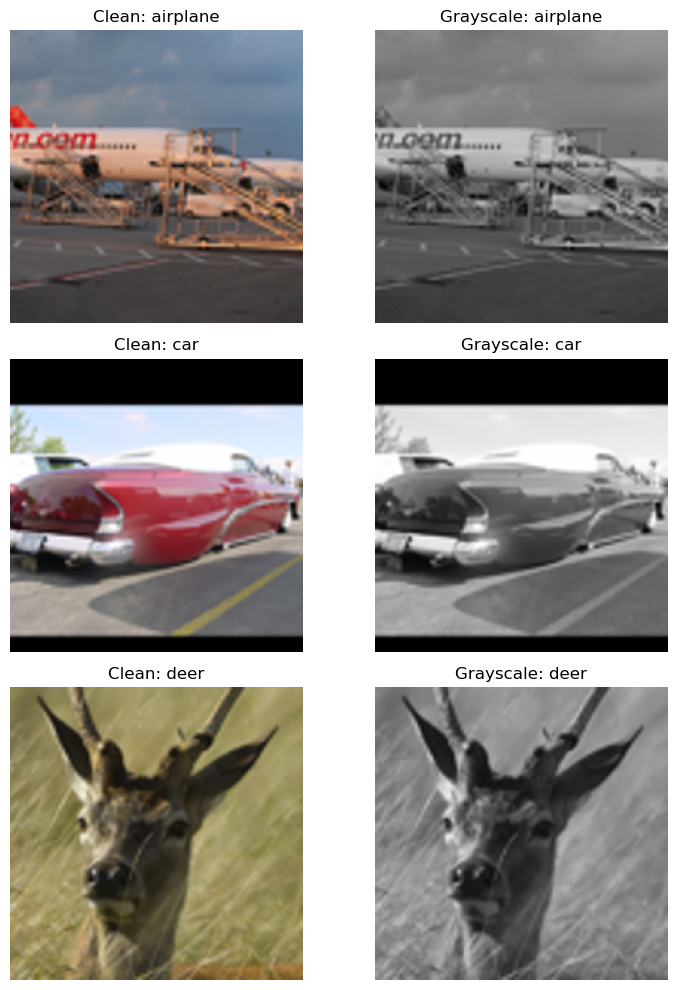

In [52]:
import matplotlib.pyplot as plt


sample_positions = [0, 100, 200]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(8, 10)
)

for row, position in enumerate(sample_positions):
    dataset_index = int(test_indices[position])
    image, label = test_dataset[dataset_index]

    clean_image = common_transform(image)
    grayscale_image = grayscale_intervention(clean_image)

    axes[row, 0].imshow(clean_image)
    axes[row, 0].set_title(
        f"Clean: {class_names[label]}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(grayscale_image)
    axes[row, 1].set_title(
        f"Grayscale: {class_names[label]}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [53]:
common_test_dataset = IndexedImageDataset(
    base_dataset=test_dataset,
    indices=test_indices,
    model_preprocess=ToTensor()
)

common_test_loader = DataLoader(
    common_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, labels, image_ids = next(
    iter(common_test_loader)
)

print("Batch shape:", images.shape)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())



Batch shape: torch.Size([32, 3, 224, 224])
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [54]:
def grayscale_batch(images):
    red = images[:, 0:1, :, :]
    green = images[:, 1:2, :, :]
    blue = images[:, 2:3, :, :]

    gray = (
        0.2989 * red
        + 0.5870 * green
        + 0.1140 * blue
    )

    grayscale_images = gray.repeat(
        1, 3, 1, 1
    )

    return grayscale_images

In [55]:
imagenet_batch_normalize = Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)

clip_batch_normalize = Normalize(
    mean=(0.48145466, 0.4578275, 0.40821073),
    std=(0.26862954, 0.26130258, 0.27577711)
)


grayscale_images = grayscale_batch(images)

resnet_grayscale_input = imagenet_batch_normalize(
    grayscale_images
)

vit_grayscale_input = imagenet_batch_normalize(
    grayscale_images
)

clip_grayscale_input = clip_batch_normalize(
    grayscale_images
)


print("Common grayscale batch:", grayscale_images.shape)
print("ResNet input:", resnet_grayscale_input.shape)
print("ViT input:", vit_grayscale_input.shape)
print("CLIP input:", clip_grayscale_input.shape)

Common grayscale batch: torch.Size([32, 3, 224, 224])
ResNet input: torch.Size([32, 3, 224, 224])
ViT input: torch.Size([32, 3, 224, 224])
CLIP input: torch.Size([32, 3, 224, 224])


In [56]:
def extract_transformed_features(
    model,
    data_loader,
    batch_intervention,
    batch_normalizer,
    description,
    is_clip=False
):
    collected_features = []
    collected_labels = []
    collected_ids = []

    model.eval()

    with torch.inference_mode():

        for clean_images, labels, image_ids in tqdm(
            data_loader,
            desc=description
        ):
            # Move the common images to the GPU.
            clean_images = clean_images.to(device)

            # Apply grayscale or another intervention.
            transformed_images = batch_intervention(
                clean_images
            )

            # Apply the normalization required by the model.
            model_inputs = batch_normalizer(
                transformed_images
            )

            # Extract representations from the frozen backbone.
            if is_clip:
                batch_features = model.encode_image(
                    model_inputs
                )

                batch_features = F.normalize(
                    batch_features,
                    p=2,
                    dim=1
                )

            else:
                batch_features = model(model_inputs)

            # Store this batch on the CPU.
            collected_features.append(
                batch_features.cpu()
            )

            collected_labels.append(
                labels.cpu()
            )

            collected_ids.append(
                image_ids.cpu()
            )

    all_features = torch.cat(
        collected_features,
        dim=0
    )

    all_labels = torch.cat(
        collected_labels,
        dim=0
    )

    all_ids = torch.cat(
        collected_ids,
        dim=0
    )

    return all_features, all_labels, all_ids

In [57]:
resnet_grayscale_features, resnet_grayscale_labels, resnet_grayscale_ids = (
    extract_transformed_features(
        model=resnet,
        data_loader=common_test_loader,
        batch_intervention=grayscale_batch,
        batch_normalizer=imagenet_batch_normalize,
        description="ResNet grayscale features",
        is_clip=False
    )
)


vit_grayscale_features, vit_grayscale_labels, vit_grayscale_ids = (
    extract_transformed_features(
        model=vit,
        data_loader=common_test_loader,
        batch_intervention=grayscale_batch,
        batch_normalizer=imagenet_batch_normalize,
        description="ViT grayscale features",
        is_clip=False
    )
)


clip_grayscale_features, clip_grayscale_labels, clip_grayscale_ids = (
    extract_transformed_features(
        model=clip,
        data_loader=common_test_loader,
        batch_intervention=grayscale_batch,
        batch_normalizer=clip_batch_normalize,
        description="CLIP grayscale features",
        is_clip=True
    )
)


print("ResNet grayscale:", resnet_grayscale_features.shape)
print("ViT grayscale:", vit_grayscale_features.shape)
print("CLIP grayscale:", clip_grayscale_features.shape)

ResNet grayscale features:   0%|          | 0/16 [00:00<?, ?it/s]

ViT grayscale features:   0%|          | 0/16 [00:00<?, ?it/s]

CLIP grayscale features:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet grayscale: torch.Size([500, 2048])
ViT grayscale: torch.Size([500, 768])
CLIP grayscale: torch.Size([500, 512])


In [58]:
# Check that all three grayscale runs used the same image order.
assert torch.equal(
    resnet_grayscale_ids,
    vit_grayscale_ids
)

assert torch.equal(
    resnet_grayscale_ids,
    clip_grayscale_ids
)


# Check that grayscale images align with the clean images.
assert torch.equal(
    resnet_grayscale_ids,
    resnet_clean_ids
)


# Check that labels remained unchanged.
assert torch.equal(
    resnet_grayscale_labels,
    resnet_clean_labels
)

assert torch.equal(
    vit_grayscale_labels,
    vit_clean_labels
)

assert torch.equal(
    clip_grayscale_labels,
    clip_clean_labels
)


print("All grayscale features are aligned with clean features.")

All grayscale features are aligned with clean features.


In [59]:
def prediction_consistency(
    clean_predictions,
    transformed_predictions
):
    unchanged_predictions = (
        clean_predictions == transformed_predictions
    )

    consistency = (
        unchanged_predictions.float().mean().item()
    )

    return consistency

In [60]:
resnet_grayscale_metrics, resnet_grayscale_predictions, \
resnet_grayscale_probabilities, resnet_grayscale_confidence = (
    evaluate_linear_head(
        resnet_head,
        resnet_grayscale_features,
        resnet_grayscale_labels
    )
)


vit_grayscale_metrics, vit_grayscale_predictions, \
vit_grayscale_probabilities, vit_grayscale_confidence = (
    evaluate_linear_head(
        vit_head,
        vit_grayscale_features,
        vit_grayscale_labels
    )
)


clip_grayscale_metrics, clip_grayscale_predictions, \
clip_grayscale_probabilities, clip_grayscale_confidence = (
    evaluate_linear_head(
        clip_head,
        clip_grayscale_features,
        clip_grayscale_labels
    )
)

In [61]:
grayscale_head_results = pd.DataFrame([
    {
        "model": "ResNet-50 linear head",
        **resnet_grayscale_metrics,
        "accuracy_change":
            resnet_grayscale_metrics["accuracy"]
            - resnet_clean_metrics["accuracy"],
        "prediction_consistency": prediction_consistency(
            resnet_clean_predictions,
            resnet_grayscale_predictions
        )
    },

    {
        "model": "ViT-B/16 linear head",
        **vit_grayscale_metrics,
        "accuracy_change":
            vit_grayscale_metrics["accuracy"]
            - vit_clean_metrics["accuracy"],
        "prediction_consistency": prediction_consistency(
            vit_clean_predictions,
            vit_grayscale_predictions
        )
    },

    {
        "model": "CLIP ViT-B/32 linear head",
        **clip_grayscale_metrics,
        "accuracy_change":
            clip_grayscale_metrics["accuracy"]
            - clip_clean_metrics["accuracy"],
        "prediction_consistency": prediction_consistency(
            clip_clean_predictions,
            clip_grayscale_predictions
        )
    }
])


grayscale_head_results

,model,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,ResNet-50 linear head,0.960,0.959817,0.934014,-0.016,0.966
1,ViT-B/16 linear head,0.956,0.955852,0.954999,-0.016,0.954
2,CLIP ViT-B/32 linear head,0.952,0.951605,0.559327,-0.032,0.962


In [62]:
with torch.inference_mode():
    grayscale_similarities = (
        clip_grayscale_features.to(device)
        @ clip_text_features.T
    )

    grayscale_zero_shot_logits = (
        clip.logit_scale.exp()
        * grayscale_similarities
    )

    grayscale_zero_shot_probabilities = torch.softmax(
        grayscale_zero_shot_logits,
        dim=1
    )

    (
        grayscale_zero_shot_confidence,
        grayscale_zero_shot_predictions
    ) = grayscale_zero_shot_probabilities.max(dim=1)

In [63]:
grayscale_zero_shot_probabilities = (
    grayscale_zero_shot_probabilities.cpu()
)

grayscale_zero_shot_predictions = (
    grayscale_zero_shot_predictions.cpu()
)

grayscale_zero_shot_confidence = (
    grayscale_zero_shot_confidence.cpu()
)

In [64]:
grayscale_zero_shot_metrics = {
    "accuracy": accuracy_score(
        clip_grayscale_labels.numpy(),
        grayscale_zero_shot_predictions.numpy()
    ),

    "macro_f1": f1_score(
        clip_grayscale_labels.numpy(),
        grayscale_zero_shot_predictions.numpy(),
        average="macro"
    ),

    "mean_max_confidence":
        grayscale_zero_shot_confidence.mean().item()
}

In [65]:
grayscale_results = pd.concat([
    grayscale_head_results,

    pd.DataFrame([{
        "model": "CLIP ViT-B/32 zero-shot",
        **grayscale_zero_shot_metrics,

        "accuracy_change":
            grayscale_zero_shot_metrics["accuracy"]
            - clip_zero_shot_metrics["accuracy"],

        "prediction_consistency":
            prediction_consistency(
                clip_zero_shot_predictions,
                grayscale_zero_shot_predictions
            )
    }])
], ignore_index=True)


grayscale_results

,model,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,ResNet-50 linear head,0.960,0.959817,0.934014,-0.016,0.966
1,ViT-B/16 linear head,0.956,0.955852,0.954999,-0.016,0.954
2,CLIP ViT-B/32 linear head,0.952,0.951605,0.559327,-0.032,0.962
3,CLIP ViT-B/32 zero-shot,0.944,0.943117,0.926939,-0.024,0.954


In [66]:
def hue_rotation_batch(images):
    rotated_images = TF.adjust_hue(
        images,
        hue_factor=0.25
    )

    return rotated_images

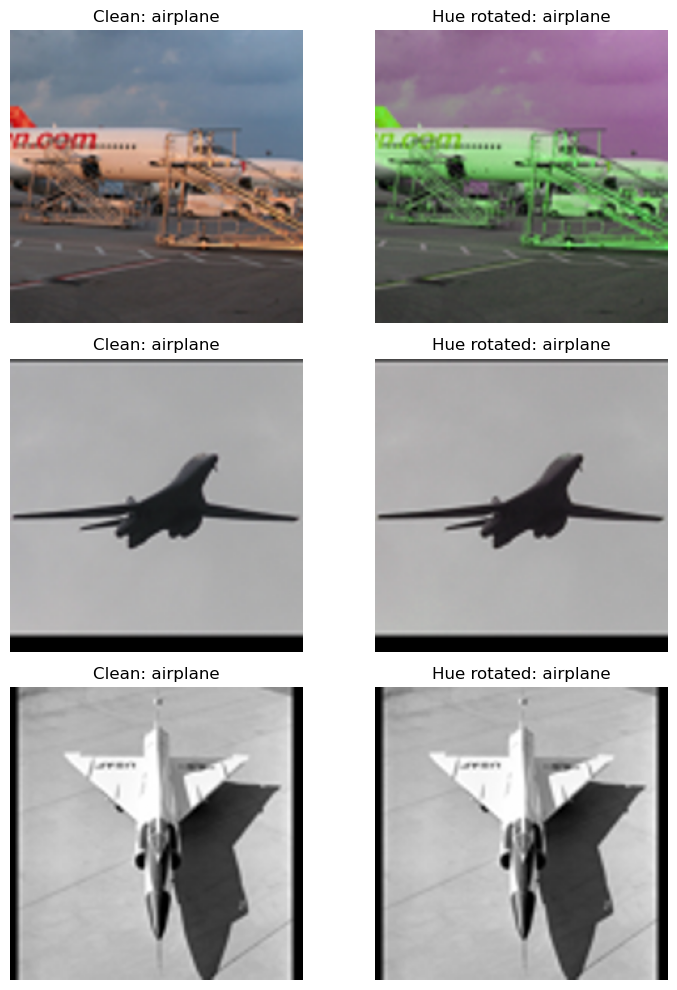

In [67]:
sample_images, sample_labels, sample_ids = next(
    iter(common_test_loader)
)

sample_hue_images = hue_rotation_batch(
    sample_images
)


fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(8, 10)
)

for row in range(3):
    clean_image = sample_images[row].permute(
        1, 2, 0
    )

    hue_image = sample_hue_images[row].permute(
        1, 2, 0
    )

    class_name = class_names[
        sample_labels[row].item()
    ]

    axes[row, 0].imshow(clean_image)
    axes[row, 0].set_title(
        f"Clean: {class_name}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(hue_image)
    axes[row, 1].set_title(
        f"Hue rotated: {class_name}"
    )
    axes[row, 1].axis("off")


plt.tight_layout()
plt.show()

In [68]:
resnet_hue_features, resnet_hue_labels, resnet_hue_ids = (
    extract_transformed_features(
        model=resnet,
        data_loader=common_test_loader,
        batch_intervention=hue_rotation_batch,
        batch_normalizer=imagenet_batch_normalize,
        description="ResNet hue features",
        is_clip=False
    )
)


vit_hue_features, vit_hue_labels, vit_hue_ids = (
    extract_transformed_features(
        model=vit,
        data_loader=common_test_loader,
        batch_intervention=hue_rotation_batch,
        batch_normalizer=imagenet_batch_normalize,
        description="ViT hue features",
        is_clip=False
    )
)


clip_hue_features, clip_hue_labels, clip_hue_ids = (
    extract_transformed_features(
        model=clip,
        data_loader=common_test_loader,
        batch_intervention=hue_rotation_batch,
        batch_normalizer=clip_batch_normalize,
        description="CLIP hue features",
        is_clip=True
    )
)


print("ResNet hue features:", resnet_hue_features.shape)
print("ViT hue features:", vit_hue_features.shape)
print("CLIP hue features:", clip_hue_features.shape)

ResNet hue features:   0%|          | 0/16 [00:00<?, ?it/s]

ViT hue features:   0%|          | 0/16 [00:00<?, ?it/s]

CLIP hue features:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet hue features: torch.Size([500, 2048])
ViT hue features: torch.Size([500, 768])
CLIP hue features: torch.Size([500, 512])


In [69]:
assert torch.equal(
    resnet_hue_ids,
    vit_hue_ids
)

assert torch.equal(
    resnet_hue_ids,
    clip_hue_ids
)


assert torch.equal(
    resnet_hue_ids,
    resnet_clean_ids
)


assert torch.equal(
    resnet_hue_labels,
    resnet_clean_labels
)

assert torch.equal(
    vit_hue_labels,
    vit_clean_labels
)

assert torch.equal(
    clip_hue_labels,
    clip_clean_labels
)


print("All hue-rotated features are aligned with clean features.")

All hue-rotated features are aligned with clean features.


In [70]:
resnet_hue_metrics, resnet_hue_predictions, resnet_hue_probabilities, resnet_hue_confidence = evaluate_linear_head(
    resnet_head,
    resnet_hue_features,
    resnet_hue_labels
)

vit_hue_metrics, vit_hue_predictions, vit_hue_probabilities, vit_hue_confidence = evaluate_linear_head(
    vit_head,
    vit_hue_features,
    vit_hue_labels
)

clip_hue_metrics, clip_hue_predictions, clip_hue_probabilities, clip_hue_confidence = evaluate_linear_head(
    clip_head,
    clip_hue_features,
    clip_hue_labels
)

hue_head_results = pd.DataFrame([
    {
        "model": "ResNet-50 linear head",
        **resnet_hue_metrics,
        "accuracy_change": resnet_hue_metrics["accuracy"] - resnet_clean_metrics["accuracy"],
        "prediction_consistency": prediction_consistency(
            resnet_clean_predictions,
            resnet_hue_predictions
        )
    },
    {
        "model": "ViT-B/16 linear head",
        **vit_hue_metrics,
        "accuracy_change": vit_hue_metrics["accuracy"] - vit_clean_metrics["accuracy"],
        "prediction_consistency": prediction_consistency(
            vit_clean_predictions,
            vit_hue_predictions
        )
    },
    {
        "model": "CLIP ViT-B/32 linear head",
        **clip_hue_metrics,
        "accuracy_change": clip_hue_metrics["accuracy"] - clip_clean_metrics["accuracy"],
        "prediction_consistency": prediction_consistency(
            clip_clean_predictions,
            clip_hue_predictions
        )
    }
])

hue_head_results

,model,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,ResNet-50 linear head,0.934,0.933752,0.915810,-0.042,0.938
1,ViT-B/16 linear head,0.942,0.941936,0.928539,-0.030,0.944
2,CLIP ViT-B/32 linear head,0.932,0.931919,0.529907,-0.052,0.938


In [71]:
with torch.inference_mode():
    clip_hue_logits = (
        clip.logit_scale.exp()
        * clip_hue_features.to(device)
        @ clip_text_features.T
    )

    clip_hue_zero_shot_probabilities = torch.softmax(
        clip_hue_logits,
        dim=1
    )

    clip_hue_zero_shot_confidence, clip_hue_zero_shot_predictions = (
        clip_hue_zero_shot_probabilities.max(dim=1)
    )

clip_hue_zero_shot_predictions = clip_hue_zero_shot_predictions.cpu()
clip_hue_zero_shot_confidence = clip_hue_zero_shot_confidence.cpu()
clip_hue_zero_shot_probabilities = clip_hue_zero_shot_probabilities.cpu()

clip_hue_zero_shot_metrics = {
    "accuracy": accuracy_score(
        clip_hue_labels,
        clip_hue_zero_shot_predictions
    ),
    "macro_f1": f1_score(
        clip_hue_labels,
        clip_hue_zero_shot_predictions,
        average="macro"
    ),
    "mean_max_confidence": clip_hue_zero_shot_confidence.mean().item()
}

clip_hue_zero_shot_result = pd.DataFrame([
    {
        "model": "CLIP ViT-B/32 zero-shot",
        **clip_hue_zero_shot_metrics,
        "accuracy_change": (
            clip_hue_zero_shot_metrics["accuracy"]
            - clip_zero_shot_metrics["accuracy"]
        ),
        "prediction_consistency": prediction_consistency(
            clip_zero_shot_predictions,
            clip_hue_zero_shot_predictions
        )
    }
])

hue_results = pd.concat(
    [hue_head_results, clip_hue_zero_shot_result],
    ignore_index=True
)

hue_results

,model,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,ResNet-50 linear head,0.934,0.933752,0.915810,-0.042,0.938
1,ViT-B/16 linear head,0.942,0.941936,0.928539,-0.030,0.944
2,CLIP ViT-B/32 linear head,0.932,0.931919,0.529907,-0.052,0.938
3,CLIP ViT-B/32 zero-shot,0.926,0.924460,0.919187,-0.042,0.932


In [72]:
clean_comparison = clean_results.copy()
clean_comparison["intervention"] = "clean"
clean_comparison["accuracy_change"] = 0.0
clean_comparison["prediction_consistency"] = 1.0

grayscale_comparison = grayscale_results.copy()
grayscale_comparison["intervention"] = "grayscale"

hue_comparison = hue_results.copy()
hue_comparison["intervention"] = "hue_rotation"

color_results = pd.concat(
    [
        clean_comparison,
        grayscale_comparison,
        hue_comparison
    ],
    ignore_index=True
)

color_results = color_results[
    [
        "intervention",
        "model",
        "accuracy",
        "macro_f1",
        "mean_max_confidence",
        "accuracy_change",
        "prediction_consistency"
    ]
]

color_results.to_csv(
    "results/color_intervention_metrics.csv",
    index=False
)

color_results

,intervention,model,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,clean,ResNet-50 linear head,0.976,0.976056,0.936145,0.000,1.000
1,clean,ViT-B/16 linear head,0.972,0.971915,0.961531,0.000,1.000
2,clean,CLIP ViT-B/32 linear head,0.984,0.983997,0.614167,0.000,1.000
3,clean,CLIP ViT-B/32 zero-shot,0.968,0.967524,0.942698,0.000,1.000
4,grayscale,ResNet-50 linear head,0.960,0.959817,0.934014,-0.016,0.966
5,grayscale,ViT-B/16 linear head,0.956,0.955852,0.954999,-0.016,0.954
6,grayscale,CLIP ViT-B/32 linear head,0.952,0.951605,0.559327,-0.032,0.962
7,grayscale,CLIP ViT-B/32 zero-shot,0.944,0.943117,0.926939,-0.024,0.954
8,hue_rotation,ResNet-50 linear head,0.934,0.933752,0.915810,-0.042,0.938
9,hue_rotation,ViT-B/16 linear head,0.942,0.941936,0.928539,-0.030,0.944


In [73]:
from pathlib import Path
import shutil

REBUILD_CUE_CONFLICT_ASSETS = False

cue_conflict_directory = Path(
    "results/cue_conflicts"
)

candidate_manifest_path = (
    cue_conflict_directory
    / "candidate_manifest.csv"
)

review_workbook_path = (
    cue_conflict_directory
    / "cue_conflict_review.xlsx"
)

review_backup_path = (
    cue_conflict_directory
    / "cue_conflict_review_tagged_backup.xlsx"
)

reviewed_manifest_path = (
    cue_conflict_directory
    / "reviewed_candidate_manifest.csv"
)

final_manifest_path = (
    cue_conflict_directory
    / "final_cue_conflict_manifest.csv"
)

cue_conflict_directory.mkdir(
    parents=True,
    exist_ok=True
)

if review_workbook_path.exists():
    if not review_backup_path.exists():
        shutil.copy2(
            review_workbook_path,
            review_backup_path
        )

    print(
        "Existing manual review workbook is protected:",
        review_workbook_path
    )

    print(
        "Backup workbook:",
        review_backup_path
    )
else:
    print(
        "No existing review workbook was found."
    )

print(
    "Rebuilding cue-conflict assets:",
    REBUILD_CUE_CONFLICT_ASSETS
)

Existing manual review workbook is protected: results\cue_conflicts\cue_conflict_review.xlsx
Backup workbook: results\cue_conflicts\cue_conflict_review_tagged_backup.xlsx
Rebuilding cue-conflict assets: False


In [74]:
CUE_CONFLICT_SEED = 6304
STYLE_STRENGTH = 0.8
CANDIDATES_PER_DIRECTION = 30
ACCEPTED_PER_DIRECTION = 20
MINIMUM_VALID_CONFLICTS = 200

cue_conflict_pairs = [
    ("airplane", "monkey"),
    ("car", "deer"),
    ("ship", "cat"),
    ("truck", "horse"),
    ("bird", "dog")
]

class_to_index = {
    class_name: class_index
    for class_index, class_name in enumerate(class_names)
}

cue_conflict_plan = []

for class_a, class_b in cue_conflict_pairs:
    for content_class, style_class in [
        (class_a, class_b),
        (class_b, class_a)
    ]:
        cue_conflict_plan.append({
            "content_class": content_class,
            "style_class": style_class,
            "content_label": class_to_index[content_class],
            "style_label": class_to_index[style_class],
            "planned_candidates": CANDIDATES_PER_DIRECTION,
            "required_accepted": ACCEPTED_PER_DIRECTION
        })

cue_conflict_plan = pd.DataFrame(cue_conflict_plan)

VISUAL_REJECTION_RULE = (
    "Reject an image if the content object is no longer recognizable, "
    "the source style is not visibly transferred, severe artifacts obscure "
    "a substantial part of the object, or the output is blank or corrupted."
)

CUE_CONFLICT_HYPOTHESIS = (
    "The models may differ in whether their predictions follow content shape "
    "or transferred style. ResNet may produce more style-label decisions than "
    "ViT and CLIP, but the result must be interpreted with coverage and cannot "
    "be attributed to architecture alone."
)

print(cue_conflict_plan)
print("\nPlanned candidates:", cue_conflict_plan["planned_candidates"].sum())
print("Required accepted:", cue_conflict_plan["required_accepted"].sum())
print("\nVisual rejection rule:")
print(VISUAL_REJECTION_RULE)
print("\nHypothesis:")
print(CUE_CONFLICT_HYPOTHESIS)

  content_class style_class  content_label  style_label  planned_candidates  \
0      airplane      monkey              0            7                  30   
1        monkey    airplane              7            0                  30   
2           car        deer              2            4                  30   
3          deer         car              4            2                  30   
4          ship         cat              8            3                  30   
5           cat        ship              3            8                  30   
6         truck       horse              9            6                  30   
7         horse       truck              6            9                  30   
8          bird         dog              1            5                  30   
9           dog        bird              5            1                  30   

   required_accepted  
0                 20  
1                 20  
2                 20  
3                 20  
4              

In [75]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

external_directory = Path("external")
adain_directory = external_directory / "pytorch-AdaIN"
archive_path = external_directory / "pytorch-AdaIN.zip"

external_directory.mkdir(exist_ok=True)

if not adain_directory.exists():
    urlretrieve(
        "https://github.com/naoto0804/pytorch-AdaIN/archive/refs/heads/master.zip",
        archive_path
    )

    with zipfile.ZipFile(archive_path, "r") as archive:
        archive.extractall(external_directory)

    (external_directory / "pytorch-AdaIN-master").rename(
        adain_directory
    )

    archive_path.unlink()

model_directory = adain_directory / "models"
model_directory.mkdir(exist_ok=True)

model_urls = {
    "vgg_normalised.pth": (
        "https://github.com/naoto0804/pytorch-AdaIN/releases/"
        "download/v0.0.0/vgg_normalised.pth"
    ),
    "decoder.pth": (
        "https://github.com/naoto0804/pytorch-AdaIN/releases/"
        "download/v0.0.0/decoder.pth"
    )
}

for filename, url in model_urls.items():
    destination = model_directory / filename

    if not destination.exists():
        urlretrieve(url, destination)

for model_path in model_directory.glob("*.pth"):
    size_in_megabytes = model_path.stat().st_size / (1024 ** 2)
    print(model_path.name, f"{size_in_megabytes:.1f} MB")

decoder.pth 13.4 MB
vgg_normalised.pth 76.4 MB


In [76]:
import sys
import torch.nn as nn

adain_source_path = str(adain_directory.resolve())

if adain_source_path not in sys.path:
    sys.path.insert(0, adain_source_path)

import net as adain_net
from function import adaptive_instance_normalization

vgg_weights_path = model_directory / "vgg_normalised.pth"
decoder_weights_path = model_directory / "decoder.pth"

adain_vgg = adain_net.vgg
adain_decoder = adain_net.decoder

adain_vgg.load_state_dict(
    torch.load(vgg_weights_path, map_location=device)
)

adain_decoder.load_state_dict(
    torch.load(decoder_weights_path, map_location=device)
)

adain_vgg = nn.Sequential(
    *list(adain_vgg.children())[:31]
)

adain_vgg = adain_vgg.to(device).eval()
adain_decoder = adain_decoder.to(device).eval()

adain_vgg.requires_grad_(False)
adain_decoder.requires_grad_(False)

print("AdaIN encoder loaded:", type(adain_vgg))
print("AdaIN decoder loaded:", type(adain_decoder))
print("Device:", device)

AdaIN encoder loaded: <class 'torch.nn.modules.container.Sequential'>
AdaIN decoder loaded: <class 'torch.nn.modules.container.Sequential'>
Device: cuda


In [77]:
def stylize_with_adain(
    content_images,
    style_images,
    style_strength=STYLE_STRENGTH
):
    if content_images.shape != style_images.shape:
        raise ValueError(
            "Content and style batches must have the same shape."
        )

    if not 0.0 <= style_strength <= 1.0:
        raise ValueError(
            "Style strength must be between 0 and 1."
        )

    content_images = content_images.to(device)
    style_images = style_images.to(device)

    with torch.inference_mode():
        content_features = adain_vgg(content_images)
        style_features = adain_vgg(style_images)

        transferred_features = adaptive_instance_normalization(
            content_features,
            style_features
        )

        blended_features = (
            style_strength * transferred_features
            + (1.0 - style_strength) * content_features
        )

        stylized_images = adain_decoder(blended_features)
        stylized_images = stylized_images.clamp(0.0, 1.0)

    return stylized_images.cpu()

In [78]:
pilot_generator = torch.Generator().manual_seed(
    CUE_CONFLICT_SEED
)

samples_by_label = {
    label: []
    for label in range(len(class_names))
}

for dataset_position in range(len(common_test_dataset)):
    image, label, image_id = common_test_dataset[dataset_position]

    samples_by_label[int(label)].append(
        (image, int(image_id))
    )

pilot_content_images = []
pilot_style_images = []
pilot_records = []

for content_class, style_class in cue_conflict_pairs:
    content_label = class_to_index[content_class]
    style_label = class_to_index[style_class]

    content_candidates = samples_by_label[content_label]
    style_candidates = samples_by_label[style_label]

    content_choice = torch.randint(
        len(content_candidates),
        size=(1,),
        generator=pilot_generator
    ).item()

    style_choice = torch.randint(
        len(style_candidates),
        size=(1,),
        generator=pilot_generator
    ).item()

    content_image, content_id = content_candidates[content_choice]
    style_image, style_id = style_candidates[style_choice]

    pilot_content_images.append(content_image)
    pilot_style_images.append(style_image)

    pilot_records.append({
        "content_class": content_class,
        "content_id": content_id,
        "style_class": style_class,
        "style_id": style_id
    })

pilot_content_images = torch.stack(
    pilot_content_images
)

pilot_style_images = torch.stack(
    pilot_style_images
)

pilot_records = pd.DataFrame(pilot_records)

print("Content batch:", pilot_content_images.shape)
print("Style batch:", pilot_style_images.shape)

pilot_records

Content batch: torch.Size([5, 3, 224, 224])
Style batch: torch.Size([5, 3, 224, 224])


,content_class,content_id,style_class,style_id
0,airplane,5918,monkey,1711
1,car,35,deer,766
2,ship,194,cat,7797
3,truck,1022,horse,5857
4,bird,1852,dog,4547


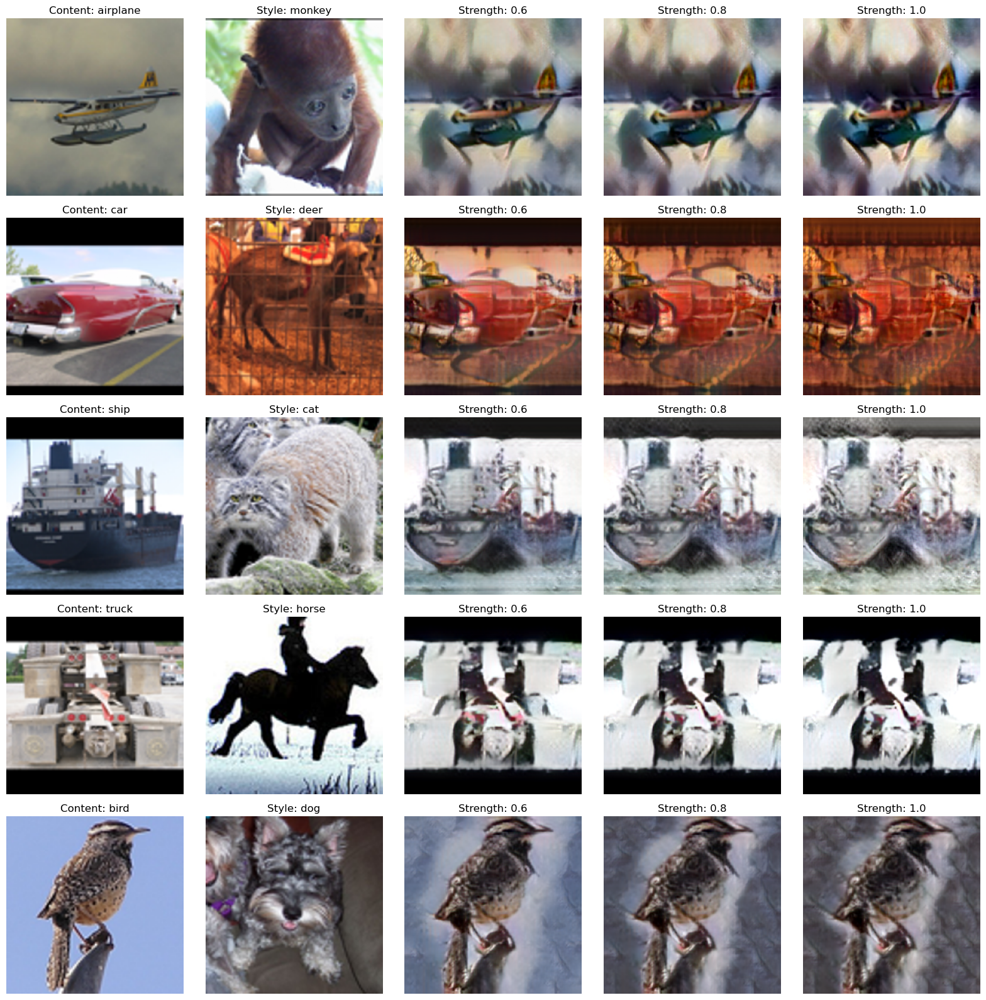

In [79]:
pilot_strengths = [0.6, 0.8, 1.0]

pilot_outputs = {
    strength: stylize_with_adain(
        pilot_content_images,
        pilot_style_images,
        style_strength=strength
    )
    for strength in pilot_strengths
}

figure, axes = plt.subplots(
    nrows=len(pilot_records),
    ncols=5,
    figsize=(16, 16)
)

for row_index, record in pilot_records.iterrows():
    axes[row_index, 0].imshow(
        pilot_content_images[row_index].permute(1, 2, 0)
    )
    axes[row_index, 0].set_title(
        f"Content: {record['content_class']}"
    )

    axes[row_index, 1].imshow(
        pilot_style_images[row_index].permute(1, 2, 0)
    )
    axes[row_index, 1].set_title(
        f"Style: {record['style_class']}"
    )

    for column_index, strength in enumerate(
        pilot_strengths,
        start=2
    ):
        axes[row_index, column_index].imshow(
            pilot_outputs[strength][row_index].permute(1, 2, 0)
        )
        axes[row_index, column_index].set_title(
            f"Strength: {strength}"
        )

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()
plt.show()

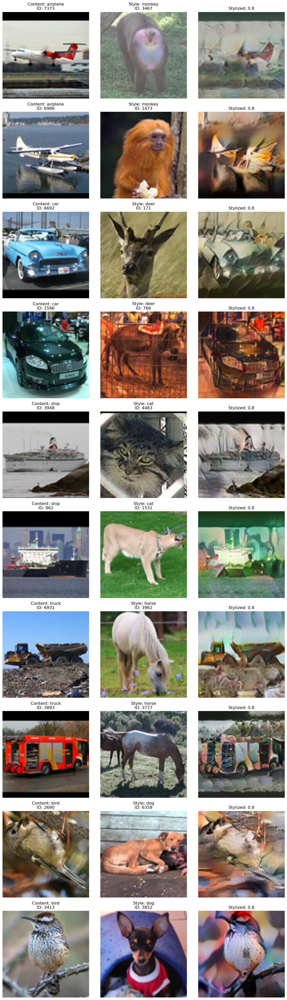

In [80]:
DIAGNOSTIC_EXAMPLES_PER_PAIR = 2
DIAGNOSTIC_STRENGTH = 0.8

diagnostic_generator = torch.Generator().manual_seed(
    CUE_CONFLICT_SEED + 1
)

diagnostic_content_images = []
diagnostic_style_images = []
diagnostic_records = []

for content_class, style_class in cue_conflict_pairs:
    content_label = class_to_index[content_class]
    style_label = class_to_index[style_class]

    content_candidates = samples_by_label[content_label]
    style_candidates = samples_by_label[style_label]

    for example_number in range(DIAGNOSTIC_EXAMPLES_PER_PAIR):
        content_choice = torch.randint(
            len(content_candidates),
            size=(1,),
            generator=diagnostic_generator
        ).item()

        style_choice = torch.randint(
            len(style_candidates),
            size=(1,),
            generator=diagnostic_generator
        ).item()

        content_image, content_id = content_candidates[content_choice]
        style_image, style_id = style_candidates[style_choice]

        diagnostic_content_images.append(content_image)
        diagnostic_style_images.append(style_image)

        diagnostic_records.append({
            "content_class": content_class,
            "content_id": content_id,
            "style_class": style_class,
            "style_id": style_id
        })

diagnostic_content_images = torch.stack(
    diagnostic_content_images
)

diagnostic_style_images = torch.stack(
    diagnostic_style_images
)

diagnostic_outputs = stylize_with_adain(
    diagnostic_content_images,
    diagnostic_style_images,
    style_strength=DIAGNOSTIC_STRENGTH
)

diagnostic_records = pd.DataFrame(diagnostic_records)

figure, axes = plt.subplots(
    nrows=len(diagnostic_records),
    ncols=3,
    figsize=(12, 4 * len(diagnostic_records))
)

for row_index, record in diagnostic_records.iterrows():
    axes[row_index, 0].imshow(
        diagnostic_content_images[row_index].permute(1, 2, 0)
    )
    axes[row_index, 0].set_title(
        f"Content: {record['content_class']}\nID: {record['content_id']}"
    )

    axes[row_index, 1].imshow(
        diagnostic_style_images[row_index].permute(1, 2, 0)
    )
    axes[row_index, 1].set_title(
        f"Style: {record['style_class']}\nID: {record['style_id']}"
    )

    axes[row_index, 2].imshow(
        diagnostic_outputs[row_index].permute(1, 2, 0)
    )
    axes[row_index, 2].set_title(
        f"Stylized: {DIAGNOSTIC_STRENGTH}"
    )

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()
plt.show()

In [81]:
STYLE_STRENGTH = 0.8
CANDIDATES_PER_DIRECTION = 30
ACCEPTED_PER_DIRECTION = 20

VISUAL_REJECTION_RULE = (
    "Reject a candidate if the content object is no longer recognizable, "
    "the source style produces no visible alteration, the output is blank "
    "or corrupted, or severe artifacts make the content-style combination "
    "uninterpretable. Review decisions must be made without model predictions."
)

cue_conflict_directory = Path(
    "results/cue_conflicts"
)

candidate_image_directory = (
    cue_conflict_directory
    / "candidates"
)

candidate_manifest_path = (
    cue_conflict_directory
    / "candidate_manifest.csv"
)

cue_conflict_directory.mkdir(
    parents=True,
    exist_ok=True
)

candidate_image_directory.mkdir(
    parents=True,
    exist_ok=True
)

if (
    candidate_manifest_path.exists()
    and not REBUILD_CUE_CONFLICT_ASSETS
):
    candidate_manifest = pd.read_csv(
        candidate_manifest_path
    )

    print(
        "Loaded existing candidate manifest:",
        candidate_manifest_path
    )

    print(
        "Manifest rows:",
        len(candidate_manifest)
    )
else:
    candidate_generator = (
        torch.Generator().manual_seed(
            CUE_CONFLICT_SEED
        )
    )

    candidate_records = []

    for pair_number, (
        class_a,
        class_b
    ) in enumerate(
        cue_conflict_pairs,
        start=1
    ):
        directions = [
            (class_a, class_b),
            (class_b, class_a)
        ]

        for direction_number, (
            content_class,
            style_class
        ) in enumerate(
            directions,
            start=1
        ):
            content_label = class_to_index[
                content_class
            ]

            style_label = class_to_index[
                style_class
            ]

            content_candidates = samples_by_label[
                content_label
            ]

            style_candidates = samples_by_label[
                style_label
            ]

            content_order = torch.randperm(
                len(content_candidates),
                generator=candidate_generator
            )[:CANDIDATES_PER_DIRECTION]

            style_order = torch.randperm(
                len(style_candidates),
                generator=candidate_generator
            )[:CANDIDATES_PER_DIRECTION]

            for candidate_number in range(
                CANDIDATES_PER_DIRECTION
            ):
                content_position = content_order[
                    candidate_number
                ].item()

                style_position = style_order[
                    candidate_number
                ].item()

                content_image, content_id = (
                    content_candidates[
                        content_position
                    ]
                )

                style_image, style_id = (
                    style_candidates[
                        style_position
                    ]
                )

                conflict_id = (
                    f"pair_{pair_number:02d}_"
                    f"direction_{direction_number}_"
                    f"candidate_{candidate_number + 1:02d}"
                )

                candidate_records.append({
                    "conflict_id": conflict_id,
                    "pair_number": pair_number,
                    "direction_number": direction_number,
                    "content_class": content_class,
                    "content_label": content_label,
                    "content_id": content_id,
                    "style_class": style_class,
                    "style_label": style_label,
                    "style_id": style_id,
                    "style_strength": STYLE_STRENGTH,
                    "output_path": str(
                        candidate_image_directory
                        / f"{conflict_id}.png"
                    ),
                    "review_status": "pending",
                    "rejection_reason": ""
                })

    candidate_manifest = pd.DataFrame(
        candidate_records
    )

    candidate_manifest.to_csv(
        candidate_manifest_path,
        index=False
    )

    print(
        "New candidate manifest created:",
        candidate_manifest_path
    )

print(
    "Total candidates:",
    len(candidate_manifest)
)

candidate_manifest.groupby(
    [
        "content_class",
        "style_class"
    ]
).size()

Loaded existing candidate manifest: results\cue_conflicts\candidate_manifest.csv
Manifest rows: 300
Total candidates: 300


content_class  style_class
airplane       monkey         30
bird           dog            30
car            deer           30
cat            ship           30
deer           car            30
dog            bird           30
horse          truck          30
monkey         airplane       30
ship           cat            30
truck          horse          30
dtype: int64

In [82]:
from torchvision.transforms.functional import to_pil_image

CUE_CONFLICT_BATCH_SIZE = 16

content_preview_directory = (
    cue_conflict_directory
    / "review_thumbnails"
    / "content"
)

style_preview_directory = (
    cue_conflict_directory
    / "review_thumbnails"
    / "style"
)

stylized_preview_directory = (
    cue_conflict_directory
    / "review_thumbnails"
    / "stylized"
)

for directory in [
    content_preview_directory,
    style_preview_directory,
    stylized_preview_directory
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

required_asset_columns = [
    "output_path",
    "content_preview_path",
    "style_preview_path",
    "stylized_preview_path"
]

asset_columns_exist = all(
    column in candidate_manifest.columns
    for column in required_asset_columns
)

if asset_columns_exist:
    all_candidate_assets_exist = all(
        candidate_manifest[column]
        .notna()
        .all()
        and all(
            Path(file_path).exists()
            for file_path in candidate_manifest[
                column
            ]
        )
        for column in required_asset_columns
    )
else:
    all_candidate_assets_exist = False

if (
    all_candidate_assets_exist
    and not REBUILD_CUE_CONFLICT_ASSETS
):
    print(
        "All existing cue-conflict images "
        "and thumbnails were preserved."
    )

    print(
        "Candidate images:",
        len(candidate_manifest)
    )
else:
    images_by_id = {}

    for class_samples in samples_by_label.values():
        for image, image_id in class_samples:
            images_by_id[
                int(image_id)
            ] = image

    for batch_start in tqdm(
        range(
            0,
            len(candidate_manifest),
            CUE_CONFLICT_BATCH_SIZE
        ),
        desc="Generating missing cue conflicts"
    ):
        batch_end = min(
            batch_start
            + CUE_CONFLICT_BATCH_SIZE,
            len(candidate_manifest)
        )

        batch_records = candidate_manifest.iloc[
            batch_start:batch_end
        ]

        content_batch = torch.stack([
            images_by_id[
                int(image_id)
            ]
            for image_id in batch_records[
                "content_id"
            ]
        ])

        style_batch = torch.stack([
            images_by_id[
                int(image_id)
            ]
            for image_id in batch_records[
                "style_id"
            ]
        ])

        stylized_batch = stylize_with_adain(
            content_batch,
            style_batch,
            style_strength=STYLE_STRENGTH
        )

        for batch_position, (
            row_index,
            record
        ) in enumerate(
            batch_records.iterrows()
        ):
            conflict_id = record[
                "conflict_id"
            ]

            content_image = to_pil_image(
                content_batch[
                    batch_position
                ]
            )

            style_image = to_pil_image(
                style_batch[
                    batch_position
                ]
            )

            stylized_image = to_pil_image(
                stylized_batch[
                    batch_position
                ]
            )

            output_path = Path(
                record["output_path"]
            )

            content_preview_path = (
                content_preview_directory
                / f"{conflict_id}.png"
            )

            style_preview_path = (
                style_preview_directory
                / f"{conflict_id}.png"
            )

            stylized_preview_path = (
                stylized_preview_directory
                / f"{conflict_id}.png"
            )

            if (
                REBUILD_CUE_CONFLICT_ASSETS
                or not output_path.exists()
            ):
                stylized_image.save(
                    output_path
                )

            if (
                REBUILD_CUE_CONFLICT_ASSETS
                or not content_preview_path.exists()
            ):
                content_image.resize(
                    (96, 96)
                ).save(
                    content_preview_path
                )

            if (
                REBUILD_CUE_CONFLICT_ASSETS
                or not style_preview_path.exists()
            ):
                style_image.resize(
                    (96, 96)
                ).save(
                    style_preview_path
                )

            if (
                REBUILD_CUE_CONFLICT_ASSETS
                or not stylized_preview_path.exists()
            ):
                stylized_image.resize(
                    (96, 96)
                ).save(
                    stylized_preview_path
                )

            candidate_manifest.loc[
                row_index,
                "content_preview_path"
            ] = str(
                content_preview_path
            )

            candidate_manifest.loc[
                row_index,
                "style_preview_path"
            ] = str(
                style_preview_path
            )

            candidate_manifest.loc[
                row_index,
                "stylized_preview_path"
            ] = str(
                stylized_preview_path
            )

    candidate_manifest.to_csv(
        candidate_manifest_path,
        index=False
    )

    print(
        "Missing cue-conflict assets generated."
    )

generated_files = list(
    candidate_image_directory.glob(
        "*.png"
    )
)

print(
    "Generated candidate images:",
    len(generated_files)
)

print(
    "Manifest rows:",
    len(candidate_manifest)
)

All existing cue-conflict images and thumbnails were preserved.
Candidate images: 300
Generated candidate images: 300
Manifest rows: 300


In [83]:
from openpyxl import Workbook
from openpyxl.drawing.image import Image as ExcelImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.worksheet.datavalidation import DataValidation

review_workbook_path = (
    cue_conflict_directory
    / "cue_conflict_review.xlsx"
)

if (
    review_workbook_path.exists()
    and not REBUILD_CUE_CONFLICT_ASSETS
):
    print(
        "Existing manually tagged workbook preserved:"
    )

    print(
        review_workbook_path
    )
else:
    required_preview_columns = [
        "content_preview_path",
        "style_preview_path",
        "stylized_preview_path"
    ]

    missing_preview_files = []

    for column_name in required_preview_columns:
        for file_path in candidate_manifest[column_name]:
            if not Path(file_path).exists():
                missing_preview_files.append(
                    file_path
                )

    if missing_preview_files:
        raise FileNotFoundError(
            f"{len(missing_preview_files)} "
            f"preview files are missing."
        )

    workbook = Workbook()

    review_sheet = workbook.active

    review_sheet.title = (
        "Cue Conflict Review"
    )

    headers = [
        "conflict_id",
        "pair_number",
        "direction_number",
        "content_class",
        "content_id",
        "content_image",
        "style_class",
        "style_id",
        "style_image",
        "stylized_image",
        "decision",
        "rejection_reason",
        "notes"
    ]

    review_sheet.append(
        headers
    )

    for cell in review_sheet[1]:
        cell.font = Font(
            bold=True,
            color="FFFFFF"
        )

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor="1F4E78"
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    for excel_row, (_, record) in enumerate(
        candidate_manifest.iterrows(),
        start=2
    ):
        review_sheet.cell(
            excel_row,
            1,
            record["conflict_id"]
        )

        review_sheet.cell(
            excel_row,
            2,
            int(record["pair_number"])
        )

        review_sheet.cell(
            excel_row,
            3,
            int(record["direction_number"])
        )

        review_sheet.cell(
            excel_row,
            4,
            record["content_class"]
        )

        review_sheet.cell(
            excel_row,
            5,
            int(record["content_id"])
        )

        review_sheet.cell(
            excel_row,
            7,
            record["style_class"]
        )

        review_sheet.cell(
            excel_row,
            8,
            int(record["style_id"])
        )

        image_locations = [
            (
                record["content_preview_path"],
                f"F{excel_row}"
            ),
            (
                record["style_preview_path"],
                f"I{excel_row}"
            ),
            (
                record["stylized_preview_path"],
                f"J{excel_row}"
            )
        ]

        for image_path, cell_location in image_locations:
            excel_image = ExcelImage(
                image_path
            )

            excel_image.width = 96
            excel_image.height = 96

            review_sheet.add_image(
                excel_image,
                cell_location
            )

        review_sheet.row_dimensions[
            excel_row
        ].height = 75

        for column_number in range(
            1,
            len(headers) + 1
        ):
            review_sheet.cell(
                excel_row,
                column_number
            ).alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

    decision_validation = DataValidation(
        type="list",
        formula1='"1,0"',
        allow_blank=True
    )

    reason_validation = DataValidation(
        type="list",
        formula1=(
            '"content_unrecognizable,'
            'style_not_visible,'
            'severe_artifacts,'
            'blank_or_corrupted,'
            'other"'
        ),
        allow_blank=True
    )

    review_sheet.add_data_validation(
        decision_validation
    )

    review_sheet.add_data_validation(
        reason_validation
    )

    decision_validation.add(
        f"K2:K{len(candidate_manifest) + 1}"
    )

    reason_validation.add(
        f"L2:L{len(candidate_manifest) + 1}"
    )

    column_widths = {
        "A": 38,
        "B": 12,
        "C": 14,
        "D": 16,
        "E": 12,
        "F": 16,
        "G": 16,
        "H": 12,
        "I": 16,
        "J": 16,
        "K": 14,
        "L": 24,
        "M": 25
    }

    for column_letter, width in column_widths.items():
        review_sheet.column_dimensions[
            column_letter
        ].width = width

    review_sheet.freeze_panes = "A2"

    review_sheet.auto_filter.ref = (
        f"A1:M{len(candidate_manifest) + 1}"
    )

    instructions_sheet = (
        workbook.create_sheet(
            "Instructions"
        )
    )

    instructions_sheet[
        "A1"
    ] = "Cue-Conflict Review Instructions"

    instructions_sheet[
        "A1"
    ].font = Font(
        bold=True,
        size=14
    )

    instructions = [
        "Enter 1 in the decision column to accept an image.",
        "Enter 0 in the decision column to reject an image.",
        "Leave the decision blank only if the image has not been reviewed.",
        "For rejected images, select a rejection reason.",
        "Do not use model predictions while reviewing images.",
        VISUAL_REJECTION_RULE
    ]

    for row_number, instruction in enumerate(
        instructions,
        start=3
    ):
        instructions_sheet.cell(
            row_number,
            1,
            instruction
        )

    instructions_sheet.column_dimensions[
        "A"
    ].width = 120

    workbook.save(
        review_workbook_path
    )

    print(
        "New review workbook saved to:"
    )

    print(
        review_workbook_path
    )

Existing manually tagged workbook preserved:
results\cue_conflicts\cue_conflict_review.xlsx


In [84]:
from openpyxl import Workbook
from openpyxl.drawing.image import Image as ExcelImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.worksheet.datavalidation import DataValidation

review_workbook_path = (
    cue_conflict_directory
    / "cue_conflict_review.xlsx"
)

if (
    review_workbook_path.exists()
    and not REBUILD_CUE_CONFLICT_ASSETS
):
    print(
        "Existing manually tagged workbook preserved:"
    )

    print(
        review_workbook_path
    )
else:
    required_preview_columns = [
        "content_preview_path",
        "style_preview_path",
        "stylized_preview_path"
    ]

    missing_preview_files = []

    for column_name in required_preview_columns:
        for file_path in candidate_manifest[column_name]:
            if not Path(file_path).exists():
                missing_preview_files.append(
                    file_path
                )

    if missing_preview_files:
        raise FileNotFoundError(
            f"{len(missing_preview_files)} "
            f"preview files are missing."
        )

    workbook = Workbook()

    review_sheet = workbook.active

    review_sheet.title = (
        "Cue Conflict Review"
    )

    headers = [
        "conflict_id",
        "pair_number",
        "direction_number",
        "content_class",
        "content_id",
        "content_image",
        "style_class",
        "style_id",
        "style_image",
        "stylized_image",
        "decision",
        "rejection_reason",
        "notes"
    ]

    review_sheet.append(
        headers
    )

    for cell in review_sheet[1]:
        cell.font = Font(
            bold=True,
            color="FFFFFF"
        )

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor="1F4E78"
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    for excel_row, (_, record) in enumerate(
        candidate_manifest.iterrows(),
        start=2
    ):
        review_sheet.cell(
            excel_row,
            1,
            record["conflict_id"]
        )

        review_sheet.cell(
            excel_row,
            2,
            int(record["pair_number"])
        )

        review_sheet.cell(
            excel_row,
            3,
            int(record["direction_number"])
        )

        review_sheet.cell(
            excel_row,
            4,
            record["content_class"]
        )

        review_sheet.cell(
            excel_row,
            5,
            int(record["content_id"])
        )

        review_sheet.cell(
            excel_row,
            7,
            record["style_class"]
        )

        review_sheet.cell(
            excel_row,
            8,
            int(record["style_id"])
        )

        image_locations = [
            (
                record["content_preview_path"],
                f"F{excel_row}"
            ),
            (
                record["style_preview_path"],
                f"I{excel_row}"
            ),
            (
                record["stylized_preview_path"],
                f"J{excel_row}"
            )
        ]

        for image_path, cell_location in image_locations:
            excel_image = ExcelImage(
                image_path
            )

            excel_image.width = 96
            excel_image.height = 96

            review_sheet.add_image(
                excel_image,
                cell_location
            )

        review_sheet.row_dimensions[
            excel_row
        ].height = 75

        for column_number in range(
            1,
            len(headers) + 1
        ):
            review_sheet.cell(
                excel_row,
                column_number
            ).alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

    decision_validation = DataValidation(
        type="list",
        formula1='"1,0"',
        allow_blank=True
    )

    reason_validation = DataValidation(
        type="list",
        formula1=(
            '"content_unrecognizable,'
            'style_not_visible,'
            'severe_artifacts,'
            'blank_or_corrupted,'
            'other"'
        ),
        allow_blank=True
    )

    review_sheet.add_data_validation(
        decision_validation
    )

    review_sheet.add_data_validation(
        reason_validation
    )

    decision_validation.add(
        f"K2:K{len(candidate_manifest) + 1}"
    )

    reason_validation.add(
        f"L2:L{len(candidate_manifest) + 1}"
    )

    column_widths = {
        "A": 38,
        "B": 12,
        "C": 14,
        "D": 16,
        "E": 12,
        "F": 16,
        "G": 16,
        "H": 12,
        "I": 16,
        "J": 16,
        "K": 14,
        "L": 24,
        "M": 25
    }

    for column_letter, width in column_widths.items():
        review_sheet.column_dimensions[
            column_letter
        ].width = width

    review_sheet.freeze_panes = "A2"

    review_sheet.auto_filter.ref = (
        f"A1:M{len(candidate_manifest) + 1}"
    )

    instructions_sheet = (
        workbook.create_sheet(
            "Instructions"
        )
    )

    instructions_sheet[
        "A1"
    ] = "Cue-Conflict Review Instructions"

    instructions_sheet[
        "A1"
    ].font = Font(
        bold=True,
        size=14
    )

    instructions = [
        "Enter 1 in the decision column to accept an image.",
        "Enter 0 in the decision column to reject an image.",
        "Leave the decision blank only if the image has not been reviewed.",
        "For rejected images, select a rejection reason.",
        "Do not use model predictions while reviewing images.",
        VISUAL_REJECTION_RULE
    ]

    for row_number, instruction in enumerate(
        instructions,
        start=3
    ):
        instructions_sheet.cell(
            row_number,
            1,
            instruction
        )

    instructions_sheet.column_dimensions[
        "A"
    ].width = 120

    workbook.save(
        review_workbook_path
    )

    print(
        "New review workbook saved to:"
    )

    print(
        review_workbook_path
    )

Existing manually tagged workbook preserved:
results\cue_conflicts\cue_conflict_review.xlsx


In [85]:
review_file = "results/cue_conflicts/cue_conflict_review.xlsx"

review_data = pd.read_excel(review_file)

possible_decision_columns = [
    "accepted",
    "accept",
    "decision",
    "review_decision"
]

decision_column = next(
    column
    for column in possible_decision_columns
    if column in review_data.columns
)

review_data["accepted"] = (
    pd.to_numeric(
        review_data[decision_column],
        errors="coerce"
    )
    .fillna(0)
    .eq(1)
)

direction_review_summary = (
    review_data
    .groupby(
        ["content_class", "style_class"],
        as_index=False
    )
    .agg(
        total_candidates=("accepted", "size"),
        accepted=("accepted", "sum")
    )
)

direction_review_summary["rejected"] = (
    direction_review_summary["total_candidates"]
    - direction_review_summary["accepted"]
)

direction_review_summary["still_needed"] = (
    20 - direction_review_summary["accepted"]
).clip(lower=0)

direction_review_summary["enough_for_evaluation"] = (
    direction_review_summary["accepted"] >= 20
)

print("Total accepted:", review_data["accepted"].sum())
print("Required total:", 200)
print(
    "All directions have at least 20:",
    direction_review_summary["enough_for_evaluation"].all()
)

direction_review_summary

Total accepted: 253
Required total: 200
All directions have at least 20: True


,content_class,style_class,total_candidates,accepted,rejected,still_needed,enough_for_evaluation
0,airplane,monkey,30,27,3,0,True
1,bird,dog,30,26,4,0,True
2,car,deer,30,20,10,0,True
3,cat,ship,30,29,1,0,True
4,deer,car,30,25,5,0,True
5,dog,bird,30,26,4,0,True
6,horse,truck,30,25,5,0,True
7,monkey,airplane,30,20,10,0,True
8,ship,cat,30,27,3,0,True
9,truck,horse,30,28,2,0,True


In [86]:
final_cue_conflicts = (
    review_data[review_data["accepted"]]
    .groupby(
        ["content_class", "style_class"],
        group_keys=False
    )
    .sample(
        n=20,
        random_state=6304
    )
    .sort_values(
        ["content_class", "style_class"]
    )
    .reset_index(drop=True)
)

final_cue_conflicts["cue_conflict_index"] = range(
    len(final_cue_conflicts)
)

final_cue_conflicts.to_csv(
    "results/cue_conflicts/final_cue_conflict_manifest.csv",
    index=False
)

final_selection_summary = (
    final_cue_conflicts
    .groupby(
        ["content_class", "style_class"]
    )
    .size()
    .reset_index(name="selected")
)

print("Final number of cue-conflict images:", len(final_cue_conflicts))
print(
    "Every direction contains exactly 20:",
    final_selection_summary["selected"].eq(20).all()
)

final_selection_summary

Final number of cue-conflict images: 200
Every direction contains exactly 20: True


,content_class,style_class,selected
0,airplane,monkey,20
1,bird,dog,20
2,car,deer,20
3,cat,ship,20
4,deer,car,20
5,dog,bird,20
6,horse,truck,20
7,monkey,airplane,20
8,ship,cat,20
9,truck,horse,20


In [87]:
print(final_cue_conflicts.columns.tolist())

['conflict_id', 'pair_number', 'direction_number', 'content_class', 'content_id', 'content_image', 'style_class', 'style_id', 'style_image', 'stylized_image', 'decision', 'rejection_reason', 'notes', 'accepted', 'cue_conflict_index']


In [88]:
for column in final_cue_conflicts.columns:
    first_value = str(final_cue_conflicts[column].iloc[0])

    if first_value.lower().endswith((".png", ".jpg", ".jpeg")):
        print(column, ":", first_value)

In [89]:
for column in [
    "content_image",
    "style_image",
    "stylized_image"
]:
    value = final_cue_conflicts[column].iloc[0]

    print("Column:", column)
    print("Type:", type(value))
    print("Value:", repr(value))
    print()

Column: content_image
Type: <class 'numpy.float64'>
Value: np.float64(nan)

Column: style_image
Type: <class 'numpy.float64'>
Value: np.float64(nan)

Column: stylized_image
Type: <class 'numpy.float64'>
Value: np.float64(nan)



In [90]:
candidate_manifest = pd.read_csv(
    "results/cue_conflicts/candidate_manifest.csv"
)

print(candidate_manifest.columns.tolist())

for column in candidate_manifest.columns:
    if "path" in column.lower() or "image" in column.lower():
        value = candidate_manifest[column].iloc[0]

        print("Column:", column)
        print("Type:", type(value))
        print("Value:", repr(value))
        print()

['conflict_id', 'pair_number', 'direction_number', 'content_class', 'content_label', 'content_id', 'style_class', 'style_label', 'style_id', 'style_strength', 'output_path', 'review_status', 'rejection_reason', 'content_preview_path', 'style_preview_path', 'stylized_preview_path']
Column: output_path
Type: <class 'str'>
Value: 'results\\cue_conflicts\\candidates\\pair_01_direction_1_candidate_01.png'

Column: content_preview_path
Type: <class 'str'>
Value: 'results\\cue_conflicts\\review_thumbnails\\content\\pair_01_direction_1_candidate_01.png'

Column: style_preview_path
Type: <class 'str'>
Value: 'results\\cue_conflicts\\review_thumbnails\\style\\pair_01_direction_1_candidate_01.png'

Column: stylized_preview_path
Type: <class 'str'>
Value: 'results\\cue_conflicts\\review_thumbnails\\stylized\\pair_01_direction_1_candidate_01.png'



In [91]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

candidate_manifest = pd.read_csv(
    "results/cue_conflicts/candidate_manifest.csv"
)

review_data = pd.read_excel(
    "results/cue_conflicts/cue_conflict_review.xlsx"
)

possible_decision_columns = [
    "accepted",
    "accept",
    "decision",
    "review_decision"
]

decision_column = next(
    column
    for column in possible_decision_columns
    if column in review_data.columns
)

review_decisions = review_data[
    ["conflict_id", decision_column]
].copy()

review_decisions["accepted"] = (
    pd.to_numeric(
        review_decisions[decision_column],
        errors="coerce"
    )
    .fillna(0)
    .eq(1)
)

reviewed_manifest = candidate_manifest.merge(
    review_decisions[["conflict_id", "accepted"]],
    on="conflict_id",
    how="inner",
    validate="one_to_one"
)

image_path_columns = []

for column in candidate_manifest.columns:
    values = (
        candidate_manifest[column]
        .dropna()
        .astype(str)
        .str.lower()
    )

    contains_image_paths = values.str.endswith(
        (".png", ".jpg", ".jpeg")
    ).any()

    if contains_image_paths:
        image_path_columns.append(column)

stylized_path_candidates = [
    column
    for column in image_path_columns
    if (
        "stylized" in column.lower()
        or "output" in column.lower()
        or "conflict" in column.lower()
    )
    and "thumbnail" not in column.lower()
]

if len(stylized_path_candidates) == 0:
    raise ValueError(
        f"No stylized-image path column found. "
        f"Image path columns found: {image_path_columns}"
    )

stylized_path_column = stylized_path_candidates[0]

final_cue_conflicts = (
    reviewed_manifest[reviewed_manifest["accepted"]]
    .groupby(
        ["content_class", "style_class"],
        group_keys=False
    )
    .sample(
        n=20,
        random_state=6304
    )
    .sort_values(
        ["content_class", "style_class", "conflict_id"]
    )
    .reset_index(drop=True)
)

final_cue_conflicts["cue_conflict_index"] = range(
    len(final_cue_conflicts)
)

final_cue_conflicts.to_csv(
    "results/cue_conflicts/final_cue_conflict_manifest.csv",
    index=False
)

missing_image_paths = [
    path
    for path in final_cue_conflicts[stylized_path_column]
    if not Path(path).exists()
]

if len(missing_image_paths) > 0:
    raise FileNotFoundError(
        f"{len(missing_image_paths)} selected image files could not be found. "
        f"First missing path: {missing_image_paths[0]}"
    )

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class CueConflictDataset(Dataset):
    def __init__(
        self,
        manifest,
        image_path_column,
        class_to_index
    ):
        self.manifest = manifest.reset_index(drop=True).copy()
        self.image_path_column = image_path_column
        self.class_to_index = class_to_index

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        image = Image.open(
            row[self.image_path_column]
        ).convert("RGB")

        image = TF.to_tensor(image)

        content_label = self.class_to_index[
            row["content_class"]
        ]

        style_label = self.class_to_index[
            row["style_class"]
        ]

        image_id = int(
            row["cue_conflict_index"]
        )

        return (
            image,
            content_label,
            style_label,
            image_id
        )

cue_conflict_dataset = CueConflictDataset(
    manifest=final_cue_conflicts,
    image_path_column=stylized_path_column,
    class_to_index=class_to_index
)

cue_conflict_loader = DataLoader(
    cue_conflict_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, content_labels, style_labels, image_ids = next(
    iter(cue_conflict_loader)
)

selection_counts = (
    final_cue_conflicts
    .groupby(["content_class", "style_class"])
    .size()
)

print("Stylized image column:", stylized_path_column)
print("Final dataset size:", len(cue_conflict_dataset))
print("Every direction has 20:", selection_counts.eq(20).all())
print("Missing images:", len(missing_image_paths))
print("Image batch:", images.shape)
print("Content labels:", content_labels.shape)
print("Style labels:", style_labels.shape)
print("Image IDs:", image_ids.shape)

Stylized image column: output_path
Final dataset size: 200
Every direction has 20: True
Missing images: 0
Image batch: torch.Size([32, 3, 224, 224])
Content labels: torch.Size([32])
Style labels: torch.Size([32])
Image IDs: torch.Size([32])


In [92]:
from tqdm.auto import tqdm

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)

CLIP_MEAN = (
    0.48145466,
    0.4578275,
    0.40821073
)

CLIP_STD = (
    0.26862954,
    0.26130258,
    0.27577711
)

def normalize_image_batch(
    images,
    mean,
    std
):
    mean_tensor = torch.tensor(
        mean,
        device=images.device,
        dtype=images.dtype
    ).view(1, 3, 1, 1)

    std_tensor = torch.tensor(
        std,
        device=images.device,
        dtype=images.dtype
    ).view(1, 3, 1, 1)

    return (
        images - mean_tensor
    ) / std_tensor

def extract_cue_conflict_features(loader):
    resnet_feature_batches = []
    vit_feature_batches = []
    clip_feature_batches = []

    content_label_batches = []
    style_label_batches = []
    image_id_batches = []

    resnet.eval()
    vit.eval()
    clip.eval()

    with torch.inference_mode():
        for (
            images,
            content_labels,
            style_labels,
            image_ids
        ) in tqdm(
            loader,
            desc="Cue-conflict features"
        ):
            images = images.to(device)

            imagenet_images = normalize_image_batch(
                images,
                IMAGENET_MEAN,
                IMAGENET_STD
            )

            clip_images = normalize_image_batch(
                images,
                CLIP_MEAN,
                CLIP_STD
            )

            resnet_features = resnet(
                imagenet_images
            )

            vit_features = vit(
                imagenet_images
            )

            clip_features = clip.encode_image(
                clip_images
            )

            clip_features = (
                clip_features
                / clip_features.norm(
                    dim=1,
                    keepdim=True
                )
            )

            resnet_feature_batches.append(
                resnet_features.cpu()
            )

            vit_feature_batches.append(
                vit_features.cpu()
            )

            clip_feature_batches.append(
                clip_features.cpu()
            )

            content_label_batches.append(
                content_labels
            )

            style_label_batches.append(
                style_labels
            )

            image_id_batches.append(
                image_ids
            )

    return (
        torch.cat(resnet_feature_batches),
        torch.cat(vit_feature_batches),
        torch.cat(clip_feature_batches),
        torch.cat(content_label_batches),
        torch.cat(style_label_batches),
        torch.cat(image_id_batches)
    )

(
    resnet_cue_features,
    vit_cue_features,
    clip_cue_features,
    cue_content_labels,
    cue_style_labels,
    cue_image_ids
) = extract_cue_conflict_features(
    cue_conflict_loader
)

print("ResNet cue-conflict features:", resnet_cue_features.shape)
print("ViT cue-conflict features:", vit_cue_features.shape)
print("CLIP cue-conflict features:", clip_cue_features.shape)
print("Content labels:", cue_content_labels.shape)
print("Style labels:", cue_style_labels.shape)
print("Image IDs:", cue_image_ids.shape)
print(
    "CLIP feature norms:",
    clip_cue_features[:5].norm(dim=1)
)

Cue-conflict features:   0%|          | 0/7 [00:00<?, ?it/s]

ResNet cue-conflict features: torch.Size([200, 2048])
ViT cue-conflict features: torch.Size([200, 768])
CLIP cue-conflict features: torch.Size([200, 512])
Content labels: torch.Size([200])
Style labels: torch.Size([200])
Image IDs: torch.Size([200])
CLIP feature norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [93]:
from sklearn.metrics import f1_score

(
    resnet_cue_content_metrics,
    resnet_cue_predictions,
    resnet_cue_probabilities,
    resnet_cue_confidence
) = evaluate_linear_head(
    resnet_head,
    resnet_cue_features,
    cue_content_labels
)

(
    vit_cue_content_metrics,
    vit_cue_predictions,
    vit_cue_probabilities,
    vit_cue_confidence
) = evaluate_linear_head(
    vit_head,
    vit_cue_features,
    cue_content_labels
)

(
    clip_head_cue_content_metrics,
    clip_head_cue_predictions,
    clip_head_cue_probabilities,
    clip_head_cue_confidence
) = evaluate_linear_head(
    clip_head,
    clip_cue_features,
    cue_content_labels
)

with torch.inference_mode():
    clip_zero_shot_logits = (
        clip.logit_scale.exp()
        * (
            clip_cue_features.to(device)
            @ clip_text_features.to(device).T
        )
    )

    clip_zero_shot_cue_probabilities = (
        torch.softmax(
            clip_zero_shot_logits,
            dim=1
        )
        .cpu()
    )

    (
        clip_zero_shot_cue_confidence,
        clip_zero_shot_cue_predictions
    ) = clip_zero_shot_cue_probabilities.max(
        dim=1
    )

clip_zero_shot_cue_content_metrics = {
    "accuracy": (
        clip_zero_shot_cue_predictions
        .eq(cue_content_labels)
        .float()
        .mean()
        .item()
    ),
    "macro_f1": f1_score(
        cue_content_labels.numpy(),
        clip_zero_shot_cue_predictions.numpy(),
        average="macro",
        zero_division=0
    ),
    "mean_max_confidence": (
        clip_zero_shot_cue_confidence
        .mean()
        .item()
    )
}

def summarize_cue_decisions(
    predictions,
    content_labels,
    style_labels,
    content_metrics,
    model_name
):
    shape_decisions = predictions.eq(
        content_labels
    )

    texture_decisions = predictions.eq(
        style_labels
    )

    other_decisions = ~(
        shape_decisions
        | texture_decisions
    )

    shape_count = int(
        shape_decisions.sum()
    )

    texture_count = int(
        texture_decisions.sum()
    )

    other_count = int(
        other_decisions.sum()
    )

    total_count = len(predictions)

    covered_count = (
        shape_count
        + texture_count
    )

    shape_rate = (
        shape_count
        / total_count
    )

    texture_rate = (
        texture_count
        / total_count
    )

    other_rate = (
        other_count
        / total_count
    )

    coverage = (
        covered_count
        / total_count
    )

    shape_bias = (
        shape_count
        / covered_count
        if covered_count > 0
        else float("nan")
    )

    texture_bias = (
        texture_count
        / covered_count
        if covered_count > 0
        else float("nan")
    )

    return {
        "model": model_name,
        "total": total_count,
        "content_accuracy": content_metrics["accuracy"],
        "content_macro_f1": content_metrics["macro_f1"],
        "mean_max_confidence": content_metrics[
            "mean_max_confidence"
        ],
        "shape_count": shape_count,
        "texture_count": texture_count,
        "other_count": other_count,
        "shape_rate": shape_rate,
        "texture_rate": texture_rate,
        "other_rate": other_rate,
        "coverage": coverage,
        "shape_bias": shape_bias,
        "texture_bias": texture_bias
    }

cue_bias_results = pd.DataFrame([
    summarize_cue_decisions(
        resnet_cue_predictions,
        cue_content_labels,
        cue_style_labels,
        resnet_cue_content_metrics,
        "ResNet-50 linear head"
    ),
    summarize_cue_decisions(
        vit_cue_predictions,
        cue_content_labels,
        cue_style_labels,
        vit_cue_content_metrics,
        "ViT-B/16 linear head"
    ),
    summarize_cue_decisions(
        clip_head_cue_predictions,
        cue_content_labels,
        cue_style_labels,
        clip_head_cue_content_metrics,
        "CLIP ViT-B/32 linear head"
    ),
    summarize_cue_decisions(
        clip_zero_shot_cue_predictions,
        cue_content_labels,
        cue_style_labels,
        clip_zero_shot_cue_content_metrics,
        "CLIP ViT-B/32 zero-shot"
    )
])

def decision_types(
    predictions,
    content_labels,
    style_labels
):
    predictions_array = predictions.numpy()
    content_array = content_labels.numpy()
    style_array = style_labels.numpy()

    return np.where(
        predictions_array == content_array,
        "shape",
        np.where(
            predictions_array == style_array,
            "texture",
            "other"
        )
    )

cue_prediction_records = (
    final_cue_conflicts
    .sort_values("cue_conflict_index")
    .reset_index(drop=True)
    .copy()
)

cue_prediction_records["content_label"] = (
    cue_content_labels.numpy()
)

cue_prediction_records["style_label"] = (
    cue_style_labels.numpy()
)

model_outputs = [
    (
        "resnet",
        resnet_cue_predictions,
        resnet_cue_confidence
    ),
    (
        "vit",
        vit_cue_predictions,
        vit_cue_confidence
    ),
    (
        "clip_head",
        clip_head_cue_predictions,
        clip_head_cue_confidence
    ),
    (
        "clip_zero_shot",
        clip_zero_shot_cue_predictions,
        clip_zero_shot_cue_confidence
    )
]

for (
    model_prefix,
    predictions,
    confidence
) in model_outputs:
    cue_prediction_records[
        f"{model_prefix}_prediction"
    ] = predictions.numpy()

    cue_prediction_records[
        f"{model_prefix}_predicted_class"
    ] = [
        class_names[class_index]
        for class_index in predictions.numpy()
    ]

    cue_prediction_records[
        f"{model_prefix}_confidence"
    ] = confidence.numpy()

    cue_prediction_records[
        f"{model_prefix}_decision"
    ] = decision_types(
        predictions,
        cue_content_labels,
        cue_style_labels
    )

cue_bias_results.to_csv(
    "results/cue_conflicts/cue_conflict_bias_results.csv",
    index=False
)

cue_prediction_records.to_csv(
    "results/cue_conflicts/cue_conflict_predictions.csv",
    index=False
)

cue_bias_results

,model,total,content_accuracy,content_macro_f1,mean_max_confidence,shape_count,texture_count,other_count,shape_rate,texture_rate,other_rate,coverage,shape_bias,texture_bias
0,ResNet-50 linear head,200,0.465,0.448371,0.754072,93,22,85,0.465,0.110,0.425,0.575,0.808696,0.191304
1,ViT-B/16 linear head,200,0.690,0.695712,0.760637,138,14,48,0.690,0.070,0.240,0.760,0.907895,0.092105
2,CLIP ViT-B/32 linear head,200,0.725,0.711029,0.319442,145,3,52,0.725,0.015,0.260,0.740,0.979730,0.020270
3,CLIP ViT-B/32 zero-shot,200,0.725,0.717565,0.730301,145,5,50,0.725,0.025,0.250,0.750,0.966667,0.033333


In [94]:
def summarize_cue_directions(
    prediction_records,
    model_prefix,
    model_name
):
    decision_column = (
        f"{model_prefix}_decision"
    )

    direction_summary = (
        prediction_records
        .groupby(
            ["content_class", "style_class"]
        )[decision_column]
        .agg(
            total="size",
            shape_count=lambda decisions: (
                decisions == "shape"
            ).sum(),
            texture_count=lambda decisions: (
                decisions == "texture"
            ).sum(),
            other_count=lambda decisions: (
                decisions == "other"
            ).sum()
        )
        .reset_index()
    )

    direction_summary["shape_rate"] = (
        direction_summary["shape_count"]
        / direction_summary["total"]
    )

    direction_summary["texture_rate"] = (
        direction_summary["texture_count"]
        / direction_summary["total"]
    )

    direction_summary["other_rate"] = (
        direction_summary["other_count"]
        / direction_summary["total"]
    )

    direction_summary["coverage"] = (
        direction_summary["shape_count"]
        + direction_summary["texture_count"]
    ) / direction_summary["total"]

    covered_count = (
        direction_summary["shape_count"]
        + direction_summary["texture_count"]
    )

    direction_summary["shape_bias"] = np.where(
        covered_count > 0,
        direction_summary["shape_count"]
        / covered_count,
        np.nan
    )

    direction_summary["texture_bias"] = np.where(
        covered_count > 0,
        direction_summary["texture_count"]
        / covered_count,
        np.nan
    )

    direction_summary.insert(
        0,
        "model",
        model_name
    )

    return direction_summary

cue_direction_results = pd.concat(
    [
        summarize_cue_directions(
            cue_prediction_records,
            "resnet",
            "ResNet-50 linear head"
        ),
        summarize_cue_directions(
            cue_prediction_records,
            "vit",
            "ViT-B/16 linear head"
        ),
        summarize_cue_directions(
            cue_prediction_records,
            "clip_head",
            "CLIP ViT-B/32 linear head"
        ),
        summarize_cue_directions(
            cue_prediction_records,
            "clip_zero_shot",
            "CLIP ViT-B/32 zero-shot"
        )
    ],
    ignore_index=True
)

cue_direction_results = (
    cue_direction_results
    .sort_values(
        ["model", "content_class", "style_class"]
    )
    .reset_index(drop=True)
)

cue_direction_results.to_csv(
    "results/cue_conflicts/cue_conflict_direction_results.csv",
    index=False
)

print(
    "Number of model-direction rows:",
    len(cue_direction_results)
)

print(
    "Every row contains 20 images:",
    cue_direction_results["total"].eq(20).all()
)

cue_direction_results

Number of model-direction rows: 40
Every row contains 20 images: True


,model,content_class,style_class,total,shape_count,texture_count,other_count,shape_rate,texture_rate,other_rate,coverage,shape_bias,texture_bias
0,CLIP ViT-B/32 linear head,airplane,monkey,20,17,0,3,0.85,0.00,0.15,0.85,1.000000,0.000000
1,CLIP ViT-B/32 linear head,bird,dog,20,20,0,0,1.00,0.00,0.00,1.00,1.000000,0.000000
2,CLIP ViT-B/32 linear head,car,deer,20,19,0,1,0.95,0.00,0.05,0.95,1.000000,0.000000
3,CLIP ViT-B/32 linear head,cat,ship,20,13,0,7,0.65,0.00,0.35,0.65,1.000000,0.000000
4,CLIP ViT-B/32 linear head,deer,car,20,11,0,9,0.55,0.00,0.45,0.55,1.000000,0.000000
5,CLIP ViT-B/32 linear head,dog,bird,20,14,0,6,0.70,0.00,0.30,0.70,1.000000,0.000000
6,CLIP ViT-B/32 linear head,horse,truck,20,15,1,4,0.75,0.05,0.20,0.80,0.937500,0.062500
7,CLIP ViT-B/32 linear head,monkey,airplane,20,3,0,17,0.15,0.00,0.85,0.15,1.000000,0.000000
8,CLIP ViT-B/32 linear head,ship,cat,20,14,2,4,0.70,0.10,0.20,0.80,0.875000,0.125000
9,CLIP ViT-B/32 linear head,truck,horse,20,19,0,1,0.95,0.00,0.05,0.95,1.000000,0.000000


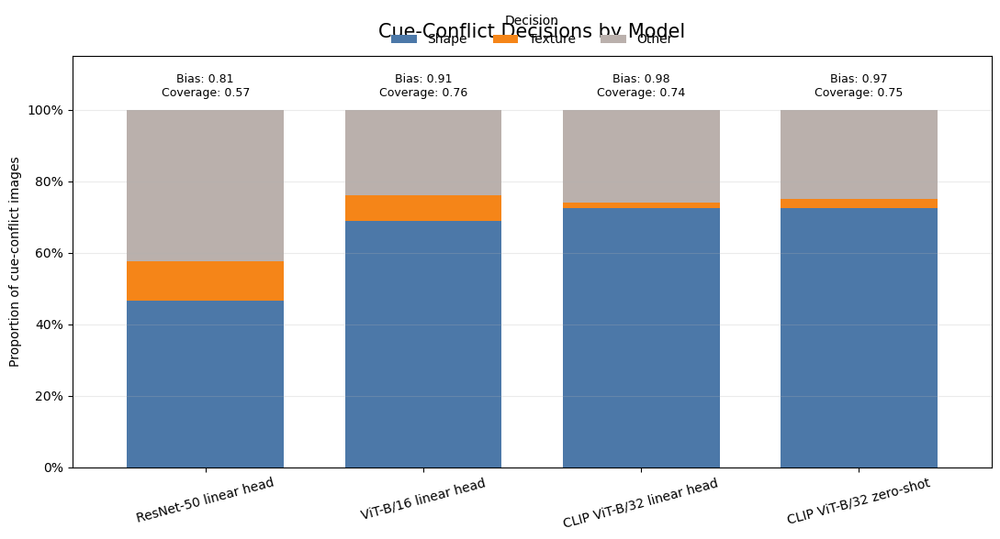

In [95]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

cue_plot_data = (
    cue_bias_results
    .set_index("model")[
        [
            "shape_rate",
            "texture_rate",
            "other_rate"
        ]
    ]
)

ax = cue_plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=[
        "#4C78A8",
        "#F58518",
        "#BAB0AC"
    ],
    width=0.72
)

ax.set_title(
    "Cue-Conflict Decisions by Model",
    fontsize=15,
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of cue-conflict images")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.legend(
    ["Shape", "Texture", "Other"],
    title="Decision",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    ncol=3,
    frameon=False
)

ax.tick_params(
    axis="x",
    rotation=15
)

for position, row in enumerate(
    cue_bias_results.itertuples()
):
    ax.text(
        position,
        1.03,
        (
            f"Bias: {row.shape_bias:.2f}\n"
            f"Coverage: {row.coverage:.2f}"
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "results/cue_conflicts/cue_conflict_decision_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

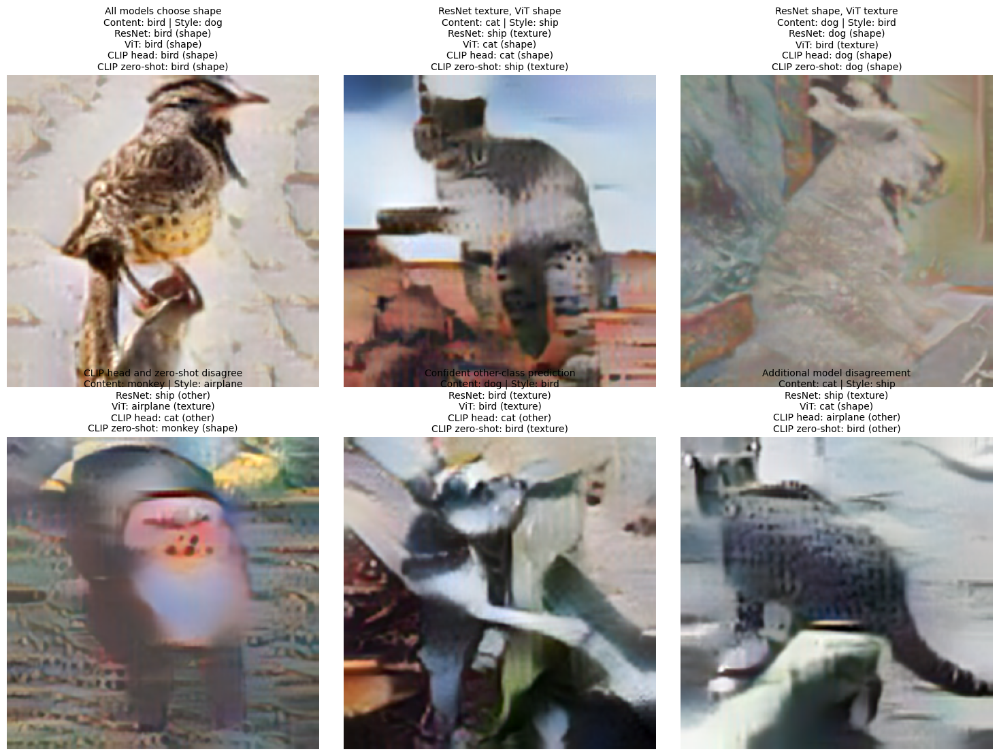

,example_type,content_class,style_class,resnet_decision,vit_decision,clip_head_decision,clip_zero_shot_decision
0,All models choose shape,bird,dog,shape,shape,shape,shape
1,"ResNet texture, ViT shape",cat,ship,texture,shape,shape,texture
2,"ResNet shape, ViT texture",dog,bird,shape,texture,shape,shape
3,CLIP head and zero-shot disagree,monkey,airplane,other,texture,other,shape
4,Confident other-class prediction,dog,bird,texture,texture,other,texture
5,Additional model disagreement,cat,ship,texture,shape,other,other


In [96]:
decision_columns = [
    "resnet_decision",
    "vit_decision",
    "clip_head_decision",
    "clip_zero_shot_decision"
]

confidence_columns = [
    "resnet_confidence",
    "vit_confidence",
    "clip_head_confidence",
    "clip_zero_shot_confidence"
]

example_candidates = cue_prediction_records.copy()

example_candidates["maximum_confidence"] = (
    example_candidates[confidence_columns]
    .max(axis=1)
)

example_candidates["decision_variety"] = (
    example_candidates[decision_columns]
    .nunique(axis=1)
)

all_shape_mask = (
    example_candidates[decision_columns]
    .eq("shape")
    .all(axis=1)
)

all_texture_mask = (
    example_candidates[decision_columns]
    .eq("texture")
    .all(axis=1)
)

resnet_texture_vit_shape_mask = (
    example_candidates["resnet_decision"].eq("texture")
    & example_candidates["vit_decision"].eq("shape")
)

resnet_shape_vit_texture_mask = (
    example_candidates["resnet_decision"].eq("shape")
    & example_candidates["vit_decision"].eq("texture")
)

clip_disagreement_mask = (
    example_candidates["clip_head_decision"]
    != example_candidates["clip_zero_shot_decision"]
)

confident_other_mask = (
    example_candidates[decision_columns]
    .eq("other")
    .any(axis=1)
)

selection_rules = [
    (
        "All models choose shape",
        all_shape_mask,
        "maximum_confidence",
        False
    ),
    (
        "All models choose texture",
        all_texture_mask,
        "maximum_confidence",
        False
    ),
    (
        "ResNet texture, ViT shape",
        resnet_texture_vit_shape_mask,
        "maximum_confidence",
        False
    ),
    (
        "ResNet shape, ViT texture",
        resnet_shape_vit_texture_mask,
        "maximum_confidence",
        False
    ),
    (
        "CLIP head and zero-shot disagree",
        clip_disagreement_mask,
        "decision_variety",
        False
    ),
    (
        "Confident other-class prediction",
        confident_other_mask,
        "maximum_confidence",
        False
    )
]

selected_example_rows = []
selected_conflict_ids = set()

for (
    example_type,
    selection_mask,
    sort_column,
    ascending
) in selection_rules:
    available_examples = (
        example_candidates[
            selection_mask
            & ~example_candidates["conflict_id"].isin(
                selected_conflict_ids
            )
        ]
        .sort_values(
            [sort_column, "conflict_id"],
            ascending=[ascending, True]
        )
    )

    if len(available_examples) > 0:
        selected_row = available_examples.iloc[0].copy()
        selected_row["example_type"] = example_type

        selected_example_rows.append(
            selected_row
        )

        selected_conflict_ids.add(
            selected_row["conflict_id"]
        )

informative_examples = pd.DataFrame(
    selected_example_rows
)

if len(informative_examples) < 6:
    additional_examples = (
        example_candidates[
            ~example_candidates["conflict_id"].isin(
                selected_conflict_ids
            )
        ]
        .sort_values(
            [
                "decision_variety",
                "maximum_confidence",
                "conflict_id"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .head(
            6 - len(informative_examples)
        )
        .copy()
    )

    additional_examples["example_type"] = (
        "Additional model disagreement"
    )

    informative_examples = pd.concat(
        [
            informative_examples,
            additional_examples
        ],
        ignore_index=True
    )

informative_examples.to_csv(
    "results/cue_conflicts/informative_cue_conflict_examples.csv",
    index=False
)

number_of_examples = len(
    informative_examples
)

number_of_columns = 3

number_of_rows = int(
    np.ceil(
        number_of_examples
        / number_of_columns
    )
)

figure, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        15,
        5.5 * number_of_rows
    )
)

axes = np.array(
    axes
).reshape(-1)

for axis, (_, row) in zip(
    axes,
    informative_examples.iterrows()
):
    image = Image.open(
        row[stylized_path_column]
    ).convert("RGB")

    axis.imshow(image)

    axis.set_title(
        (
            f"{row['example_type']}\n"
            f"Content: {row['content_class']} | "
            f"Style: {row['style_class']}\n"
            f"ResNet: {row['resnet_predicted_class']} "
            f"({row['resnet_decision']})\n"
            f"ViT: {row['vit_predicted_class']} "
            f"({row['vit_decision']})\n"
            f"CLIP head: {row['clip_head_predicted_class']} "
            f"({row['clip_head_decision']})\n"
            f"CLIP zero-shot: "
            f"{row['clip_zero_shot_predicted_class']} "
            f"({row['clip_zero_shot_decision']})"
        ),
        fontsize=10
    )

    axis.axis("off")

for axis in axes[number_of_examples:]:
    axis.axis("off")

plt.tight_layout()

plt.savefig(
    "results/cue_conflicts/informative_cue_conflict_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

informative_examples[
    [
        "example_type",
        "content_class",
        "style_class",
        "resnet_decision",
        "vit_decision",
        "clip_head_decision",
        "clip_zero_shot_decision"
    ]
]

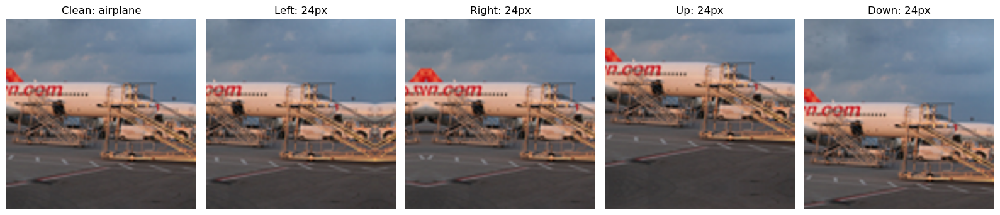

Clean batch: torch.Size([32, 3, 224, 224])
left torch.Size([32, 3, 224, 224])
right torch.Size([32, 3, 224, 224])
up torch.Size([32, 3, 224, 224])
down torch.Size([32, 3, 224, 224])


In [97]:
import torch.nn.functional as F

TRANSLATION_DIRECTIONS = [
    "left",
    "right",
    "up",
    "down"
]

def translate_batch(
    images,
    displacement,
    direction
):
    if displacement < 0:
        raise ValueError(
            "Displacement must be non-negative."
        )

    if direction not in TRANSLATION_DIRECTIONS:
        raise ValueError(
            f"Direction must be one of "
            f"{TRANSLATION_DIRECTIONS}."
        )

    if displacement == 0:
        return images.clone()

    height = images.shape[2]
    width = images.shape[3]

    padded_images = F.pad(
        images,
        pad=(
            displacement,
            displacement,
            displacement,
            displacement
        ),
        mode="reflect"
    )

    row_start = displacement
    column_start = displacement

    if direction == "left":
        column_start = (
            column_start
            + displacement
        )

    elif direction == "right":
        column_start = (
            column_start
            - displacement
        )

    elif direction == "up":
        row_start = (
            row_start
            + displacement
        )

    elif direction == "down":
        row_start = (
            row_start
            - displacement
        )

    translated_images = padded_images[
        :,
        :,
        row_start:row_start + height,
        column_start:column_start + width
    ]

    return translated_images

clean_images, clean_labels, clean_image_ids = next(
    iter(common_test_loader)
)

example_displacement = 24

translated_examples = {
    direction: translate_batch(
        clean_images,
        displacement=example_displacement,
        direction=direction
    )
    for direction in TRANSLATION_DIRECTIONS
}

figure, axes = plt.subplots(
    1,
    5,
    figsize=(16, 4)
)

axes[0].imshow(
    clean_images[0].permute(1, 2, 0)
)

axes[0].set_title(
    f"Clean: {class_names[clean_labels[0]]}"
)

axes[0].axis("off")

for axis, direction in zip(
    axes[1:],
    TRANSLATION_DIRECTIONS
):
    axis.imshow(
        translated_examples[direction][0]
        .permute(1, 2, 0)
    )

    axis.set_title(
        f"{direction.title()}: "
        f"{example_displacement}px"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

print("Clean batch:", clean_images.shape)

for direction in TRANSLATION_DIRECTIONS:
    print(
        direction,
        translated_examples[direction].shape
    )

In [98]:
TRANSLATION_DISPLACEMENTS = [
    0,
    4,
    8,
    16,
    24,
    32
]

def predict_translated_batch(
    images,
    displacement,
    direction
):
    if displacement == 0:
        transformed_images = images
    else:
        transformed_images = translate_batch(
            images,
            displacement=displacement,
            direction=direction
        )

    transformed_images = transformed_images.to(
        device
    )

    imagenet_images = normalize_image_batch(
        transformed_images,
        IMAGENET_MEAN,
        IMAGENET_STD
    )

    clip_images = normalize_image_batch(
        transformed_images,
        CLIP_MEAN,
        CLIP_STD
    )

    resnet_features = resnet(
        imagenet_images
    )

    vit_features = vit(
        imagenet_images
    )

    clip_features = clip.encode_image(
        clip_images
    )

    clip_features = (
        clip_features
        / clip_features.norm(
            dim=1,
            keepdim=True
        )
    )

    resnet_predictions = (
        resnet_head(resnet_features)
        .argmax(dim=1)
    )

    vit_predictions = (
        vit_head(vit_features)
        .argmax(dim=1)
    )

    clip_head_predictions = (
        clip_head(clip_features)
        .argmax(dim=1)
    )

    clip_zero_shot_predictions = (
        (
            clip_features
            @ clip_text_features.to(device).T
        )
        .argmax(dim=1)
    )

    return {
        "resnet": resnet_predictions.cpu(),
        "vit": vit_predictions.cpu(),
        "clip_head": clip_head_predictions.cpu(),
        "clip_zero_shot": (
            clip_zero_shot_predictions.cpu()
        )
    }

def evaluate_translation_condition(
    loader,
    displacement,
    direction
):
    prediction_batches = {
        "resnet": [],
        "vit": [],
        "clip_head": [],
        "clip_zero_shot": []
    }

    label_batches = []
    image_id_batches = []

    resnet.eval()
    vit.eval()
    clip.eval()

    resnet_head.eval()
    vit_head.eval()
    clip_head.eval()

    with torch.inference_mode():
        for (
            images,
            labels,
            image_ids
        ) in loader:
            batch_predictions = (
                predict_translated_batch(
                    images,
                    displacement,
                    direction
                )
            )

            for model_key in prediction_batches:
                prediction_batches[
                    model_key
                ].append(
                    batch_predictions[model_key]
                )

            label_batches.append(labels)
            image_id_batches.append(image_ids)

    predictions = {
        model_key: torch.cat(
            model_prediction_batches
        )
        for (
            model_key,
            model_prediction_batches
        ) in prediction_batches.items()
    }

    labels = torch.cat(
        label_batches
    )

    image_ids = torch.cat(
        image_id_batches
    )

    return predictions, labels, image_ids

clean_prediction_reference = {
    "resnet": resnet_clean_predictions,
    "vit": vit_clean_predictions,
    "clip_head": clip_clean_predictions,
    "clip_zero_shot": (
        clip_zero_shot_predictions
    )
}

model_display_names = {
    "resnet": "ResNet-50 linear head",
    "vit": "ViT-B/16 linear head",
    "clip_head": "CLIP ViT-B/32 linear head",
    "clip_zero_shot": "CLIP ViT-B/32 zero-shot"
}

translation_records = []

total_conditions = (
    1
    + (
        len(TRANSLATION_DISPLACEMENTS) - 1
    )
    * len(TRANSLATION_DIRECTIONS)
)

progress_bar = tqdm(
    total=total_conditions,
    desc="Translation conditions"
)

for displacement in TRANSLATION_DISPLACEMENTS:
    if displacement == 0:
        directions = ["none"]
    else:
        directions = TRANSLATION_DIRECTIONS

    for direction in directions:
        (
            translated_predictions,
            translated_labels,
            translated_image_ids
        ) = evaluate_translation_condition(
            common_test_loader,
            displacement,
            direction
        )

        if not torch.equal(
            translated_image_ids,
            resnet_clean_ids
        ):
            raise ValueError(
                "Translation image IDs are not aligned "
                "with the clean predictions."
            )

        if not torch.equal(
            translated_labels,
            resnet_clean_labels
        ):
            raise ValueError(
                "Translation labels are not aligned "
                "with the clean labels."
            )

        for model_key, predictions in (
            translated_predictions.items()
        ):
            accuracy = (
                predictions
                .eq(translated_labels)
                .float()
                .mean()
                .item()
            )

            consistency = (
                predictions
                .eq(
                    clean_prediction_reference[
                        model_key
                    ]
                )
                .float()
                .mean()
                .item()
            )

            translation_records.append({
                "model": model_display_names[
                    model_key
                ],
                "displacement": displacement,
                "direction": direction,
                "accuracy": accuracy,
                "prediction_consistency": (
                    consistency
                )
            })

        progress_bar.update(1)

progress_bar.close()

translation_direction_results = pd.DataFrame(
    translation_records
)

translation_results = (
    translation_direction_results
    .groupby(
        ["model", "displacement"],
        as_index=False
    )
    .agg(
        accuracy=(
            "accuracy",
            "mean"
        ),
        prediction_consistency=(
            "prediction_consistency",
            "mean"
        ),
        accuracy_direction_std=(
            "accuracy",
            "std"
        ),
        consistency_direction_std=(
            "prediction_consistency",
            "std"
        )
    )
)

translation_results[
    [
        "accuracy_direction_std",
        "consistency_direction_std"
    ]
] = translation_results[
    [
        "accuracy_direction_std",
        "consistency_direction_std"
    ]
].fillna(0)

translation_direction_results.to_csv(
    "results/translation_direction_results.csv",
    index=False
)

translation_results.to_csv(
    "results/translation_results.csv",
    index=False
)

translation_results

Translation conditions:   0%|          | 0/21 [00:00<?, ?it/s]

,model,displacement,accuracy,prediction_consistency,accuracy_direction_std,consistency_direction_std
0,CLIP ViT-B/32 linear head,0,0.9840,1.0000,0.000000,0.000000
1,CLIP ViT-B/32 linear head,4,0.9780,0.9860,0.004321,0.002309
2,CLIP ViT-B/32 linear head,8,0.9805,0.9845,0.003416,0.006608
3,CLIP ViT-B/32 linear head,16,0.9785,0.9790,0.003786,0.002582
4,CLIP ViT-B/32 linear head,24,0.9770,0.9800,0.008406,0.006325
5,CLIP ViT-B/32 linear head,32,0.9745,0.9815,0.006608,0.005508
6,CLIP ViT-B/32 zero-shot,0,0.9680,1.0000,0.000000,0.000000
7,CLIP ViT-B/32 zero-shot,4,0.9715,0.9820,0.004123,0.003266
8,CLIP ViT-B/32 zero-shot,8,0.9690,0.9810,0.002582,0.002582
9,CLIP ViT-B/32 zero-shot,16,0.9725,0.9795,0.003000,0.003416


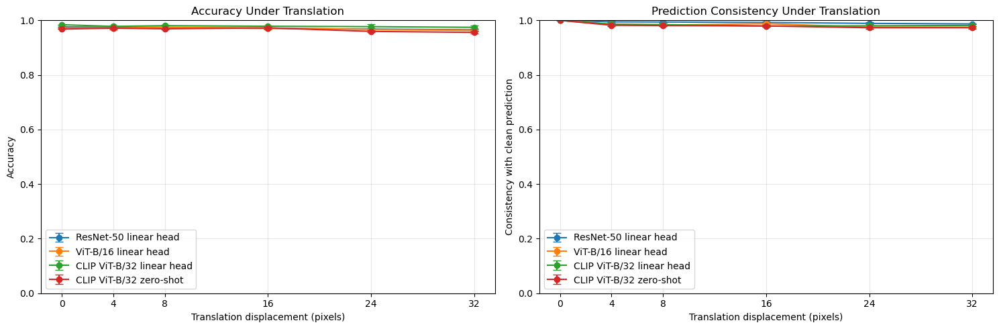

In [99]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

for model_name in model_display_names.values():
    model_results = (
        translation_results[
            translation_results["model"] == model_name
        ]
        .sort_values("displacement")
    )

    axes[0].errorbar(
        model_results["displacement"],
        model_results["accuracy"],
        yerr=model_results["accuracy_direction_std"],
        marker="o",
        capsize=4,
        label=model_name
    )

    axes[1].errorbar(
        model_results["displacement"],
        model_results["prediction_consistency"],
        yerr=model_results["consistency_direction_std"],
        marker="o",
        capsize=4,
        label=model_name
    )

axes[0].set_title("Accuracy Under Translation")
axes[0].set_xlabel("Translation displacement (pixels)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(TRANSLATION_DISPLACEMENTS)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

axes[1].set_title("Prediction Consistency Under Translation")
axes[1].set_xlabel("Translation displacement (pixels)")
axes[1].set_ylabel("Consistency with clean prediction")
axes[1].set_xticks(TRANSLATION_DISPLACEMENTS)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

axes[0].legend()
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "results/translation_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

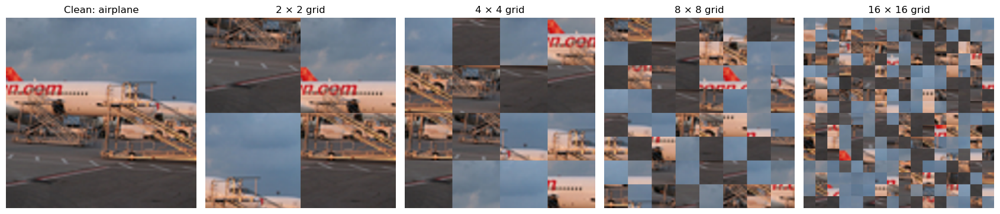

2 × 2: torch.Size([32, 3, 224, 224])
4 × 4: torch.Size([32, 3, 224, 224])
8 × 8: torch.Size([32, 3, 224, 224])
16 × 16: torch.Size([32, 3, 224, 224])


In [100]:
PATCH_GRID_SIZES = [
    1,
    2,
    4,
    8,
    16
]

def shuffle_image_patches(
    images,
    grid_size,
    seed=6304
):
    if images.ndim != 4:
        raise ValueError(
            "Images must have shape [batch, channels, height, width]."
        )

    batch_size, channels, height, width = images.shape

    if height % grid_size != 0 or width % grid_size != 0:
        raise ValueError(
            "The image dimensions must be divisible by the grid size."
        )

    patch_height = height // grid_size
    patch_width = width // grid_size
    number_of_patches = grid_size ** 2

    patches = (
        images
        .reshape(
            batch_size,
            channels,
            grid_size,
            patch_height,
            grid_size,
            patch_width
        )
        .permute(
            0,
            2,
            4,
            1,
            3,
            5
        )
        .reshape(
            batch_size,
            number_of_patches,
            channels,
            patch_height,
            patch_width
        )
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    shuffled_patch_batches = []

    for image_patches in patches:
        patch_order = torch.randperm(
            number_of_patches,
            generator=generator
        ).to(images.device)

        shuffled_patch_batches.append(
            image_patches[patch_order]
        )

    shuffled_patches = torch.stack(
        shuffled_patch_batches
    )

    shuffled_images = (
        shuffled_patches
        .reshape(
            batch_size,
            grid_size,
            grid_size,
            channels,
            patch_height,
            patch_width
        )
        .permute(
            0,
            3,
            1,
            4,
            2,
            5
        )
        .reshape(
            batch_size,
            channels,
            height,
            width
        )
    )

    return shuffled_images

patch_shuffle_examples = {
    grid_size: shuffle_image_patches(
        clean_images,
        grid_size=grid_size,
        seed=6304
    )
    for grid_size in PATCH_GRID_SIZES[1:]
}

figure, axes = plt.subplots(
    1,
    len(PATCH_GRID_SIZES),
    figsize=(17, 4)
)

axes[0].imshow(
    clean_images[0].permute(1, 2, 0)
)

axes[0].set_title(
    f"Clean: {class_names[clean_labels[0]]}"
)

axes[0].axis("off")

for axis, grid_size in zip(
    axes[1:],
    PATCH_GRID_SIZES[1:]
):
    axis.imshow(
        patch_shuffle_examples[grid_size][0]
        .permute(1, 2, 0)
    )

    axis.set_title(
        f"{grid_size} × {grid_size} grid"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

for grid_size in PATCH_GRID_SIZES[1:]:
    print(
        f"{grid_size} × {grid_size}:",
        patch_shuffle_examples[grid_size].shape
    )

In [101]:
def predict_patch_shuffled_batch(
    images,
    grid_size,
    seed
):
    if grid_size == 1:
        transformed_images = images
    else:
        transformed_images = shuffle_image_patches(
            images,
            grid_size=grid_size,
            seed=seed
        )

    transformed_images = transformed_images.to(
        device
    )

    imagenet_images = normalize_image_batch(
        transformed_images,
        IMAGENET_MEAN,
        IMAGENET_STD
    )

    clip_images = normalize_image_batch(
        transformed_images,
        CLIP_MEAN,
        CLIP_STD
    )

    resnet_features = resnet(
        imagenet_images
    )

    vit_features = vit(
        imagenet_images
    )

    clip_features = clip.encode_image(
        clip_images
    )

    clip_features = (
        clip_features
        / clip_features.norm(
            dim=1,
            keepdim=True
        )
    )

    resnet_predictions = (
        resnet_head(resnet_features)
        .argmax(dim=1)
    )

    vit_predictions = (
        vit_head(vit_features)
        .argmax(dim=1)
    )

    clip_head_predictions = (
        clip_head(clip_features)
        .argmax(dim=1)
    )

    clip_zero_shot_predictions = (
        (
            clip_features
            @ clip_text_features.to(device).T
        )
        .argmax(dim=1)
    )

    return {
        "resnet": resnet_predictions.cpu(),
        "vit": vit_predictions.cpu(),
        "clip_head": clip_head_predictions.cpu(),
        "clip_zero_shot": (
            clip_zero_shot_predictions.cpu()
        )
    }


def evaluate_patch_shuffle_condition(
    loader,
    grid_size
):
    prediction_batches = {
        "resnet": [],
        "vit": [],
        "clip_head": [],
        "clip_zero_shot": []
    }

    label_batches = []
    image_id_batches = []

    resnet.eval()
    vit.eval()
    clip.eval()

    resnet_head.eval()
    vit_head.eval()
    clip_head.eval()

    with torch.inference_mode():
        for batch_number, (
            images,
            labels,
            image_ids
        ) in enumerate(loader):
            batch_seed = (
                6304
                + grid_size * 1000
                + batch_number
            )

            batch_predictions = (
                predict_patch_shuffled_batch(
                    images,
                    grid_size,
                    batch_seed
                )
            )

            for model_key in prediction_batches:
                prediction_batches[
                    model_key
                ].append(
                    batch_predictions[
                        model_key
                    ]
                )

            label_batches.append(
                labels
            )

            image_id_batches.append(
                image_ids
            )

    predictions = {
        model_key: torch.cat(
            model_prediction_batches
        )
        for (
            model_key,
            model_prediction_batches
        ) in prediction_batches.items()
    }

    labels = torch.cat(
        label_batches
    )

    image_ids = torch.cat(
        image_id_batches
    )

    return predictions, labels, image_ids


input_image_size = clean_images.shape[-1]

patch_shuffle_records = []

progress_bar = tqdm(
    PATCH_GRID_SIZES,
    desc="Patch-shuffle conditions"
)

for grid_size in progress_bar:
    (
        shuffled_predictions,
        shuffled_labels,
        shuffled_image_ids
    ) = evaluate_patch_shuffle_condition(
        common_test_loader,
        grid_size
    )

    if not torch.equal(
        shuffled_image_ids,
        resnet_clean_ids
    ):
        raise ValueError(
            "Patch-shuffle image IDs are not aligned "
            "with the clean predictions."
        )

    if not torch.equal(
        shuffled_labels,
        resnet_clean_labels
    ):
        raise ValueError(
            "Patch-shuffle labels are not aligned "
            "with the clean labels."
        )

    patch_size = (
        input_image_size
        // grid_size
    )

    for model_key, predictions in (
        shuffled_predictions.items()
    ):
        accuracy = (
            predictions
            .eq(shuffled_labels)
            .float()
            .mean()
            .item()
        )

        consistency = (
            predictions
            .eq(
                clean_prediction_reference[
                    model_key
                ]
            )
            .float()
            .mean()
            .item()
        )

        patch_shuffle_records.append({
            "model": model_display_names[
                model_key
            ],
            "grid_size": grid_size,
            "number_of_patches": (
                grid_size ** 2
            ),
            "patch_size": patch_size,
            "accuracy": accuracy,
            "prediction_consistency": (
                consistency
            )
        })

patch_shuffle_results = pd.DataFrame(
    patch_shuffle_records
)

patch_shuffle_results.to_csv(
    "results/patch_shuffle_results.csv",
    index=False
)

patch_shuffle_results

Patch-shuffle conditions:   0%|          | 0/5 [00:00<?, ?it/s]

,model,grid_size,number_of_patches,patch_size,accuracy,prediction_consistency
0,ResNet-50 linear head,1,1,224,0.976,1.000
1,ViT-B/16 linear head,1,1,224,0.972,1.000
2,CLIP ViT-B/32 linear head,1,1,224,0.984,1.000
3,CLIP ViT-B/32 zero-shot,1,1,224,0.968,1.000
4,ResNet-50 linear head,2,4,112,0.958,0.968
5,ViT-B/16 linear head,2,4,112,0.956,0.966
6,CLIP ViT-B/32 linear head,2,4,112,0.954,0.970
7,CLIP ViT-B/32 zero-shot,2,4,112,0.930,0.950
8,ResNet-50 linear head,4,16,56,0.898,0.916
9,ViT-B/16 linear head,4,16,56,0.910,0.922


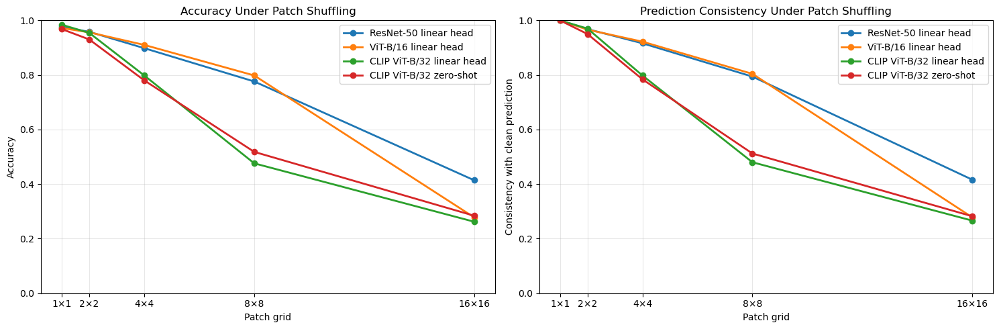

In [102]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

for model_name in model_display_names.values():
    model_results = (
        patch_shuffle_results[
            patch_shuffle_results["model"]
            == model_name
        ]
        .sort_values("grid_size")
    )

    axes[0].plot(
        model_results["grid_size"],
        model_results["accuracy"],
        marker="o",
        linewidth=2,
        label=model_name
    )

    axes[1].plot(
        model_results["grid_size"],
        model_results[
            "prediction_consistency"
        ],
        marker="o",
        linewidth=2,
        label=model_name
    )

grid_labels = [
    f"{grid_size}×{grid_size}"
    for grid_size in PATCH_GRID_SIZES
]

axes[0].set_title(
    "Accuracy Under Patch Shuffling"
)

axes[0].set_xlabel(
    "Patch grid"
)

axes[0].set_ylabel(
    "Accuracy"
)

axes[0].set_xticks(
    PATCH_GRID_SIZES,
    grid_labels
)

axes[0].set_ylim(
    0,
    1
)

axes[0].grid(
    alpha=0.3
)

axes[1].set_title(
    "Prediction Consistency Under Patch Shuffling"
)

axes[1].set_xlabel(
    "Patch grid"
)

axes[1].set_ylabel(
    "Consistency with clean prediction"
)

axes[1].set_xticks(
    PATCH_GRID_SIZES,
    grid_labels
)

axes[1].set_ylim(
    0,
    1
)

axes[1].grid(
    alpha=0.3
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "results/patch_shuffle_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
def paired_cosine_similarity(
    clean_features,
    transformed_features
):
    if clean_features.shape != transformed_features.shape:
        raise ValueError(
            "Clean and transformed features must have the same shape."
        )

    clean_features = F.normalize(
        clean_features.float(),
        dim=1
    )

    transformed_features = F.normalize(
        transformed_features.float(),
        dim=1
    )

    similarities = (
        clean_features
        * transformed_features
    ).sum(dim=1)

    return similarities


clean_similarity_check = pd.DataFrame([
    {
        "model": "ResNet-50",
        "number_of_images": len(
            resnet_clean_features
        ),
        "mean_self_similarity": (
            paired_cosine_similarity(
                resnet_clean_features,
                resnet_clean_features
            )
            .mean()
            .item()
        )
    },
    {
        "model": "ViT-B/16",
        "number_of_images": len(
            vit_clean_features
        ),
        "mean_self_similarity": (
            paired_cosine_similarity(
                vit_clean_features,
                vit_clean_features
            )
            .mean()
            .item()
        )
    },
    {
        "model": "CLIP ViT-B/32",
        "number_of_images": len(
            clip_clean_features
        ),
        "mean_self_similarity": (
            paired_cosine_similarity(
                clip_clean_features,
                clip_clean_features
            )
            .mean()
            .item()
        )
    }
])

clean_similarity_check

,model,number_of_images,mean_self_similarity
0,ResNet-50,500,1.0
1,ViT-B/16,500,1.0
2,CLIP ViT-B/32,500,1.0


In [104]:
def summarize_feature_similarity(
    clean_features,
    transformed_features,
    model_name,
    intervention,
    condition
):
    similarities = paired_cosine_similarity(
        clean_features,
        transformed_features
    )

    return {
        "model": model_name,
        "intervention": intervention,
        "condition": condition,
        "number_of_images": len(similarities),
        "mean_cosine_similarity": (
            similarities.mean().item()
        ),
        "std_cosine_similarity": (
            similarities.std().item()
        ),
        "median_cosine_similarity": (
            similarities.median().item()
        ),
        "minimum_cosine_similarity": (
            similarities.min().item()
        ),
        "maximum_cosine_similarity": (
            similarities.max().item()
        )
    }


color_feature_similarity_results = pd.DataFrame([
    summarize_feature_similarity(
        resnet_clean_features,
        resnet_clean_features,
        "ResNet-50",
        "clean",
        "clean"
    ),
    summarize_feature_similarity(
        vit_clean_features,
        vit_clean_features,
        "ViT-B/16",
        "clean",
        "clean"
    ),
    summarize_feature_similarity(
        clip_clean_features,
        clip_clean_features,
        "CLIP ViT-B/32",
        "clean",
        "clean"
    ),
    summarize_feature_similarity(
        resnet_clean_features,
        resnet_grayscale_features,
        "ResNet-50",
        "grayscale",
        "color removed"
    ),
    summarize_feature_similarity(
        vit_clean_features,
        vit_grayscale_features,
        "ViT-B/16",
        "grayscale",
        "color removed"
    ),
    summarize_feature_similarity(
        clip_clean_features,
        clip_grayscale_features,
        "CLIP ViT-B/32",
        "grayscale",
        "color removed"
    ),
    summarize_feature_similarity(
        resnet_clean_features,
        resnet_hue_features,
        "ResNet-50",
        "hue rotation",
        "hue factor 0.25"
    ),
    summarize_feature_similarity(
        vit_clean_features,
        vit_hue_features,
        "ViT-B/16",
        "hue rotation",
        "hue factor 0.25"
    ),
    summarize_feature_similarity(
        clip_clean_features,
        clip_hue_features,
        "CLIP ViT-B/32",
        "hue rotation",
        "hue factor 0.25"
    )
])

color_feature_similarity_results.to_csv(
    "results/color_feature_similarity.csv",
    index=False
)

color_feature_similarity_results

,model,intervention,condition,number_of_images,mean_cosine_similarity,std_cosine_similarity,median_cosine_similarity,minimum_cosine_similarity,maximum_cosine_similarity
0,ResNet-50,clean,clean,500,1.000000,1.147977e-07,1.000000,1.000000,1.000000
1,ViT-B/16,clean,clean,500,1.000000,1.007957e-07,1.000000,1.000000,1.000000
2,CLIP ViT-B/32,clean,clean,500,1.000000,1.195075e-07,1.000000,1.000000,1.000000
3,ResNet-50,grayscale,color removed,500,0.789124,9.753264e-02,0.798561,0.299744,0.999999
4,ViT-B/16,grayscale,color removed,500,0.739242,1.261604e-01,0.754391,0.167296,1.000000
5,CLIP ViT-B/32,grayscale,color removed,500,0.895122,4.009977e-02,0.900133,0.727430,1.000000
6,ResNet-50,hue rotation,hue factor 0.25,500,0.758819,1.148782e-01,0.778015,0.332241,0.999998
7,ViT-B/16,hue rotation,hue factor 0.25,500,0.717143,1.395372e-01,0.740992,0.167019,1.000000
8,CLIP ViT-B/32,hue rotation,hue factor 0.25,500,0.891778,4.815420e-02,0.897643,0.623843,1.000000


In [105]:
def extract_backbone_feature_batch(
    images
):
    images = images.to(
        device
    )

    imagenet_images = normalize_image_batch(
        images,
        IMAGENET_MEAN,
        IMAGENET_STD
    )

    clip_images = normalize_image_batch(
        images,
        CLIP_MEAN,
        CLIP_STD
    )

    resnet_features = resnet(
        imagenet_images
    )

    vit_features = vit(
        imagenet_images
    )

    clip_features = clip.encode_image(
        clip_images
    )

    clip_features = (
        clip_features
        / clip_features.norm(
            dim=1,
            keepdim=True
        )
    )

    return {
        "resnet": resnet_features.cpu(),
        "vit": vit_features.cpu(),
        "clip": clip_features.cpu()
    }


def collect_translation_features(
    loader,
    displacement,
    direction
):
    feature_batches = {
        "resnet": [],
        "vit": [],
        "clip": []
    }

    label_batches = []
    image_id_batches = []

    resnet.eval()
    vit.eval()
    clip.eval()

    with torch.inference_mode():
        for images, labels, image_ids in loader:
            if displacement == 0:
                transformed_images = images
            else:
                transformed_images = translate_batch(
                    images,
                    displacement=displacement,
                    direction=direction
                )

            batch_features = (
                extract_backbone_feature_batch(
                    transformed_images
                )
            )

            for model_key in feature_batches:
                feature_batches[
                    model_key
                ].append(
                    batch_features[
                        model_key
                    ]
                )

            label_batches.append(
                labels
            )

            image_id_batches.append(
                image_ids
            )

    features = {
        model_key: torch.cat(
            model_feature_batches
        )
        for (
            model_key,
            model_feature_batches
        ) in feature_batches.items()
    }

    labels = torch.cat(
        label_batches
    )

    image_ids = torch.cat(
        image_id_batches
    )

    return features, labels, image_ids


clean_backbone_features = {
    "resnet": resnet_clean_features,
    "vit": vit_clean_features,
    "clip": clip_clean_features
}

backbone_display_names = {
    "resnet": "ResNet-50",
    "vit": "ViT-B/16",
    "clip": "CLIP ViT-B/32"
}

translation_feature_records = []

total_translation_conditions = (
    1
    + (
        len(TRANSLATION_DISPLACEMENTS) - 1
    )
    * len(TRANSLATION_DIRECTIONS)
)

progress_bar = tqdm(
    total=total_translation_conditions,
    desc="Translation feature similarity"
)

for displacement in TRANSLATION_DISPLACEMENTS:
    if displacement == 0:
        directions = ["none"]
    else:
        directions = TRANSLATION_DIRECTIONS

    for direction in directions:
        (
            translated_features,
            translated_labels,
            translated_image_ids
        ) = collect_translation_features(
            common_test_loader,
            displacement,
            direction
        )

        if not torch.equal(
            translated_image_ids,
            resnet_clean_ids
        ):
            raise ValueError(
                "Translation feature IDs are not aligned "
                "with clean features."
            )

        if not torch.equal(
            translated_labels,
            resnet_clean_labels
        ):
            raise ValueError(
                "Translation feature labels are not aligned "
                "with clean labels."
            )

        for model_key, model_features in (
            translated_features.items()
        ):
            result = summarize_feature_similarity(
                clean_backbone_features[
                    model_key
                ],
                model_features,
                backbone_display_names[
                    model_key
                ],
                "translation",
                (
                    f"{displacement}px "
                    f"{direction}"
                )
            )

            result["displacement"] = (
                displacement
            )

            result["direction"] = (
                direction
            )

            translation_feature_records.append(
                result
            )

        progress_bar.update(1)

progress_bar.close()

translation_direction_feature_similarity = (
    pd.DataFrame(
        translation_feature_records
    )
)

translation_feature_similarity = (
    translation_direction_feature_similarity
    .groupby(
        ["model", "displacement"],
        as_index=False
    )
    .agg(
        mean_cosine_similarity=(
            "mean_cosine_similarity",
            "mean"
        ),
        direction_std=(
            "mean_cosine_similarity",
            "std"
        ),
        mean_image_std=(
            "std_cosine_similarity",
            "mean"
        )
    )
)

translation_feature_similarity[
    "direction_std"
] = (
    translation_feature_similarity[
        "direction_std"
    ]
    .fillna(0)
)

translation_direction_feature_similarity.to_csv(
    "results/translation_direction_feature_similarity.csv",
    index=False
)

translation_feature_similarity.to_csv(
    "results/translation_feature_similarity.csv",
    index=False
)

translation_feature_similarity

Translation feature similarity:   0%|          | 0/21 [00:00<?, ?it/s]

,model,displacement,mean_cosine_similarity,direction_std,mean_image_std
0,CLIP ViT-B/32,0,1.000000,0.000000,1.195075e-07
1,CLIP ViT-B/32,4,0.989141,0.000531,6.352798e-03
2,CLIP ViT-B/32,8,0.981072,0.000225,1.005976e-02
3,CLIP ViT-B/32,16,0.968016,0.002947,1.677279e-02
4,CLIP ViT-B/32,24,0.968105,0.003086,1.749189e-02
5,CLIP ViT-B/32,32,0.969093,0.007368,1.992323e-02
6,ResNet-50,0,1.000000,0.000000,1.147977e-07
7,ResNet-50,4,0.979771,0.001652,1.013610e-02
8,ResNet-50,8,0.968531,0.003905,1.715867e-02
9,ResNet-50,16,0.952493,0.007385,2.811349e-02


In [106]:
def summarize_feature_similarity(
    clean_features,
    transformed_features,
    model_name,
    intervention,
    condition
):
    similarities = paired_cosine_similarity(
        clean_features,
        transformed_features
    )

    return {
        "model": model_name,
        "intervention": intervention,
        "condition": condition,
        "number_of_images": len(similarities),
        "mean_cosine_similarity": (
            similarities.mean().item()
        ),
        "std_cosine_similarity": (
            similarities.std().item()
        ),
        "median_cosine_similarity": (
            similarities.median().item()
        ),
        "minimum_cosine_similarity": (
            similarities.min().item()
        ),
        "maximum_cosine_similarity": (
            similarities.max().item()
        )
    }


color_feature_similarity_results = pd.DataFrame([
    summarize_feature_similarity(
        resnet_clean_features,
        resnet_clean_features,
        "ResNet-50",
        "clean",
        "clean"
    ),
    summarize_feature_similarity(
        vit_clean_features,
        vit_clean_features,
        "ViT-B/16",
        "clean",
        "clean"
    ),
    summarize_feature_similarity(
        clip_clean_features,
        clip_clean_features,
        "CLIP ViT-B/32",
        "clean",
        "clean"
    ),
    summarize_feature_similarity(
        resnet_clean_features,
        resnet_grayscale_features,
        "ResNet-50",
        "grayscale",
        "color removed"
    ),
    summarize_feature_similarity(
        vit_clean_features,
        vit_grayscale_features,
        "ViT-B/16",
        "grayscale",
        "color removed"
    ),
    summarize_feature_similarity(
        clip_clean_features,
        clip_grayscale_features,
        "CLIP ViT-B/32",
        "grayscale",
        "color removed"
    ),
    summarize_feature_similarity(
        resnet_clean_features,
        resnet_hue_features,
        "ResNet-50",
        "hue rotation",
        "hue factor 0.25"
    ),
    summarize_feature_similarity(
        vit_clean_features,
        vit_hue_features,
        "ViT-B/16",
        "hue rotation",
        "hue factor 0.25"
    ),
    summarize_feature_similarity(
        clip_clean_features,
        clip_hue_features,
        "CLIP ViT-B/32",
        "hue rotation",
        "hue factor 0.25"
    )
])

color_feature_similarity_results.to_csv(
    "results/color_feature_similarity.csv",
    index=False
)

color_feature_similarity_results

,model,intervention,condition,number_of_images,mean_cosine_similarity,std_cosine_similarity,median_cosine_similarity,minimum_cosine_similarity,maximum_cosine_similarity
0,ResNet-50,clean,clean,500,1.000000,1.147977e-07,1.000000,1.000000,1.000000
1,ViT-B/16,clean,clean,500,1.000000,1.007957e-07,1.000000,1.000000,1.000000
2,CLIP ViT-B/32,clean,clean,500,1.000000,1.195075e-07,1.000000,1.000000,1.000000
3,ResNet-50,grayscale,color removed,500,0.789124,9.753264e-02,0.798561,0.299744,0.999999
4,ViT-B/16,grayscale,color removed,500,0.739242,1.261604e-01,0.754391,0.167296,1.000000
5,CLIP ViT-B/32,grayscale,color removed,500,0.895122,4.009977e-02,0.900133,0.727430,1.000000
6,ResNet-50,hue rotation,hue factor 0.25,500,0.758819,1.148782e-01,0.778015,0.332241,0.999998
7,ViT-B/16,hue rotation,hue factor 0.25,500,0.717143,1.395372e-01,0.740992,0.167019,1.000000
8,CLIP ViT-B/32,hue rotation,hue factor 0.25,500,0.891778,4.815420e-02,0.897643,0.623843,1.000000


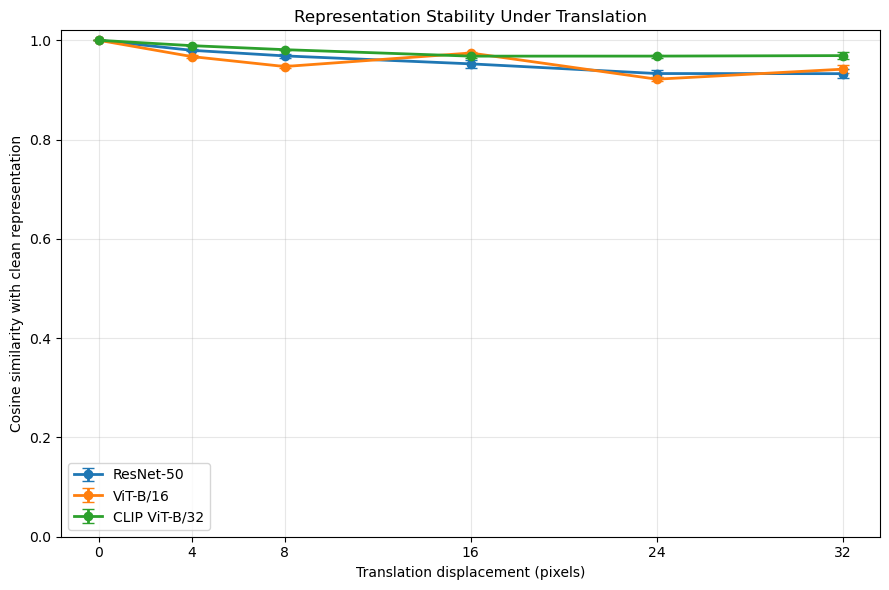

In [107]:
figure, axis = plt.subplots(
    figsize=(9, 6)
)

for model_name in backbone_display_names.values():
    model_results = (
        translation_feature_similarity[
            translation_feature_similarity[
                "model"
            ] == model_name
        ]
        .sort_values("displacement")
    )

    axis.errorbar(
        model_results["displacement"],
        model_results[
            "mean_cosine_similarity"
        ],
        yerr=model_results[
            "direction_std"
        ],
        marker="o",
        linewidth=2,
        capsize=4,
        label=model_name
    )

axis.set_title(
    "Representation Stability Under Translation"
)

axis.set_xlabel(
    "Translation displacement (pixels)"
)

axis.set_ylabel(
    "Cosine similarity with clean representation"
)

axis.set_xticks(
    TRANSLATION_DISPLACEMENTS
)

axis.set_ylim(
    0,
    1.02
)

axis.grid(
    alpha=0.3
)

axis.legend()

plt.tight_layout()

plt.savefig(
    "results/translation_feature_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
def collect_patch_shuffle_features(
    loader,
    grid_size
):
    feature_batches = {
        "resnet": [],
        "vit": [],
        "clip": []
    }

    label_batches = []
    image_id_batches = []

    resnet.eval()
    vit.eval()
    clip.eval()

    with torch.inference_mode():
        for batch_number, (
            images,
            labels,
            image_ids
        ) in enumerate(loader):
            if grid_size == 1:
                transformed_images = images
            else:
                batch_seed = (
                    6304
                    + grid_size * 1000
                    + batch_number
                )

                transformed_images = (
                    shuffle_image_patches(
                        images,
                        grid_size=grid_size,
                        seed=batch_seed
                    )
                )

            batch_features = (
                extract_backbone_feature_batch(
                    transformed_images
                )
            )

            for model_key in feature_batches:
                feature_batches[
                    model_key
                ].append(
                    batch_features[
                        model_key
                    ]
                )

            label_batches.append(
                labels
            )

            image_id_batches.append(
                image_ids
            )

    features = {
        model_key: torch.cat(
            model_feature_batches
        )
        for (
            model_key,
            model_feature_batches
        ) in feature_batches.items()
    }

    labels = torch.cat(
        label_batches
    )

    image_ids = torch.cat(
        image_id_batches
    )

    return features, labels, image_ids


patch_feature_records = []

progress_bar = tqdm(
    PATCH_GRID_SIZES,
    desc="Patch-shuffle feature similarity"
)

for grid_size in progress_bar:
    (
        patch_features,
        patch_labels,
        patch_image_ids
    ) = collect_patch_shuffle_features(
        common_test_loader,
        grid_size
    )

    if not torch.equal(
        patch_image_ids,
        resnet_clean_ids
    ):
        raise ValueError(
            "Patch-shuffle feature IDs are not aligned "
            "with clean features."
        )

    if not torch.equal(
        patch_labels,
        resnet_clean_labels
    ):
        raise ValueError(
            "Patch-shuffle feature labels are not aligned "
            "with clean labels."
        )

    patch_size = (
        input_image_size
        // grid_size
    )

    for model_key, model_features in (
        patch_features.items()
    ):
        result = summarize_feature_similarity(
            clean_backbone_features[
                model_key
            ],
            model_features,
            backbone_display_names[
                model_key
            ],
            "patch shuffle",
            f"{grid_size}×{grid_size} grid"
        )

        result["grid_size"] = (
            grid_size
        )

        result["number_of_patches"] = (
            grid_size ** 2
        )

        result["patch_size"] = (
            patch_size
        )

        patch_feature_records.append(
            result
        )

patch_feature_similarity = pd.DataFrame(
    patch_feature_records
)

patch_feature_similarity.to_csv(
    "results/patch_shuffle_feature_similarity.csv",
    index=False
)

patch_feature_similarity

Patch-shuffle feature similarity:   0%|          | 0/5 [00:00<?, ?it/s]

,model,intervention,condition,number_of_images,mean_cosine_similarity,std_cosine_similarity,median_cosine_similarity,minimum_cosine_similarity,maximum_cosine_similarity,grid_size,number_of_patches,patch_size
0,ResNet-50,patch shuffle,1×1 grid,500,1.000000,1.147977e-07,1.000000,1.000000,1.000000,1,1,224
1,ViT-B/16,patch shuffle,1×1 grid,500,1.000000,1.007957e-07,1.000000,1.000000,1.000000,1,1,224
2,CLIP ViT-B/32,patch shuffle,1×1 grid,500,1.000000,1.195075e-07,1.000000,1.000000,1.000000,1,1,224
3,ResNet-50,patch shuffle,2×2 grid,500,0.868337,5.537164e-02,0.868305,0.661794,1.000000,2,4,112
4,ViT-B/16,patch shuffle,2×2 grid,500,0.858083,9.451966e-02,0.871276,0.520159,1.000000,2,4,112
5,CLIP ViT-B/32,patch shuffle,2×2 grid,500,0.865947,5.843905e-02,0.871050,0.653965,1.000000,2,4,112
6,ResNet-50,patch shuffle,4×4 grid,500,0.712298,7.374406e-02,0.714910,0.394198,0.886326,4,16,56
7,ViT-B/16,patch shuffle,4×4 grid,500,0.650251,1.155496e-01,0.651832,0.204348,0.919675,4,16,56
8,CLIP ViT-B/32,patch shuffle,4×4 grid,500,0.735339,5.700170e-02,0.739600,0.565757,0.869525,4,16,56
9,ResNet-50,patch shuffle,8×8 grid,500,0.550772,1.022110e-01,0.546281,0.260772,0.833500,8,64,28


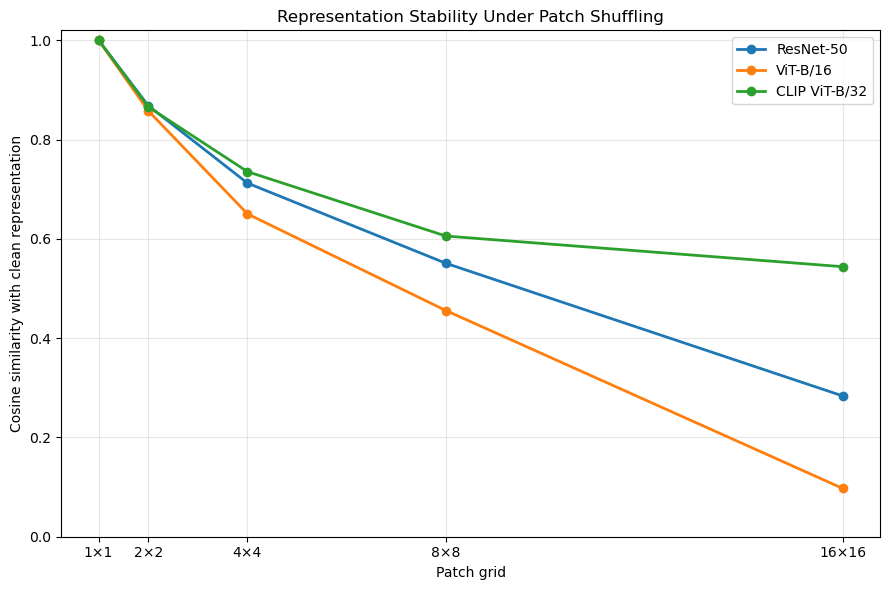

In [109]:
figure, axis = plt.subplots(
    figsize=(9, 6)
)

for model_name in backbone_display_names.values():
    model_results = (
        patch_feature_similarity[
            patch_feature_similarity[
                "model"
            ] == model_name
        ]
        .sort_values("grid_size")
    )

    axis.plot(
        model_results["grid_size"],
        model_results[
            "mean_cosine_similarity"
        ],
        marker="o",
        linewidth=2,
        label=model_name
    )

grid_labels = [
    f"{grid_size}×{grid_size}"
    for grid_size in PATCH_GRID_SIZES
]

axis.set_title(
    "Representation Stability Under Patch Shuffling"
)

axis.set_xlabel(
    "Patch grid"
)

axis.set_ylabel(
    "Cosine similarity with clean representation"
)

axis.set_xticks(
    PATCH_GRID_SIZES,
    grid_labels
)

axis.set_ylim(
    0,
    1.02
)

axis.grid(
    alpha=0.3
)

axis.legend()

plt.tight_layout()

plt.savefig(
    "results/patch_shuffle_feature_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
class CueConflictTripletDataset(Dataset):
    def __init__(
        self,
        manifest,
        base_dataset,
        stylized_path_column,
        class_to_index
    ):
        self.manifest = (
            manifest
            .reset_index(drop=True)
            .copy()
        )

        self.base_dataset = (
            base_dataset
        )

        self.stylized_path_column = (
            stylized_path_column
        )

        self.class_to_index = (
            class_to_index
        )

    def __len__(self):
        return len(
            self.manifest
        )

    def __getitem__(
        self,
        index
    ):
        row = self.manifest.iloc[
            index
        ]

        content_id = int(
            row["content_id"]
        )

        style_id = int(
            row["style_id"]
        )

        (
            content_image,
            content_dataset_label
        ) = self.base_dataset[
            content_id
        ]

        (
            style_image,
            style_dataset_label
        ) = self.base_dataset[
            style_id
        ]

        content_label = self.class_to_index[
            row["content_class"]
        ]

        style_label = self.class_to_index[
            row["style_class"]
        ]

        if int(
            content_dataset_label
        ) != content_label:
            raise ValueError(
                "Content image label does not match "
                "the cue-conflict manifest."
            )

        if int(
            style_dataset_label
        ) != style_label:
            raise ValueError(
                "Style image label does not match "
                "the cue-conflict manifest."
            )

        content_image = TF.to_tensor(
            common_transform(
                content_image
            )
        )

        style_image = TF.to_tensor(
            common_transform(
                style_image
            )
        )

        stylized_image = TF.to_tensor(
            Image.open(
                row[
                    self.stylized_path_column
                ]
            ).convert("RGB")
        )

        cue_conflict_id = int(
            row["cue_conflict_index"]
        )

        return (
            content_image,
            style_image,
            stylized_image,
            content_label,
            style_label,
            cue_conflict_id
        )


cue_triplet_dataset = (
    CueConflictTripletDataset(
        manifest=final_cue_conflicts,
        base_dataset=test_dataset,
        stylized_path_column=(
            stylized_path_column
        ),
        class_to_index=class_to_index
    )
)

cue_triplet_loader = DataLoader(
    cue_triplet_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

(
    content_images,
    style_images,
    stylized_images,
    content_labels,
    style_labels,
    cue_conflict_ids
) = next(
    iter(cue_triplet_loader)
)

print(
    "Content images:",
    content_images.shape
)

print(
    "Style images:",
    style_images.shape
)

print(
    "Stylized images:",
    stylized_images.shape
)

print(
    "Content labels:",
    content_labels.shape
)

print(
    "Style labels:",
    style_labels.shape
)

print(
    "Cue-conflict IDs:",
    cue_conflict_ids.shape
)

Content images: torch.Size([32, 3, 224, 224])
Style images: torch.Size([32, 3, 224, 224])
Stylized images: torch.Size([32, 3, 224, 224])
Content labels: torch.Size([32])
Style labels: torch.Size([32])
Cue-conflict IDs: torch.Size([32])


In [111]:
def collect_cue_reference_features(
    loader
):
    content_feature_batches = {
        "resnet": [],
        "vit": [],
        "clip": []
    }

    style_feature_batches = {
        "resnet": [],
        "vit": [],
        "clip": []
    }

    image_id_batches = []

    resnet.eval()
    vit.eval()
    clip.eval()

    with torch.inference_mode():
        for (
            content_images,
            style_images,
            stylized_images,
            content_labels,
            style_labels,
            image_ids
        ) in tqdm(
            loader,
            desc="Cue-conflict reference features"
        ):
            content_batch_features = (
                extract_backbone_feature_batch(
                    content_images
                )
            )

            style_batch_features = (
                extract_backbone_feature_batch(
                    style_images
                )
            )

            for model_key in content_feature_batches:
                content_feature_batches[
                    model_key
                ].append(
                    content_batch_features[
                        model_key
                    ]
                )

                style_feature_batches[
                    model_key
                ].append(
                    style_batch_features[
                        model_key
                    ]
                )

            image_id_batches.append(
                image_ids
            )

    content_features = {
        model_key: torch.cat(
            model_feature_batches
        )
        for (
            model_key,
            model_feature_batches
        ) in content_feature_batches.items()
    }

    style_features = {
        model_key: torch.cat(
            model_feature_batches
        )
        for (
            model_key,
            model_feature_batches
        ) in style_feature_batches.items()
    }

    image_ids = torch.cat(
        image_id_batches
    )

    return (
        content_features,
        style_features,
        image_ids
    )


(
    cue_content_features,
    cue_style_features,
    cue_reference_ids
) = collect_cue_reference_features(
    cue_triplet_loader
)

if not torch.equal(
    cue_reference_ids,
    cue_image_ids
):
    raise ValueError(
        "Cue-conflict reference features are not aligned "
        "with stylized features."
    )

cue_stylized_features = {
    "resnet": resnet_cue_features,
    "vit": vit_cue_features,
    "clip": clip_cue_features
}

cue_representation_records = (
    final_cue_conflicts[
        [
            "conflict_id",
            "content_class",
            "style_class",
            "content_id",
            "style_id",
            stylized_path_column
        ]
    ]
    .copy()
)

cue_representation_summary_records = []

for model_key in backbone_display_names:
    content_similarities = (
        paired_cosine_similarity(
            cue_content_features[
                model_key
            ],
            cue_stylized_features[
                model_key
            ]
        )
    )

    style_similarities = (
        paired_cosine_similarity(
            cue_style_features[
                model_key
            ],
            cue_stylized_features[
                model_key
            ]
        )
    )

    similarity_difference = (
        content_similarities
        - style_similarities
    )

    cue_representation_records[
        f"{model_key}_content_similarity"
    ] = content_similarities.numpy()

    cue_representation_records[
        f"{model_key}_style_similarity"
    ] = style_similarities.numpy()

    cue_representation_records[
        f"{model_key}_similarity_difference"
    ] = similarity_difference.numpy()

    cue_representation_summary_records.append({
        "model": backbone_display_names[
            model_key
        ],
        "mean_content_similarity": (
            content_similarities.mean().item()
        ),
        "mean_style_similarity": (
            style_similarities.mean().item()
        ),
        "mean_similarity_difference": (
            similarity_difference.mean().item()
        ),
        "content_closer_rate": (
            similarity_difference
            .gt(0)
            .float()
            .mean()
            .item()
        ),
        "style_closer_rate": (
            similarity_difference
            .lt(0)
            .float()
            .mean()
            .item()
        )
    })

cue_representation_summary = pd.DataFrame(
    cue_representation_summary_records
)

cue_representation_records.to_csv(
    "results/cue_conflicts/cue_representation_records.csv",
    index=False
)

cue_representation_summary.to_csv(
    "results/cue_conflicts/cue_representation_summary.csv",
    index=False
)

cue_representation_summary

Cue-conflict reference features:   0%|          | 0/7 [00:00<?, ?it/s]

,model,mean_content_similarity,mean_style_similarity,mean_similarity_difference,content_closer_rate,style_closer_rate
0,ResNet-50,0.358045,0.202449,0.155596,0.765,0.235
1,ViT-B/16,0.358833,0.060725,0.298109,0.915,0.085
2,CLIP ViT-B/32,0.726525,0.610560,0.115964,0.885,0.115


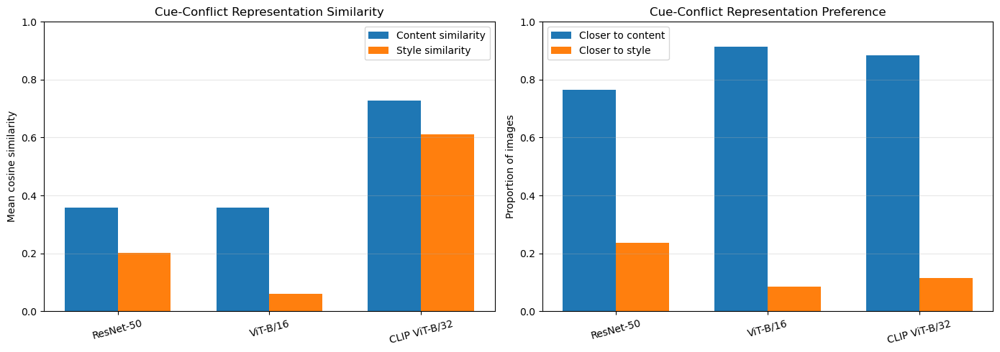

In [112]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

model_positions = np.arange(
    len(cue_representation_summary)
)

bar_width = 0.35

axes[0].bar(
    model_positions - bar_width / 2,
    cue_representation_summary[
        "mean_content_similarity"
    ],
    width=bar_width,
    label="Content similarity"
)

axes[0].bar(
    model_positions + bar_width / 2,
    cue_representation_summary[
        "mean_style_similarity"
    ],
    width=bar_width,
    label="Style similarity"
)

axes[0].set_title(
    "Cue-Conflict Representation Similarity"
)

axes[0].set_ylabel(
    "Mean cosine similarity"
)

axes[0].set_xticks(
    model_positions,
    cue_representation_summary["model"],
    rotation=15
)

axes[0].set_ylim(
    0,
    1
)

axes[0].grid(
    axis="y",
    alpha=0.3
)

axes[0].legend()

axes[1].bar(
    model_positions - bar_width / 2,
    cue_representation_summary[
        "content_closer_rate"
    ],
    width=bar_width,
    label="Closer to content"
)

axes[1].bar(
    model_positions + bar_width / 2,
    cue_representation_summary[
        "style_closer_rate"
    ],
    width=bar_width,
    label="Closer to style"
)

axes[1].set_title(
    "Cue-Conflict Representation Preference"
)

axes[1].set_ylabel(
    "Proportion of images"
)

axes[1].set_xticks(
    model_positions,
    cue_representation_summary["model"],
    rotation=15
)

axes[1].set_ylim(
    0,
    1
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

axes[1].legend()

plt.tight_layout()

plt.savefig(
    "results/cue_conflicts/cue_representation_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
classifier_to_backbone = {
    "ResNet-50 linear head": "ResNet-50",
    "ViT-B/16 linear head": "ViT-B/16",
    "CLIP ViT-B/32 linear head": "CLIP ViT-B/32",
    "CLIP ViT-B/32 zero-shot": "CLIP ViT-B/32"
}

final_summary_records = []

for classifier_name in model_display_names.values():
    backbone_name = classifier_to_backbone[
        classifier_name
    ]

    clean_row = clean_results[
        clean_results["model"] == classifier_name
    ].iloc[0]

    grayscale_row = grayscale_results[
        grayscale_results["model"] == classifier_name
    ].iloc[0]

    hue_row = hue_results[
        hue_results["model"] == classifier_name
    ].iloc[0]

    cue_row = cue_bias_results[
        cue_bias_results["model"] == classifier_name
    ].iloc[0]

    translation_row = translation_results[
        (
            translation_results["model"]
            == classifier_name
        )
        & (
            translation_results["displacement"]
            == max(TRANSLATION_DISPLACEMENTS)
        )
    ].iloc[0]

    patch_row = patch_shuffle_results[
        (
            patch_shuffle_results["model"]
            == classifier_name
        )
        & (
            patch_shuffle_results["grid_size"]
            == max(PATCH_GRID_SIZES)
        )
    ].iloc[0]

    grayscale_feature_row = (
        color_feature_similarity_results[
            (
                color_feature_similarity_results[
                    "model"
                ] == backbone_name
            )
            & (
                color_feature_similarity_results[
                    "intervention"
                ] == "grayscale"
            )
        ]
        .iloc[0]
    )

    hue_feature_row = (
        color_feature_similarity_results[
            (
                color_feature_similarity_results[
                    "model"
                ] == backbone_name
            )
            & (
                color_feature_similarity_results[
                    "intervention"
                ] == "hue rotation"
            )
        ]
        .iloc[0]
    )

    translation_feature_row = (
        translation_feature_similarity[
            (
                translation_feature_similarity[
                    "model"
                ] == backbone_name
            )
            & (
                translation_feature_similarity[
                    "displacement"
                ] == max(
                    TRANSLATION_DISPLACEMENTS
                )
            )
        ]
        .iloc[0]
    )

    patch_feature_row = (
        patch_feature_similarity[
            (
                patch_feature_similarity[
                    "model"
                ] == backbone_name
            )
            & (
                patch_feature_similarity[
                    "grid_size"
                ] == max(
                    PATCH_GRID_SIZES
                )
            )
        ]
        .iloc[0]
    )

    cue_representation_row = (
        cue_representation_summary[
            cue_representation_summary[
                "model"
            ] == backbone_name
        ]
        .iloc[0]
    )

    final_summary_records.append({
        "classifier": classifier_name,
        "backbone": backbone_name,
        "clean_accuracy": clean_row[
            "accuracy"
        ],
        "clean_macro_f1": clean_row[
            "macro_f1"
        ],
        "grayscale_accuracy": grayscale_row[
            "accuracy"
        ],
        "grayscale_accuracy_change": grayscale_row[
            "accuracy_change"
        ],
        "grayscale_consistency": grayscale_row[
            "prediction_consistency"
        ],
        "grayscale_feature_similarity": (
            grayscale_feature_row[
                "mean_cosine_similarity"
            ]
        ),
        "hue_accuracy": hue_row[
            "accuracy"
        ],
        "hue_accuracy_change": hue_row[
            "accuracy_change"
        ],
        "hue_consistency": hue_row[
            "prediction_consistency"
        ],
        "hue_feature_similarity": (
            hue_feature_row[
                "mean_cosine_similarity"
            ]
        ),
        "translation_32px_accuracy": (
            translation_row["accuracy"]
        ),
        "translation_32px_consistency": (
            translation_row[
                "prediction_consistency"
            ]
        ),
        "translation_32px_feature_similarity": (
            translation_feature_row[
                "mean_cosine_similarity"
            ]
        ),
        "patch_16x16_accuracy": (
            patch_row["accuracy"]
        ),
        "patch_16x16_consistency": (
            patch_row[
                "prediction_consistency"
            ]
        ),
        "patch_16x16_feature_similarity": (
            patch_feature_row[
                "mean_cosine_similarity"
            ]
        ),
        "cue_shape_bias": cue_row[
            "shape_bias"
        ],
        "cue_texture_bias": cue_row[
            "texture_bias"
        ],
        "cue_coverage": cue_row[
            "coverage"
        ],
        "cue_content_similarity": (
            cue_representation_row[
                "mean_content_similarity"
            ]
        ),
        "cue_style_similarity": (
            cue_representation_row[
                "mean_style_similarity"
            ]
        ),
        "cue_content_closer_rate": (
            cue_representation_row[
                "content_closer_rate"
            ]
        )
    })

final_task1_summary = pd.DataFrame(
    final_summary_records
)

final_task1_summary.to_csv(
    "results/final_task1_summary.csv",
    index=False
)

final_task1_summary

,classifier,backbone,clean_accuracy,clean_macro_f1,grayscale_accuracy,grayscale_accuracy_change,grayscale_consistency,grayscale_feature_similarity,hue_accuracy,hue_accuracy_change,...,translation_32px_feature_similarity,patch_16x16_accuracy,patch_16x16_consistency,patch_16x16_feature_similarity,cue_shape_bias,cue_texture_bias,cue_coverage,cue_content_similarity,cue_style_similarity,cue_content_closer_rate
0,ResNet-50 linear head,ResNet-50,0.976,0.976056,0.960,-0.016,0.966,0.789124,0.934,-0.042,...,0.932725,0.414,0.416,0.283533,0.808696,0.191304,0.575,0.358045,0.202449,0.765
1,ViT-B/16 linear head,ViT-B/16,0.972,0.971915,0.956,-0.016,0.954,0.739242,0.942,-0.030,...,0.941761,0.278,0.278,0.097238,0.907895,0.092105,0.760,0.358833,0.060725,0.915
2,CLIP ViT-B/32 linear head,CLIP ViT-B/32,0.984,0.983997,0.952,-0.032,0.962,0.895122,0.932,-0.052,...,0.969093,0.262,0.266,0.543894,0.979730,0.020270,0.740,0.726525,0.610560,0.885
3,CLIP ViT-B/32 zero-shot,CLIP ViT-B/32,0.968,0.967524,0.944,-0.024,0.954,0.895122,0.926,-0.042,...,0.969093,0.284,0.282,0.543894,0.966667,0.033333,0.750,0.726525,0.610560,0.885


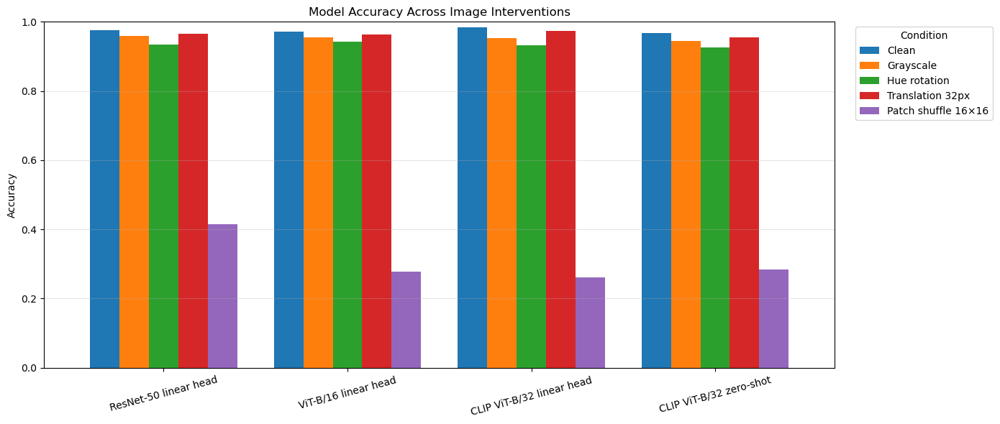

In [114]:
accuracy_comparison = (
    final_task1_summary[
        [
            "classifier",
            "clean_accuracy",
            "grayscale_accuracy",
            "hue_accuracy",
            "translation_32px_accuracy",
            "patch_16x16_accuracy"
        ]
    ]
    .rename(
        columns={
            "clean_accuracy": "Clean",
            "grayscale_accuracy": "Grayscale",
            "hue_accuracy": "Hue rotation",
            "translation_32px_accuracy": "Translation 32px",
            "patch_16x16_accuracy": "Patch shuffle 16×16"
        }
    )
    .set_index("classifier")
)

axis = accuracy_comparison.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

axis.set_title(
    "Model Accuracy Across Image Interventions"
)

axis.set_xlabel(
    ""
)

axis.set_ylabel(
    "Accuracy"
)

axis.set_ylim(
    0,
    1
)

axis.tick_params(
    axis="x",
    rotation=15
)

axis.grid(
    axis="y",
    alpha=0.3
)

axis.legend(
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "results/final_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

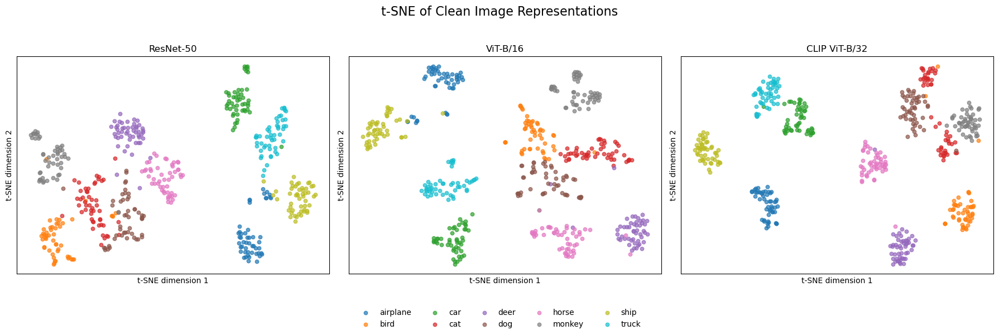

In [115]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def compute_tsne_coordinates(
    features,
    seed=6304
):
    normalized_features = F.normalize(
        features.float(),
        dim=1
    ).numpy()

    pca_features = PCA(
        n_components=50,
        random_state=seed
    ).fit_transform(
        normalized_features
    )

    coordinates = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=seed
    ).fit_transform(
        pca_features
    )

    return coordinates


clean_feature_sets = {
    "ResNet-50": resnet_clean_features,
    "ViT-B/16": vit_clean_features,
    "CLIP ViT-B/32": clip_clean_features
}

clean_tsne_coordinates = {
    model_name: compute_tsne_coordinates(
        features
    )
    for model_name, features in (
        clean_feature_sets.items()
    )
}

clean_tsne_records = []

for model_name, coordinates in (
    clean_tsne_coordinates.items()
):
    for image_position in range(
        len(coordinates)
    ):
        class_index = int(
            resnet_clean_labels[
                image_position
            ]
        )

        clean_tsne_records.append({
            "model": model_name,
            "dataset_index": int(
                resnet_clean_ids[
                    image_position
                ]
            ),
            "class_index": class_index,
            "class_name": class_names[
                class_index
            ],
            "tsne_1": coordinates[
                image_position,
                0
            ],
            "tsne_2": coordinates[
                image_position,
                1
            ]
        })

clean_tsne_results = pd.DataFrame(
    clean_tsne_records
)

clean_tsne_results.to_csv(
    "results/clean_tsne_coordinates.csv",
    index=False
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(class_names)
    )
)

for axis, (
    model_name,
    coordinates
) in zip(
    axes,
    clean_tsne_coordinates.items()
):
    for class_index, class_name in enumerate(
        class_names
    ):
        class_mask = (
            resnet_clean_labels.numpy()
            == class_index
        )

        axis.scatter(
            coordinates[
                class_mask,
                0
            ],
            coordinates[
                class_mask,
                1
            ],
            s=22,
            alpha=0.7,
            color=colors[
                class_index
            ],
            label=class_name
        )

    axis.set_title(
        model_name
    )

    axis.set_xlabel(
        "t-SNE dimension 1"
    )

    axis.set_ylabel(
        "t-SNE dimension 2"
    )

    axis.set_xticks([])
    axis.set_yticks([])

handles, labels = (
    axes[0].get_legend_handles_labels()
)

figure.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False
)

figure.suptitle(
    "t-SNE of Clean Image Representations",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0.12, 1, 0.95]
)

plt.savefig(
    "results/clean_representation_tsne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

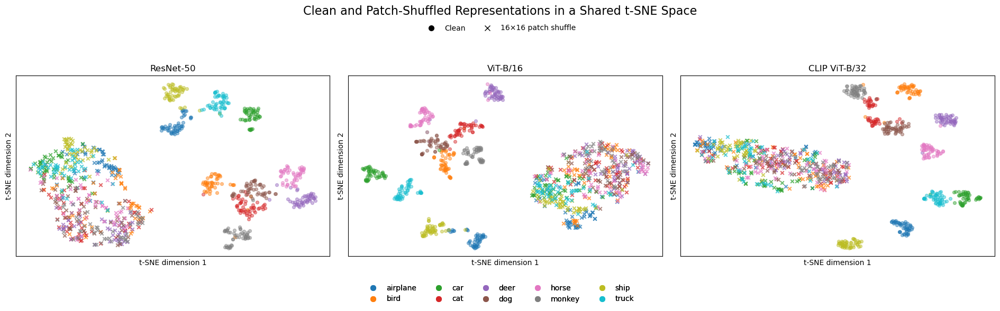

In [116]:
from matplotlib.lines import Line2D

def compute_joint_tsne_coordinates(
    clean_features,
    transformed_features,
    seed=6304
):
    combined_features = torch.cat(
        [
            clean_features,
            transformed_features
        ],
        dim=0
    )

    coordinates = compute_tsne_coordinates(
        combined_features,
        seed=seed
    )

    number_of_images = len(
        clean_features
    )

    clean_coordinates = coordinates[
        :number_of_images
    ]

    transformed_coordinates = coordinates[
        number_of_images:
    ]

    return (
        clean_coordinates,
        transformed_coordinates
    )


strong_patch_features = (
    patch_features
)

patch_tsne_coordinates = {}

for model_key in backbone_display_names:
    (
        clean_coordinates,
        shuffled_coordinates
    ) = compute_joint_tsne_coordinates(
        clean_backbone_features[
            model_key
        ],
        strong_patch_features[
            model_key
        ]
    )

    patch_tsne_coordinates[
        model_key
    ] = {
        "clean": clean_coordinates,
        "patch_shuffle": (
            shuffled_coordinates
        )
    }


patch_tsne_records = []

for model_key, condition_coordinates in (
    patch_tsne_coordinates.items()
):
    for condition, coordinates in (
        condition_coordinates.items()
    ):
        for image_position in range(
            len(coordinates)
        ):
            class_index = int(
                resnet_clean_labels[
                    image_position
                ]
            )

            patch_tsne_records.append({
                "model": backbone_display_names[
                    model_key
                ],
                "condition": condition,
                "dataset_index": int(
                    resnet_clean_ids[
                        image_position
                    ]
                ),
                "class_index": class_index,
                "class_name": class_names[
                    class_index
                ],
                "tsne_1": coordinates[
                    image_position,
                    0
                ],
                "tsne_2": coordinates[
                    image_position,
                    1
                ]
            })

patch_tsne_results = pd.DataFrame(
    patch_tsne_records
)

patch_tsne_results.to_csv(
    "results/patch_shuffle_tsne_coordinates.csv",
    index=False
)


figure, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6)
)

colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(class_names)
    )
)

for axis, model_key in zip(
    axes,
    backbone_display_names
):
    clean_coordinates = (
        patch_tsne_coordinates[
            model_key
        ]["clean"]
    )

    shuffled_coordinates = (
        patch_tsne_coordinates[
            model_key
        ]["patch_shuffle"]
    )

    for class_index, class_name in enumerate(
        class_names
    ):
        class_mask = (
            resnet_clean_labels.numpy()
            == class_index
        )

        axis.scatter(
            clean_coordinates[
                class_mask,
                0
            ],
            clean_coordinates[
                class_mask,
                1
            ],
            color=colors[
                class_index
            ],
            marker="o",
            s=18,
            alpha=0.45
        )

        axis.scatter(
            shuffled_coordinates[
                class_mask,
                0
            ],
            shuffled_coordinates[
                class_mask,
                1
            ],
            color=colors[
                class_index
            ],
            marker="x",
            s=22,
            alpha=0.7
        )

    axis.set_title(
        backbone_display_names[
            model_key
        ]
    )

    axis.set_xlabel(
        "t-SNE dimension 1"
    )

    axis.set_ylabel(
        "t-SNE dimension 2"
    )

    axis.set_xticks([])
    axis.set_yticks([])


class_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=colors[
            class_index
        ],
        label=class_name,
        markersize=7
    )
    for class_index, class_name in enumerate(
        class_names
    )
]

condition_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color="black",
        label="Clean",
        markersize=7
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        linestyle="",
        color="black",
        label="16×16 patch shuffle",
        markersize=7
    )
]

class_legend = figure.legend(
    handles=class_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02)
)

figure.add_artist(
    class_legend
)

figure.legend(
    handles=condition_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94)
)

figure.suptitle(
    "Clean and Patch-Shuffled Representations in a Shared t-SNE Space",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0.13, 1, 0.88]
)

plt.savefig(
    "results/patch_shuffle_representation_tsne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

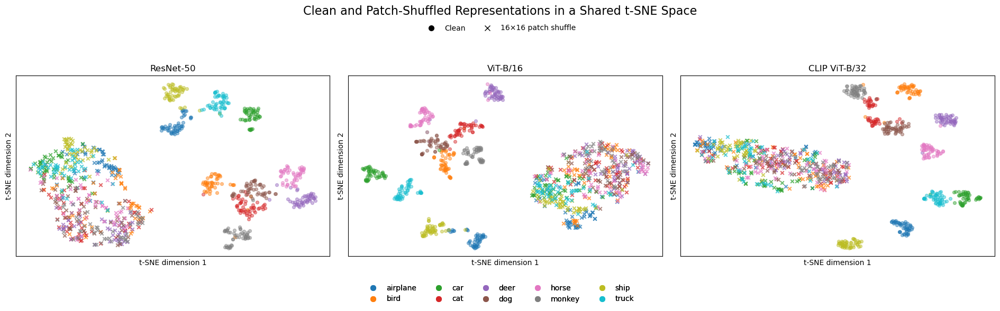

In [117]:
from matplotlib.lines import Line2D

def compute_joint_tsne_coordinates(
    clean_features,
    transformed_features,
    seed=6304
):
    combined_features = torch.cat(
        [
            clean_features,
            transformed_features
        ],
        dim=0
    )

    coordinates = compute_tsne_coordinates(
        combined_features,
        seed=seed
    )

    number_of_images = len(
        clean_features
    )

    clean_coordinates = coordinates[
        :number_of_images
    ]

    transformed_coordinates = coordinates[
        number_of_images:
    ]

    return (
        clean_coordinates,
        transformed_coordinates
    )


strong_patch_features = (
    patch_features
)

patch_tsne_coordinates = {}

for model_key in backbone_display_names:
    (
        clean_coordinates,
        shuffled_coordinates
    ) = compute_joint_tsne_coordinates(
        clean_backbone_features[
            model_key
        ],
        strong_patch_features[
            model_key
        ]
    )

    patch_tsne_coordinates[
        model_key
    ] = {
        "clean": clean_coordinates,
        "patch_shuffle": (
            shuffled_coordinates
        )
    }


patch_tsne_records = []

for model_key, condition_coordinates in (
    patch_tsne_coordinates.items()
):
    for condition, coordinates in (
        condition_coordinates.items()
    ):
        for image_position in range(
            len(coordinates)
        ):
            class_index = int(
                resnet_clean_labels[
                    image_position
                ]
            )

            patch_tsne_records.append({
                "model": backbone_display_names[
                    model_key
                ],
                "condition": condition,
                "dataset_index": int(
                    resnet_clean_ids[
                        image_position
                    ]
                ),
                "class_index": class_index,
                "class_name": class_names[
                    class_index
                ],
                "tsne_1": coordinates[
                    image_position,
                    0
                ],
                "tsne_2": coordinates[
                    image_position,
                    1
                ]
            })

patch_tsne_results = pd.DataFrame(
    patch_tsne_records
)

patch_tsne_results.to_csv(
    "results/patch_shuffle_tsne_coordinates.csv",
    index=False
)


figure, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6)
)

colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(class_names)
    )
)

for axis, model_key in zip(
    axes,
    backbone_display_names
):
    clean_coordinates = (
        patch_tsne_coordinates[
            model_key
        ]["clean"]
    )

    shuffled_coordinates = (
        patch_tsne_coordinates[
            model_key
        ]["patch_shuffle"]
    )

    for class_index, class_name in enumerate(
        class_names
    ):
        class_mask = (
            resnet_clean_labels.numpy()
            == class_index
        )

        axis.scatter(
            clean_coordinates[
                class_mask,
                0
            ],
            clean_coordinates[
                class_mask,
                1
            ],
            color=colors[
                class_index
            ],
            marker="o",
            s=18,
            alpha=0.45
        )

        axis.scatter(
            shuffled_coordinates[
                class_mask,
                0
            ],
            shuffled_coordinates[
                class_mask,
                1
            ],
            color=colors[
                class_index
            ],
            marker="x",
            s=22,
            alpha=0.7
        )

    axis.set_title(
        backbone_display_names[
            model_key
        ]
    )

    axis.set_xlabel(
        "t-SNE dimension 1"
    )

    axis.set_ylabel(
        "t-SNE dimension 2"
    )

    axis.set_xticks([])
    axis.set_yticks([])


class_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=colors[
            class_index
        ],
        label=class_name,
        markersize=7
    )
    for class_index, class_name in enumerate(
        class_names
    )
]

condition_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color="black",
        label="Clean",
        markersize=7
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        linestyle="",
        color="black",
        label="16×16 patch shuffle",
        markersize=7
    )
]

class_legend = figure.legend(
    handles=class_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02)
)

figure.add_artist(
    class_legend
)

figure.legend(
    handles=condition_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94)
)

figure.suptitle(
    "Clean and Patch-Shuffled Representations in a Shared t-SNE Space",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0.13, 1, 0.88]
)

plt.savefig(
    "results/patch_shuffle_representation_tsne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

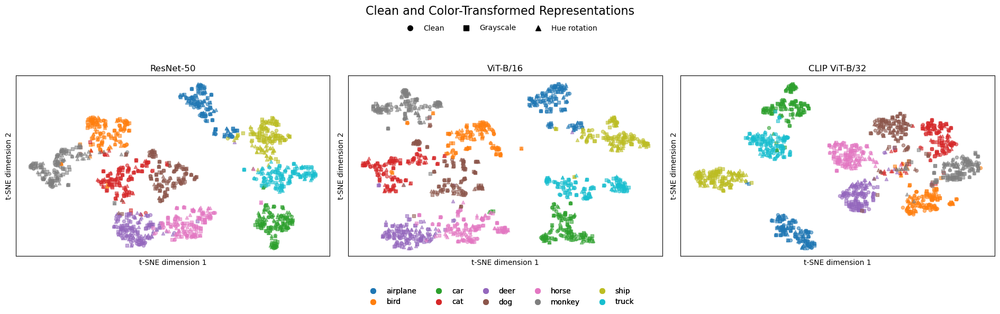

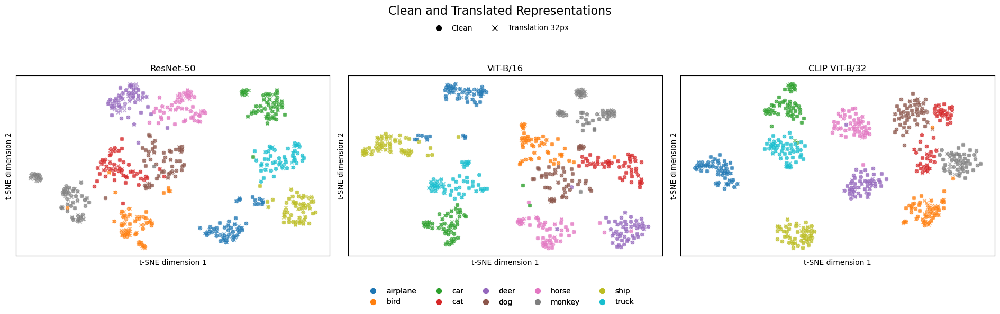

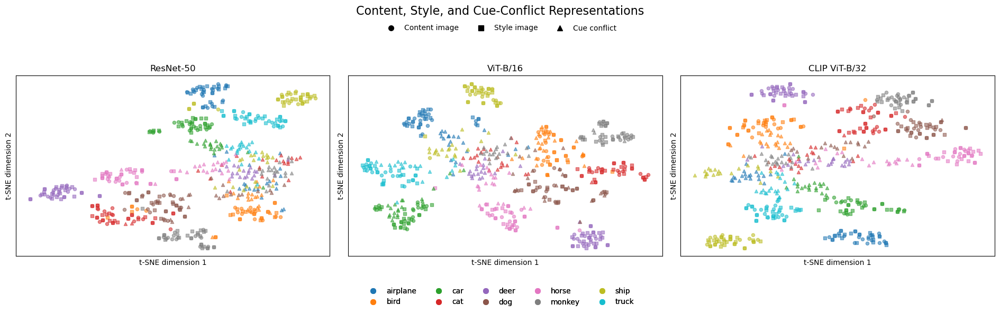

In [118]:
def create_shared_tsne_comparison(
    feature_sets,
    condition_labels,
    condition_ids,
    condition_markers,
    figure_title,
    output_name
):
    condition_names = list(
        condition_markers.keys()
    )

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(19, 6)
    )

    colors = plt.cm.tab10(
        np.linspace(
            0,
            1,
            len(class_names)
        )
    )

    coordinate_records = []

    for axis, model_key in zip(
        axes,
        backbone_display_names
    ):
        combined_features = torch.cat(
            [
                feature_sets[
                    model_key
                ][condition]
                for condition in condition_names
            ],
            dim=0
        )

        combined_coordinates = (
            compute_tsne_coordinates(
                combined_features
            )
        )

        coordinate_start = 0

        for condition in condition_names:
            condition_features = (
                feature_sets[
                    model_key
                ][condition]
            )

            number_of_points = len(
                condition_features
            )

            condition_coordinates = (
                combined_coordinates[
                    coordinate_start:
                    coordinate_start
                    + number_of_points
                ]
            )

            labels = condition_labels[
                condition
            ].numpy()

            image_ids = condition_ids[
                condition
            ].numpy()

            for class_index, class_name in enumerate(
                class_names
            ):
                class_mask = (
                    labels == class_index
                )

                axis.scatter(
                    condition_coordinates[
                        class_mask,
                        0
                    ],
                    condition_coordinates[
                        class_mask,
                        1
                    ],
                    color=colors[
                        class_index
                    ],
                    marker=condition_markers[
                        condition
                    ],
                    s=20,
                    alpha=0.55
                )

            for point_index in range(
                number_of_points
            ):
                class_index = int(
                    labels[
                        point_index
                    ]
                )

                coordinate_records.append({
                    "model": (
                        backbone_display_names[
                            model_key
                        ]
                    ),
                    "condition": condition,
                    "image_id": int(
                        image_ids[
                            point_index
                        ]
                    ),
                    "class_index": (
                        class_index
                    ),
                    "class_name": (
                        class_names[
                            class_index
                        ]
                    ),
                    "tsne_1": (
                        condition_coordinates[
                            point_index,
                            0
                        ]
                    ),
                    "tsne_2": (
                        condition_coordinates[
                            point_index,
                            1
                        ]
                    )
                })

            coordinate_start += (
                number_of_points
            )

        axis.set_title(
            backbone_display_names[
                model_key
            ]
        )

        axis.set_xlabel(
            "t-SNE dimension 1"
        )

        axis.set_ylabel(
            "t-SNE dimension 2"
        )

        axis.set_xticks([])
        axis.set_yticks([])

    class_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=colors[
                class_index
            ],
            label=class_name,
            markersize=7
        )
        for class_index, class_name in enumerate(
            class_names
        )
    ]

    condition_handles = [
        Line2D(
            [0],
            [0],
            marker=condition_markers[
                condition
            ],
            linestyle="",
            color="black",
            label=condition,
            markersize=7
        )
        for condition in condition_names
    ]

    class_legend = figure.legend(
        handles=class_handles,
        loc="lower center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )

    figure.add_artist(
        class_legend
    )

    figure.legend(
        handles=condition_handles,
        loc="upper center",
        ncol=len(condition_names),
        frameon=False,
        bbox_to_anchor=(0.5, 0.94)
    )

    figure.suptitle(
        figure_title,
        fontsize=16
    )

    plt.tight_layout(
        rect=[0, 0.13, 1, 0.88]
    )

    figure_path = (
        Path("results")
        / f"{output_name}.png"
    )

    coordinate_path = (
        Path("results")
        / f"{output_name}_coordinates.csv"
    )

    coordinate_results = pd.DataFrame(
        coordinate_records
    )

    coordinate_results.to_csv(
        coordinate_path,
        index=False
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return coordinate_results


color_tsne_features = {
    "resnet": {
        "Clean": resnet_clean_features,
        "Grayscale": (
            resnet_grayscale_features
        ),
        "Hue rotation": (
            resnet_hue_features
        )
    },
    "vit": {
        "Clean": vit_clean_features,
        "Grayscale": (
            vit_grayscale_features
        ),
        "Hue rotation": (
            vit_hue_features
        )
    },
    "clip": {
        "Clean": clip_clean_features,
        "Grayscale": (
            clip_grayscale_features
        ),
        "Hue rotation": (
            clip_hue_features
        )
    }
}

color_tsne_labels = {
    "Clean": resnet_clean_labels,
    "Grayscale": (
        resnet_grayscale_labels
    ),
    "Hue rotation": (
        resnet_hue_labels
    )
}

color_tsne_ids = {
    "Clean": resnet_clean_ids,
    "Grayscale": (
        resnet_grayscale_ids
    ),
    "Hue rotation": (
        resnet_hue_ids
    )
}

color_tsne_results = (
    create_shared_tsne_comparison(
        feature_sets=color_tsne_features,
        condition_labels=color_tsne_labels,
        condition_ids=color_tsne_ids,
        condition_markers={
            "Clean": "o",
            "Grayscale": "s",
            "Hue rotation": "^"
        },
        figure_title=(
            "Clean and Color-Transformed "
            "Representations"
        ),
        output_name=(
            "color_intervention_tsne"
        )
    )
)


(
    translation_32_features,
    translation_32_labels,
    translation_32_ids
) = collect_translation_features(
    common_test_loader,
    displacement=32,
    direction="right"
)

translation_tsne_features = {
    model_key: {
        "Clean": (
            clean_backbone_features[
                model_key
            ]
        ),
        "Translation 32px": (
            translation_32_features[
                model_key
            ]
        )
    }
    for model_key in backbone_display_names
}

translation_tsne_labels = {
    "Clean": resnet_clean_labels,
    "Translation 32px": (
        translation_32_labels
    )
}

translation_tsne_ids = {
    "Clean": resnet_clean_ids,
    "Translation 32px": (
        translation_32_ids
    )
}

translation_tsne_results = (
    create_shared_tsne_comparison(
        feature_sets=(
            translation_tsne_features
        ),
        condition_labels=(
            translation_tsne_labels
        ),
        condition_ids=(
            translation_tsne_ids
        ),
        condition_markers={
            "Clean": "o",
            "Translation 32px": "x"
        },
        figure_title=(
            "Clean and Translated "
            "Representations"
        ),
        output_name=(
            "translation_intervention_tsne"
        )
    )
)


cue_tsne_features = {
    model_key: {
        "Content image": (
            cue_content_features[
                model_key
            ]
        ),
        "Style image": (
            cue_style_features[
                model_key
            ]
        ),
        "Cue conflict": (
            cue_stylized_features[
                model_key
            ]
        )
    }
    for model_key in backbone_display_names
}

cue_tsne_labels = {
    "Content image": cue_content_labels,
    "Style image": cue_style_labels,
    "Cue conflict": cue_content_labels
}

cue_tsne_ids = {
    "Content image": cue_reference_ids,
    "Style image": cue_reference_ids,
    "Cue conflict": cue_image_ids
}

cue_tsne_results = (
    create_shared_tsne_comparison(
        feature_sets=cue_tsne_features,
        condition_labels=cue_tsne_labels,
        condition_ids=cue_tsne_ids,
        condition_markers={
            "Content image": "o",
            "Style image": "s",
            "Cue conflict": "^"
        },
        figure_title=(
            "Content, Style, and Cue-Conflict "
            "Representations"
        ),
        output_name=(
            "cue_conflict_tsne"
        )
    )
)

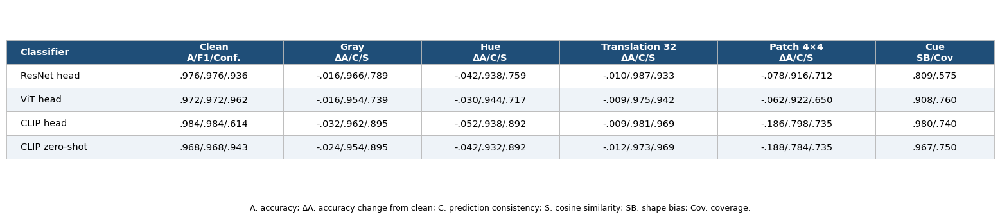

Saved PNG: C:\Users\HP\Desktop\ATML\PA1\results\task1_compact_combined_table.png
Saved PDF: C:\Users\HP\Desktop\ATML\PA1\results\task1_compact_combined_table.pdf


In [2]:
from pathlib import Path
from decimal import Decimal, ROUND_HALF_UP

import pandas as pd
import matplotlib.pyplot as plt

possible_results_directories = [
    Path.cwd() / "results",
    Path.cwd() / "task1" / "results",
    Path.cwd() / "task 1" / "results"
]

results_directory = next(
    (
        directory
        for directory in possible_results_directories
        if (directory / "clean_baseline_metrics.csv").exists()
    ),
    None
)

if results_directory is None:
    matches = list(
        Path.cwd().rglob("clean_baseline_metrics.csv")
    )

    if not matches:
        raise FileNotFoundError(
            "The results folder could not be found."
        )

    results_directory = matches[0].parent

clean_results = pd.read_csv(
    results_directory / "clean_baseline_metrics.csv"
)

color_results = pd.read_csv(
    results_directory / "color_intervention_metrics.csv"
)

translation_results = pd.read_csv(
    results_directory / "translation_results.csv"
)

patch_results = pd.read_csv(
    results_directory / "patch_shuffle_results.csv"
)

cue_results = pd.read_csv(
    results_directory
    / "cue_conflicts"
    / "cue_conflict_bias_results.csv"
)

color_similarity = pd.read_csv(
    results_directory / "color_feature_similarity.csv"
)

translation_similarity = pd.read_csv(
    results_directory / "translation_feature_similarity.csv"
)

patch_similarity = pd.read_csv(
    results_directory / "patch_shuffle_feature_similarity.csv"
)

classifier_information = [
    (
        "ResNet-50 linear head",
        "ResNet head",
        "ResNet-50"
    ),
    (
        "ViT-B/16 linear head",
        "ViT head",
        "ViT-B/16"
    ),
    (
        "CLIP ViT-B/32 linear head",
        "CLIP head",
        "CLIP ViT-B/32"
    ),
    (
        "CLIP ViT-B/32 zero-shot",
        "CLIP zero-shot",
        "CLIP ViT-B/32"
    )
]

def select_row(dataframe, **filters):
    selected = dataframe.copy()

    for column, value in filters.items():
        selected = selected[
            selected[column] == value
        ]

    if len(selected) != 1:
        raise ValueError(
            f"Expected one row for {filters}, "
            f"but found {len(selected)}."
        )

    return selected.iloc[0]

def compact_number(value):
    rounded = Decimal(str(value)).quantize(
        Decimal("0.001"),
        rounding=ROUND_HALF_UP
    )

    text = f"{rounded:.3f}"

    if text.startswith("-0"):
        text = "-" + text[2:]
    elif text.startswith("0"):
        text = text[1:]

    return text

table_rows = []

for full_name, short_name, backbone_name in classifier_information:
    clean = select_row(
        clean_results,
        model=full_name
    )

    grayscale = select_row(
        color_results,
        intervention="grayscale",
        model=full_name
    )

    hue = select_row(
        color_results,
        intervention="hue_rotation",
        model=full_name
    )

    translation = select_row(
        translation_results,
        model=full_name,
        displacement=32
    )

    patch = select_row(
        patch_results,
        model=full_name,
        grid_size=4
    )

    cue = select_row(
        cue_results,
        model=full_name
    )

    grayscale_similarity = select_row(
        color_similarity,
        model=backbone_name,
        intervention="grayscale"
    )

    hue_similarity = select_row(
        color_similarity,
        model=backbone_name,
        intervention="hue rotation"
    )

    translation_feature_similarity = select_row(
        translation_similarity,
        model=backbone_name,
        displacement=32
    )

    patch_feature_similarity = select_row(
        patch_similarity,
        model=backbone_name,
        grid_size=4
    )

    clean_accuracy = Decimal(
        str(clean["accuracy"])
    )

    grayscale_change = (
        Decimal(str(grayscale["accuracy"]))
        - clean_accuracy
    )

    hue_change = (
        Decimal(str(hue["accuracy"]))
        - clean_accuracy
    )

    translation_change = (
        Decimal(str(translation["accuracy"]))
        - clean_accuracy
    )

    patch_change = (
        Decimal(str(patch["accuracy"]))
        - clean_accuracy
    )

    table_rows.append([
        short_name,
        "/".join([
            compact_number(clean["accuracy"]),
            compact_number(clean["macro_f1"]),
            compact_number(
                clean["mean_max_confidence"]
            )
        ]),
        "/".join([
            compact_number(grayscale_change),
            compact_number(
                grayscale["prediction_consistency"]
            ),
            compact_number(
                grayscale_similarity[
                    "mean_cosine_similarity"
                ]
            )
        ]),
        "/".join([
            compact_number(hue_change),
            compact_number(
                hue["prediction_consistency"]
            ),
            compact_number(
                hue_similarity[
                    "mean_cosine_similarity"
                ]
            )
        ]),
        "/".join([
            compact_number(translation_change),
            compact_number(
                translation["prediction_consistency"]
            ),
            compact_number(
                translation_feature_similarity[
                    "mean_cosine_similarity"
                ]
            )
        ]),
        "/".join([
            compact_number(patch_change),
            compact_number(
                patch["prediction_consistency"]
            ),
            compact_number(
                patch_feature_similarity[
                    "mean_cosine_similarity"
                ]
            )
        ]),
        "/".join([
            compact_number(cue["shape_bias"]),
            compact_number(cue["coverage"])
        ])
    ])

column_names = [
    "Classifier",
    "Clean\nA/F1/Conf.",
    "Gray\nΔA/C/S",
    "Hue\nΔA/C/S",
    "Translation 32\nΔA/C/S",
    "Patch 4×4\nΔA/C/S",
    "Cue\nSB/Cov"
]

figure, axis = plt.subplots(
    figsize=(16, 3.5)
)

axis.axis("off")

table = axis.table(
    cellText=table_rows,
    colLabels=column_names,
    cellLoc="center",
    colLoc="center",
    colWidths=[
        0.14,
        0.14,
        0.14,
        0.14,
        0.16,
        0.16,
        0.12
    ],
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 2.05)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("#B8B8B8")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#1F4E78")
        cell.set_text_props(
            color="white",
            fontweight="bold"
        )
    elif row % 2 == 0:
        cell.set_facecolor("#EEF3F8")
    else:
        cell.set_facecolor("white")

    if column == 0:
        cell.set_text_props(
            ha="left",
            fontweight="bold" if row == 0 else "normal"
        )

figure.text(
    0.5,
    0.035,
    "A: accuracy; ΔA: accuracy change from clean; "
    "C: prediction consistency; S: cosine similarity; "
    "SB: shape bias; Cov: coverage.",
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0.01, 0.07, 0.99, 0.99]
)

png_path = (
    results_directory
    / "task1_compact_combined_table.png"
)

pdf_path = (
    results_directory
    / "task1_compact_combined_table.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved PNG:", png_path.resolve())
print("Saved PDF:", pdf_path.resolve())